In [1]:
from collections import Counter
import itertools

from scipy.stats import pearsonr

import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tqdm
from statsmodels.stats.contingency_tables import mcnemar
from scipy.stats import chi2_contingency, fisher_exact
from statsmodels.stats.rates import test_poisson_2indep


from natsort import natsorted
import dendropy
 

from netam import framework
from dnsmex import dxsm_data, dnsm_zoo
from dnsmex.dnsm_oe import write_sites_oe
from dnsmex.local import localify



figures_dir = localify("FIGURES_DIR")

## Prep data - Rodriguez dataset

In [3]:
%%bash
## get counts of V and J genes
zcat /fh/fast/matsen_e/shared/bcr-mut-sel/pcps/v1/rodriguez-airr-seq-race-prod-InclMutInv_pcp_2024-11-12_MASKED_NI_noN_no-naive_addJ.csv.gz | tail -n +2 | cut -d ',' -f 11 | cut -d '-' -f 1 | sort | uniq -c | sort -nr
echo "---"
zcat /fh/fast/matsen_e/shared/bcr-mut-sel/pcps/v1/rodriguez-airr-seq-race-prod-InclMutInv_pcp_2024-11-12_MASKED_NI_noN_no-naive_addJ.csv.gz | tail -n +2 | cut -d ',' -f 20 | cut -d '*' -f 1 | sort | uniq -c | sort -nr

   9985 IGHV3
   5246 IGHV4
   4328 IGHV1
    944 IGHV5
    771 IGHV2
    351 IGHV6
    129 IGHV7
---
  11562 IGHJ4
   3563 IGHJ6
   2863 IGHJ5
   2825 IGHJ3
    562 IGHJ2
    379 IGHJ1


In [48]:
dataset_name = "v1rodriguez"
model_name = "dnsm_1m-v1jaffe+v1tang-joint"

crepe_prefix = localify(f"DNSM_TRAINED_MODELS_DIR/{model_name}")
test_output_prefix = localify(f"DNSM_TEST_OUTPUT_DIR/{model_name}-ON-{dataset_name}")

try:
    site_sub_probs_df = pd.read_csv(f"{test_output_prefix}-site_sub_probs_df.csv")
    pcp_df = pd.read_csv(f"{test_output_prefix}-pcp_df.csv")


except FileNotFoundError:
    if not os.path.exists(f"{test_output_prefix}.branch_lengths_csv"):
        dnsm_zoo.write_branch_lengths("/fh/fast/matsen_e/shared/bcr-mut-sel/dnsm/dnsm-experiments-1/dnsm-train/trained_models/dnsm_1m-v1jaffe+v1tang-joint", dataset_name, f"{test_output_prefix}.branch_lengths_csv")


    complete_plotter, plotter_dict = write_sites_oe(
        crepe_prefix=crepe_prefix,
        dataset_name=dataset_name,
        branch_length_path=f"{test_output_prefix}.branch_lengths_csv",
        csv_output_path=f"{test_output_prefix}-sites-oe.csv",
        fig_out_path=f"{figures_dir}/sites-oe-V1,3,4.svg",
        min_log_prob=-4,
        #v_families=["IGHV1", "IGHV2", "IGHV3", "IGHV4", "IGHV5", "IGHV6", "IGHV7"],
        replace_title=True,
    )
    complete_plotter = complete_plotter["heavy"]


    pcp_df = complete_plotter.pcp_df.copy()
    site_sub_probs_df = complete_plotter.site_sub_probs_df.copy()
    for column_name in ['selection_factor', 'neutral_prob', 'prob']:
        site_sub_probs_df[column_name] = site_sub_probs_df[column_name].apply(lambda x: x.item() if hasattr(x, 'item') else x)


    pcp_df.to_csv(f"{test_output_prefix}-pcp_df.csv", index=False)
    site_sub_probs_df.to_csv(f"{test_output_prefix}-site_sub_probs_df.csv", index=False)



    def site_sub_probs_df_without_low_freq(in_plotter, quantile_cutoff=0.05):
        site_sub_probs_df = in_plotter.site_sub_probs_df.copy()
        site_counts = site_sub_probs_df["site"].value_counts()
        cutoff = site_counts.quantile(quantile_cutoff)
        sites_above_cutoff = set(site_counts[site_counts > cutoff].index)
        site_sub_probs_df = site_sub_probs_df[site_sub_probs_df["site"].isin(sites_above_cutoff)]
        return site_sub_probs_df

    def sort_df_by_site(df):
        sorted_index = natsorted(df.index, key=lambda x: df.loc[x, 'site'])
        return df.iloc[sorted_index]

    def build_persite_df(site_sub_probs_df):
        persite_df = site_sub_probs_df.groupby(['site', 'is_cdr']).agg(
            mean_prob=('prob', 'mean'),
            mean_neutral_prob=('neutral_prob', 'mean'),
            mean_selection_factor=('selection_factor', 'mean'),
            mut_freq=('mutation', 'mean')
        ).reset_index()

        persite_df = sort_df_by_site(persite_df)

        return persite_df



In [49]:
# add family annotations to aa and site substitution dfs
pcp_df['j_family'] = pcp_df['j_gene'].str.split('*').str[0]
pcp_df_for_merge = pcp_df.copy()
pcp_df_for_merge = pcp_df_for_merge[['v_gene', 'j_gene', 'v_family', 'j_family', 'sample_id', 'family', 'distance', 'branch_length', 'parent_name', 'child_name']]
pcp_df_for_merge['pcp_index'] = pcp_df_for_merge.index

site_sub_probs_df = pd.merge(site_sub_probs_df, pcp_df_for_merge, on='pcp_index', how='inner')

site_sub_probs_df['log_selection_factor'] = np.log(site_sub_probs_df['selection_factor'])


<Axes: xlabel='site', ylabel='Count'>

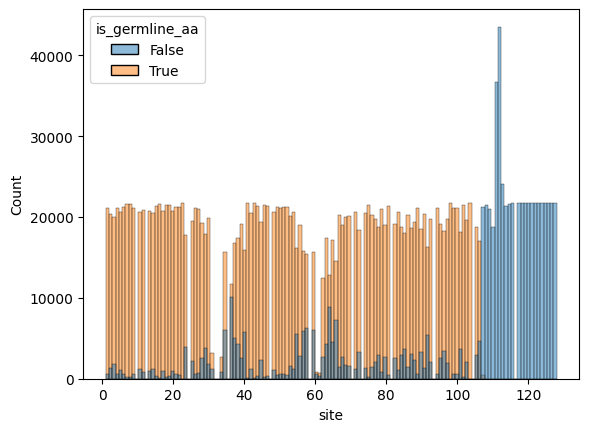

In [50]:
## add germline information
germline_codons_df = pd.read_csv(localify(f"DATA_DIR/germline_codons.csv"))
codon_similarity = pd.read_csv(localify(f"DATA_DIR/germline_codon_similarity.csv"))
aa_similarity = pd.read_csv(localify(f"DATA_DIR/germline_aa_similarity.csv"))
aa_similarity.set_index('v_gene', inplace=True)
codon_similarity.set_index('v_gene', inplace=True)





germline_codons_df['site'] = germline_codons_df['site'].astype(float)

site_sub_probs_df_germline = pd.merge(site_sub_probs_df, germline_codons_df.rename(columns={'codon':'germline_codon', 'amino_acid':'germline_amino_acid'}).drop(columns=['v_family']), on=['v_gene', 'site'], how='left')

site_sub_probs_df_germline['is_germline_aa'] = site_sub_probs_df_germline.parent_aa == site_sub_probs_df_germline.germline_amino_acid
site_sub_probs_df_germline['is_germline_codon'] = site_sub_probs_df_germline.parent_codon == site_sub_probs_df_germline.germline_codon
sns.histplot(site_sub_probs_df_germline, x='site', hue='is_germline_aa')

In [51]:
site_sub_probs_df_germline

,neutral_prob,selection_factor,prob,mutation,pcp_index,site,is_cdr,parent_codon,parent_aa,child_codon,...,family,distance,branch_length,parent_name,child_name,log_selection_factor,germline_codon,germline_amino_acid,is_germline_aa,is_germline_codon
0,0.102066,0.132334,0.013507,False,0,1.0,False,CAG,Q,CAG,...,1401,0.096444,0.082506,Node1,1TGCGTTGTAGCT,-2.022430,CAG,Q,True,True
1,0.030019,0.132334,0.003972,False,1,1.0,False,CAG,Q,CAG,...,1401,0.031971,0.018034,Node1,Node2,-2.022430,CAG,Q,True,True
2,0.011072,0.229902,0.002546,False,2,1.0,False,CAG,Q,CAG,...,474,0.079722,0.002823,Node1,Node2,-1.470103,CAG,Q,True,True
3,0.054606,0.262477,0.014333,False,3,1.0,False,CAG,Q,CAG,...,238,0.094379,0.029887,Node1,1GGGCACTATGCA,-1.337593,CAG,Q,True,True
4,0.010781,0.262477,0.002830,False,4,1.0,False,CAG,Q,CAG,...,238,0.069703,0.005211,Node1,1GCAGGGCACTCT,-1.337593,CAG,Q,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2646366,0.001440,1.122413,0.001617,False,21747,128.0,False,TCA,S,TCA,...,62,0.039758,0.002731,Node1,1TCGGCAATGTAT,0.115481,NaN,NaN,False,False
2646367,0.001785,1.077277,0.001923,False,21748,128.0,False,TCA,S,TCA,...,10,0.109737,0.002848,Node1,Node2,0.074437,NaN,NaN,False,False
2646368,0.001744,1.077277,0.001879,False,21749,128.0,False,TCA,S,TCA,...,10,0.112585,0.002848,Node2,1TTTGTTCCTATG,0.074437,NaN,NaN,False,False
2646369,0.001797,1.249783,0.002246,False,21750,128.0,False,TCA,S,TCA,...,10,0.119753,0.002803,Node1,1AAAGGGCCAGTT,0.222970,NaN,NaN,False,False


In [52]:
def is_parent_child_one_mutation_away(parent_codon, child_codon):
    """
    Check if two codons are one mutation away from each other.
    """
    if parent_codon == child_codon:
        return False
    # Check if they differ by exactly one nucleotide mutation
    mutations = sum(1 for p, c in zip(parent_codon, child_codon) if p != c)
    return mutations == 1

site_sub_probs_df_germline['is_one_mutation_away'] = site_sub_probs_df_germline.apply(
    lambda row: is_parent_child_one_mutation_away(row['parent_codon'], row['child_codon']),
    axis=1
)

In [53]:
site_sub_probs_df_germline.groupby(['mutation', 'is_one_mutation_away']).size().reset_index()


,mutation,is_one_mutation_away,0
0,False,False,2450908
1,False,True,72290
2,True,False,22033
3,True,True,101140


## association analysis

In [23]:
def calculate_association_between_sites(site_sub_probs_df, site1, site2):
    """
    Calculate the association between two sites based on their mutation probabilities.

    Simplest function - doesn't matter what the parent or child is, only aggregating over an occurence of a mutaiton at each site.
    """
    cfs_with_site1_mutation = site_sub_probs_df[(site_sub_probs_df['site'] == site1) & (site_sub_probs_df_germline.mutation == True)][['family', 'sample_id']].drop_duplicates()
    cfs_with_site2_mutation = site_sub_probs_df[(site_sub_probs_df['site'] == site2) & (site_sub_probs_df_germline.mutation == True)][['family', 'sample_id']].drop_duplicates()
    
    cfs_count = len(site_sub_probs_df_germline[['family', 'sample_id']].drop_duplicates())

    cfs_with_both_mutations = len(pd.merge(cfs_with_site1_mutation, cfs_with_site2_mutation, on=['family', 'sample_id'], how='inner'))
    cfs_with_site1_mutation_only = len(cfs_with_site1_mutation) - cfs_with_both_mutations
    cfs_with_site2_mutation_only = len(cfs_with_site2_mutation) - cfs_with_both_mutations
    cfs_with_neither_mutation = cfs_count - (cfs_with_both_mutations + cfs_with_site1_mutation_only + cfs_with_site2_mutation_only)
    
    contingency_table = np.array([
        [cfs_with_both_mutations, cfs_with_site1_mutation_only],
        [cfs_with_site2_mutation_only, cfs_with_neither_mutation]
    ])  
    # calculate chi-squared statistic with package
    chi2, p_value, dof, expected_freq = chi2_contingency(contingency_table)

    return contingency_table, chi2, p_value

    


In [24]:
calculate_association_between_sites(site_sub_probs_df_germline, 30,50)

(array([[  65,  744],
        [ 264, 6688]]),
 np.float64(31.014164852694417),
 np.float64(2.5615218239724437e-08))

In [25]:
results = []
for i in tqdm.tqdm(range(30, 50)):
    for j in range(30, 50):
        if i != j:
            try:
                contingency_table, chi2, p_value = calculate_association_between_sites(site_sub_probs_df_germline, i, j)
                results.append({
                    'site1': i,
                    'site2': j,
                    'contingency_table': contingency_table,
                    'chi2': chi2,
                    'p_value': p_value
                })
            except:
                pass
results_df = pd.DataFrame(results)



 85%|████████▌ | 17/20 [00:45<00:08,  2.68s/it]

: 

: 

In [ ]:
# apply FDR correction to p-values
from statsmodels.stats.multitest import multipletests
results_df['fdr_corrected_p_value'] = multipletests(results_df['p_value'], method='fdr_bh')[1]


<Axes: >

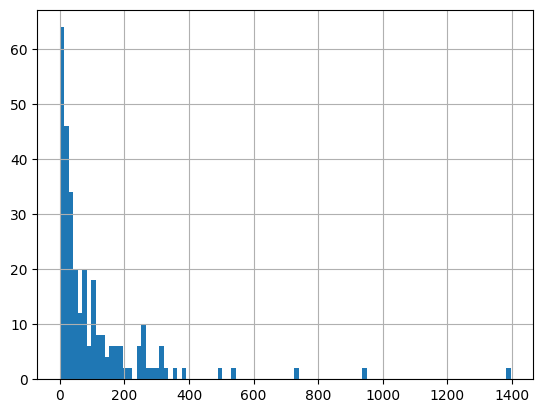

In [ ]:
results_df.chi2.hist(bins=100)

<Axes: >

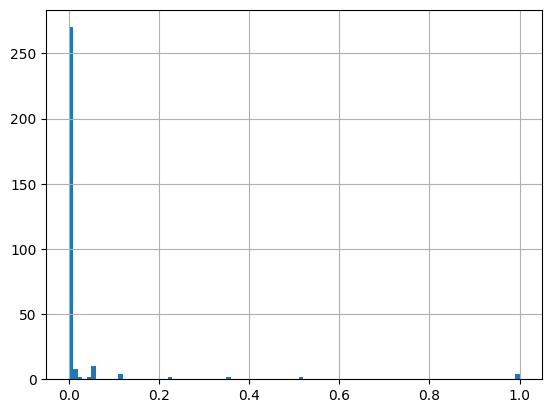

In [ ]:
results_df.p_value.hist(bins=100)

<Axes: >

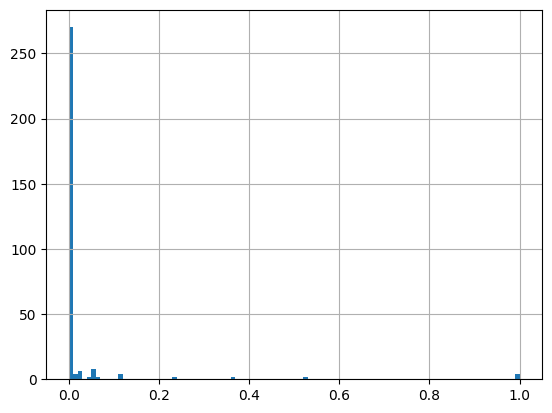

In [ ]:
results_df['fdr_corrected_p_value'].hist(bins=100)  

Text(0.5, 1.0, 'Chi2 vs P-value for Site Associations')

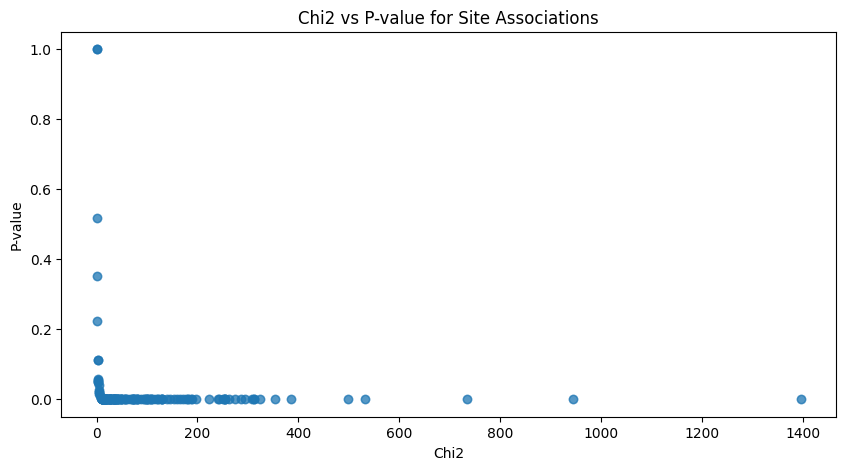

In [ ]:
# plot the dostribution of chi2 and p-values pairs

plt.figure(figsize=(10, 5))
plt.scatter(results_df.chi2, results_df.p_value, alpha=0.5)
plt.xlabel('Chi2')
plt.ylabel('P-value')
plt.title('Chi2 vs P-value for Site Associations')

In [ ]:
results_df.sort_values(by='chi2', ascending=True, inplace=True)

In [ ]:
results_df

,site1,site2,contingency_table,chi2,p_value,fdr_corrected_p_value
27,31,43,"[[1, 440], [25, 7295]]",0.000000,1.000000e+00,1.000000e+00
189,43,34,"[[1, 25], [294, 7441]]",0.000000,1.000000e+00,1.000000e+00
188,43,31,"[[1, 25], [440, 7295]]",0.000000,1.000000e+00,1.000000e+00
44,34,43,"[[1, 294], [25, 7441]]",0.000000,1.000000e+00,1.000000e+00
47,34,46,"[[8, 287], [149, 7317]]",0.417457,5.182084e-01,5.250721e-01
...,...,...,...,...,...,...
72,36,37,"[[876, 1505], [578, 4802]]",733.841822,1.308646e-161,6.674094e-160
71,36,35,"[[1238, 1143], [962, 4418]]",944.007315,2.663236e-207,2.037376e-205
54,35,36,"[[1238, 962], [1143, 4418]]",944.007315,2.663236e-207,2.037376e-205
18,31,34,"[[163, 278], [132, 7188]]",1396.481088,1.222072e-305,1.869770e-303


In [ ]:
def calculate_association_between_sites(site_sub_probs_df, site1, site2):
    """
    Calculate the association between two sites based on their mutation probabilities.

    Simplest function - doesn't matter what the parent or child is, only aggregating over an occurence of a mutaiton at each site.
    """
    cfs_with_site1_mutation = site_sub_probs_df[(site_sub_probs_df['site'] == site1) & (site_sub_probs_df_germline.mutation == True)][['family', 'sample_id']].drop_duplicates()
    cfs_with_site2_mutation = site_sub_probs_df[(site_sub_probs_df['site'] == site2) & (site_sub_probs_df_germline.mutation == True)][['family', 'sample_id']].drop_duplicates()
    
    cfs_count = len(site_sub_probs_df_germline[['family', 'sample_id']].drop_duplicates())

    cfs_with_both_mutations = len(pd.merge(cfs_with_site1_mutation, cfs_with_site2_mutation, on=['family', 'sample_id'], how='inner'))
    cfs_with_site1_mutation_only = len(cfs_with_site1_mutation) - cfs_with_both_mutations
    cfs_with_site2_mutation_only = len(cfs_with_site2_mutation) - cfs_with_both_mutations
    cfs_with_neither_mutation = cfs_count - (cfs_with_both_mutations + cfs_with_site1_mutation_only + cfs_with_site2_mutation_only)
    
    contingency_table = np.array([
        [cfs_with_both_mutations, cfs_with_site1_mutation_only],
        [cfs_with_site2_mutation_only, cfs_with_neither_mutation]
    ])  
    
    # calculate chi-squared statistic with package
    chi2, p_value, dof, expected_freq = chi2_contingency(contingency_table)
    
    # Determine association type
    observed_both = cfs_with_both_mutations
    observed_neither = cfs_with_neither_mutation
    observed_site1_only = cfs_with_site1_mutation_only
    observed_site2_only = cfs_with_site2_mutation_only
    
    # Calculate odds ratio to determine association direction
    if observed_site1_only * observed_site2_only == 0:
        # Avoid division by zero
        odds_ratio = float('inf') if observed_both * observed_neither > 0 else 0
    else:
        odds_ratio = (observed_both * observed_neither) / (observed_site1_only * observed_site2_only)
    
    # Determine association type
    if odds_ratio > 1:
        association_type = "positive"  # Co-occurrence
    elif odds_ratio < 1:
        association_type = "negative"  # Mutual exclusion
    else:
        association_type = "independent"
    
    return contingency_table, chi2, p_value, odds_ratio, association_type

In [ ]:
table, chi2, p_val, odds_ratio, assoc_type = calculate_association_between_sites(site_sub_probs_df_germline, 30, 50)
print(f"Chi2: {chi2:.3f}, p: {p_val:.3e}, OR: {odds_ratio:.3f}, Type: {assoc_type}")

Chi2: 31.014, p: 2.562e-08, OR: 2.213, Type: positive


In [ ]:
results = []
sites = site_sub_probs_df_germline['site'].unique()
for i in tqdm.tqdm(sites):
    for j in sites:
        if i > j:
            try:
                contingency_table, chi2, p_value, odds_ratio, association_type = calculate_association_between_sites(site_sub_probs_df_germline, i, j)
                results.append({
                    'site1': i,
                    'site2': j,
                    'contingency_table': contingency_table,
                    'chi2': chi2,
                    'p_value': p_value,
                    'odds_ratio': odds_ratio,
                    'association_type': association_type

                })
            except:
                pass
results_df = pd.DataFrame(results)



  0%|          | 0/144 [00:00<?, ?it/s]

100%|██████████| 144/144 [22:37<00:00,  9.43s/it]


results_df.to_csv(f"{test_output_prefix}-counts_association_results.csv", index=False)

In [ ]:
results_df.association_type.value_counts()

association_type
positive    8529
negative     924
Name: count, dtype: int64

In [ ]:
results_df.sort_values(by='association_type')

,site1,site2,contingency_table,chi2,p_value,odds_ratio,association_type
40,34,39,"[[5, 290], [792, 6674]]",23.508986,1.243317e-06,0.145289,negative
23,31,39,"[[7, 434], [790, 6530]]",37.255014,1.036482e-09,0.133320,negative
188,43,31,"[[1, 25], [440, 7295]]",0.000000,1.000000e+00,0.663182,negative
120,39,31,"[[7, 790], [434, 6530]]",37.255014,1.036482e-09,0.133320,negative
121,39,34,"[[5, 792], [290, 6674]]",23.508986,1.243317e-06,0.145289,negative
...,...,...,...,...,...,...,...
100,37,48,"[[298, 1156], [437, 5870]]",252.071455,9.180179e-57,3.462702,positive
99,37,47,"[[90, 1364], [149, 6158]]",56.717516,5.031339e-14,2.726978,positive
98,37,46,"[[56, 1398], [101, 6206]]",29.057378,7.026598e-08,2.461338,positive
96,37,44,"[[91, 1363], [164, 6143]]",48.619676,3.107360e-12,2.500819,positive


In [ ]:
results_df['log_odds_ratio'] = np.log(results_df['odds_ratio'])


/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


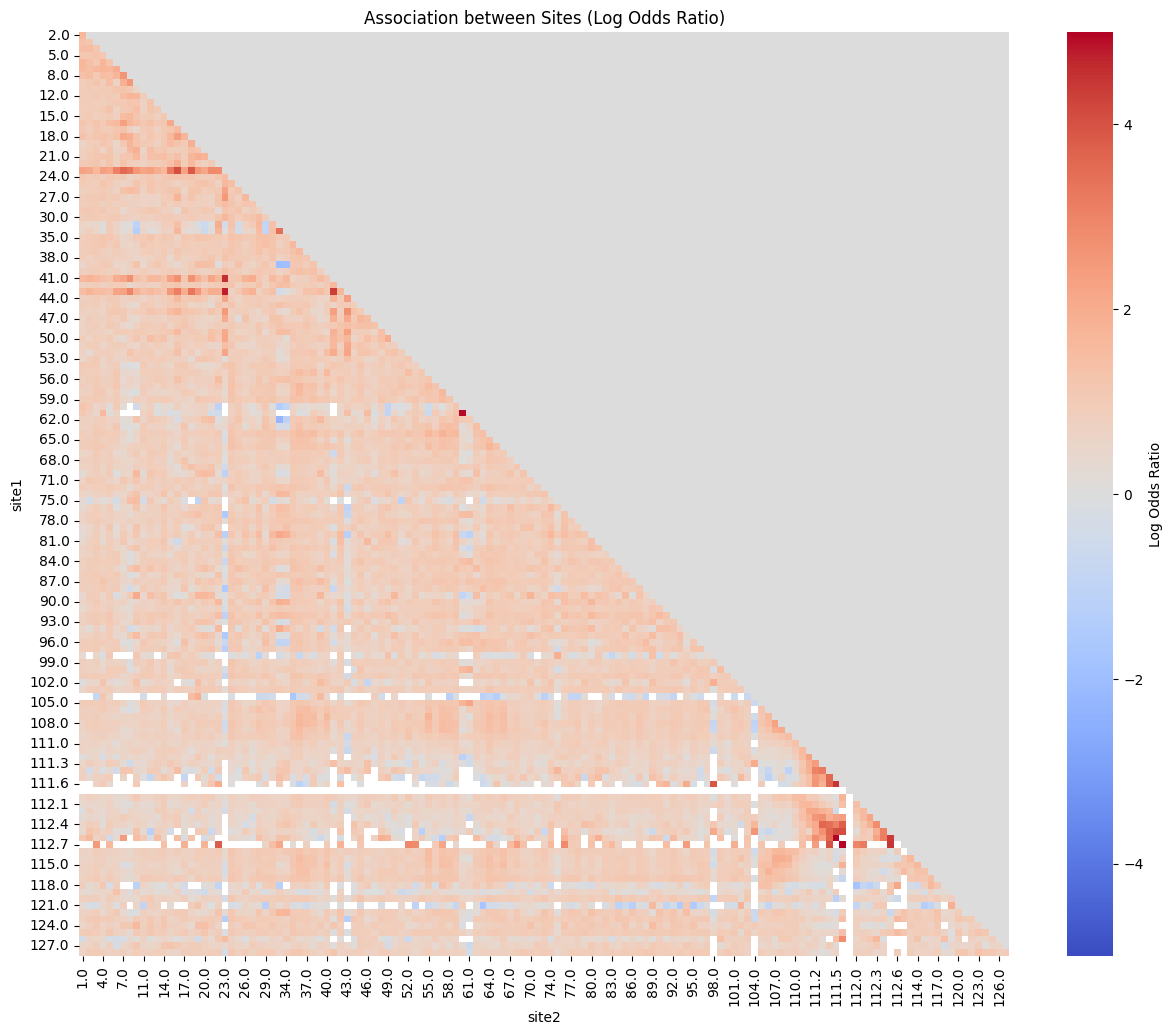

In [ ]:
# plot a heatmap for the association between sites using the log_odds_ratio
heatmap_data = results_df.pivot_table(index='site1', columns='site2', values='log_odds_ratio', fill_value=0)
heatmap_data = heatmap_data.reindex(sorted(heatmap_data.index))
heatmap_data = heatmap_data.astype(float)
fig, ax = plt.subplots(figsize=(15, 12))
sns.heatmap(heatmap_data, cmap='coolwarm',cbar_kws={'label': 'Log Odds Ratio'}, vmin=-5, vmax=5)
plt.title('Association between Sites (Log Odds Ratio)')
plt.show()

In [ ]:
## need to first filter only for pcps where both sites imgt are present
## also - maybe filter for a subset of pcps. maybe a v family? maybe a v gene?
## need to flip the 112,1, 112.4 order etc

## also, maybe remove the germline filter??

In [ ]:
def calculate_association_between_sites(site_sub_probs_df_germline, site1, site2):
    """
    Calculate the association between two sites based on their mutation probabilities.

    Simplest function - doesn't matter what the parent or child is, only aggregating over an occurence of a mutaiton at each site.
    """
    cfs_with_both_sites = pd.merge(site_sub_probs_df_germline[(site_sub_probs_df_germline['site'] == site1)][['family', 'sample_id']].drop_duplicates(), site_sub_probs_df_germline[(site_sub_probs_df_germline['site'] == site2)][['family', 'sample_id']].drop_duplicates(), on=['family', 'sample_id'], how='inner')

    cur_df = pd.merge(site_sub_probs_df_germline, cfs_with_both_sites, on=['family', 'sample_id'], how='inner')

    cfs_with_site1_mutation = cur_df[(cur_df['site'] == site1) & (cur_df.mutation == True)][['family', 'sample_id']].drop_duplicates()
    cfs_with_site2_mutation = cur_df[(cur_df['site'] == site2) & (cur_df.mutation == True)][['family', 'sample_id']].drop_duplicates()
    cfs_count = len(cur_df[['family', 'sample_id']].drop_duplicates())

    cfs_with_both_mutations = len(pd.merge(cfs_with_site1_mutation, cfs_with_site2_mutation, on=['family', 'sample_id'], how='inner'))
    cfs_with_site1_mutation_only = len(cfs_with_site1_mutation) - cfs_with_both_mutations
    cfs_with_site2_mutation_only = len(cfs_with_site2_mutation) - cfs_with_both_mutations
    cfs_with_neither_mutation = cfs_count - (cfs_with_both_mutations + cfs_with_site1_mutation_only + cfs_with_site2_mutation_only)
    
    contingency_table = np.array([
        [cfs_with_both_mutations, cfs_with_site1_mutation_only],
        [cfs_with_site2_mutation_only, cfs_with_neither_mutation]
    ])  
    # calculate chi-squared statistic with package
    chi2, p_value, dof, expected_freq = chi2_contingency(contingency_table)
    
    # Determine association type
    observed_both = cfs_with_both_mutations
    observed_neither = cfs_with_neither_mutation
    observed_site1_only = cfs_with_site1_mutation_only
    observed_site2_only = cfs_with_site2_mutation_only
    
    # Calculate odds ratio to determine association direction
    if observed_site1_only * observed_site2_only == 0:
        # Avoid division by zero
        odds_ratio = float('inf') if observed_both * observed_neither > 0 else 0
    else:
        odds_ratio = (observed_both * observed_neither) / (observed_site1_only * observed_site2_only)
    
    # Determine association type
    if odds_ratio > 1:
        association_type = "positive"  # Co-occurrence
    elif odds_ratio < 1:
        association_type = "negative"  # Mutual exclusion
    else:
        association_type = "independent"
    
    return contingency_table, chi2, p_value, odds_ratio, association_type

In [ ]:
results = []
site_sub_probs_df_germline_v1 = site_sub_probs_df_germline[site_sub_probs_df_germline['v_family'] == 'IGHV1']
sites = site_sub_probs_df_germline['site'].unique()

for i in tqdm.tqdm(sites):
    for j in sites:
        if i > j:
            try:
                contingency_table, chi2, p_value, odds_ratio, association_type = calculate_association_between_sites(site_sub_probs_df_germline_v1, i, j)
                results.append({
                    'site1': i,
                    'site2': j,
                    'contingency_table': contingency_table,
                    'chi2': chi2,
                    'p_value': p_value,
                    'odds_ratio': odds_ratio,
                    'association_type': association_type

                })
            except:
                pass
results_df = pd.DataFrame(results)
results_df['log_odds_ratio'] = np.log(results_df['odds_ratio'])




 20%|██        | 29/144 [01:10<08:35,  4.48s/it]/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/scipy/stats/contingency.py:135: RuntimeWarning: invalid value encountered in divide
  expected = reduce(np.multiply, margsums) / observed.sum() ** (d - 1)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/scipy/stats/contingency.py:135: RuntimeWarning: invalid value encountered in divide
  expected = reduce(np.multiply, margsums) / observed.sum() ** (d - 1)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/scipy/stats/contingency.py:135: RuntimeWarning: invalid value encountered in divide
  expected = reduce(np.multiply, margsums) / observed.sum() ** (d - 1)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/scipy/stats/contingency.py:135: RuntimeWarning: invalid value encountered in divide
  expected = reduce(np.multiply, margsums) / observed.sum() ** (d - 1)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-p

/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


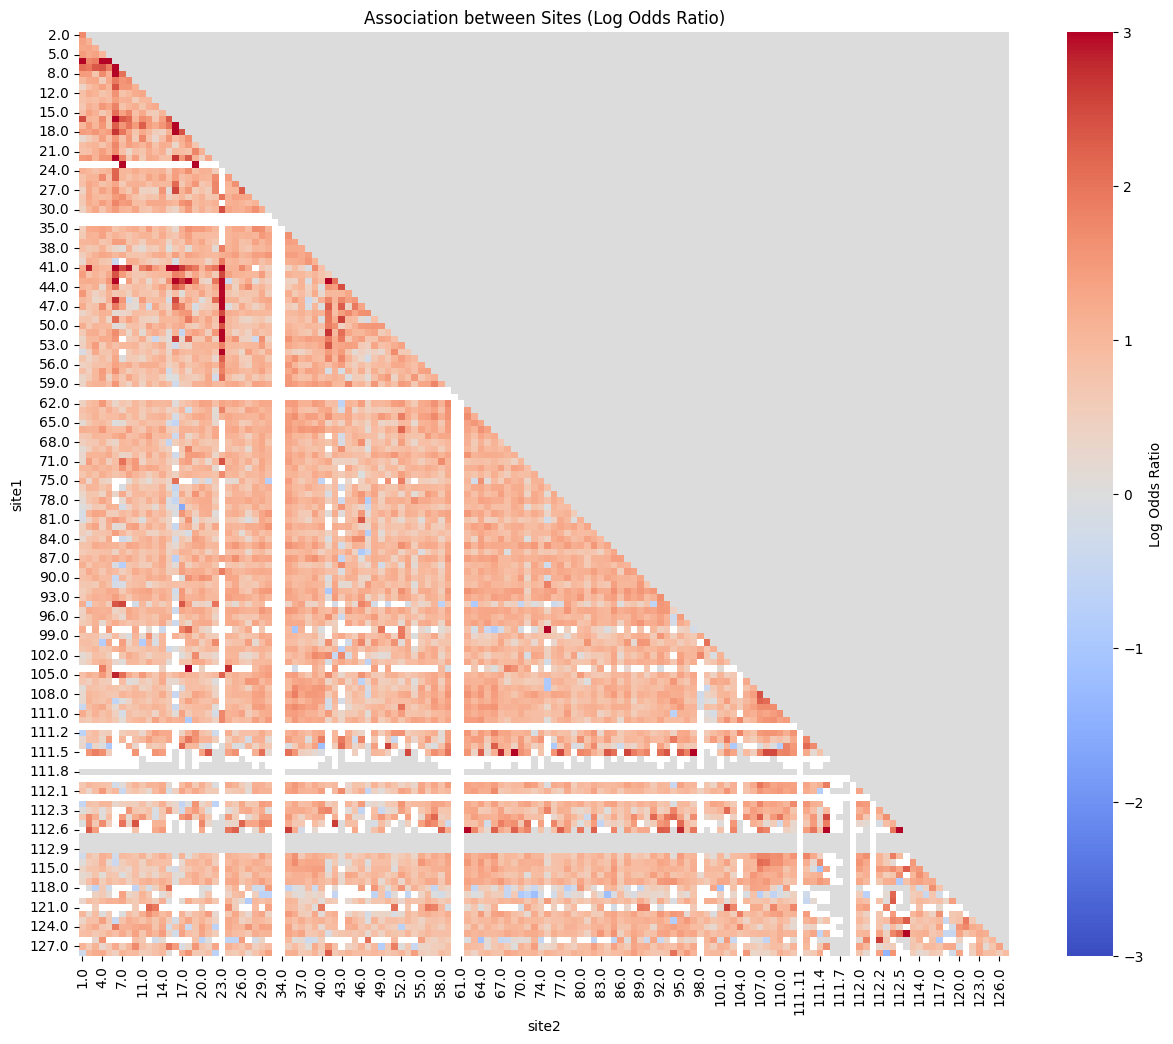

In [ ]:
# plot a heatmap for the association between sites using the log_odds_ratio
heatmap_data = results_df.pivot_table(index='site1', columns='site2', values='log_odds_ratio', fill_value=0)
heatmap_data = heatmap_data.reindex(sorted(heatmap_data.index))
heatmap_data = heatmap_data.astype(float)
fig, ax = plt.subplots(figsize=(15, 12))
sns.heatmap(heatmap_data, cmap='coolwarm',cbar_kws={'label': 'Log Odds Ratio'}, vmin=-3, vmax=3)
plt.title('Association between Sites (Log Odds Ratio)')
plt.show()

In [ ]:
results_df.to_csv(f"{test_output_prefix}-counts_association_results_ighv1.csv", index=False)

In [ ]:
results_df

,site1,site2,contingency_table,chi2,p_value,odds_ratio,association_type,log_odds_ratio
0,2.0,1.0,"[[22, 122], [46, 1411]]",44.404748,2.670386e-11,5.531361,positive,1.710434
1,3.0,1.0,"[[27, 226], [41, 1307]]",28.648779,8.676870e-08,3.808439,positive,1.337220
2,3.0,2.0,"[[48, 205], [96, 1252]]",35.114716,3.108429e-09,3.053659,positive,1.116340
3,4.0,1.0,"[[10, 70], [58, 1463]]",12.046635,5.188597e-04,3.603448,positive,1.281891
4,4.0,2.0,"[[20, 60], [124, 1397]]",24.336633,8.088608e-07,3.755376,positive,1.323189
...,...,...,...,...,...,...,...,...
9574,128.0,123.0,"[[30, 64], [179, 1328]]",29.557211,5.429030e-08,3.477654,positive,1.246358
9575,128.0,124.0,"[[11, 83], [78, 1429]]",5.989028,1.439514e-02,2.428020,positive,0.887076
9576,128.0,125.0,"[[25, 69], [195, 1312]]",12.792756,3.479641e-04,2.437755,positive,0.891078
9577,128.0,126.0,"[[1, 93], [9, 1498]]",0.000000,1.000000e+00,1.789725,positive,0.582062


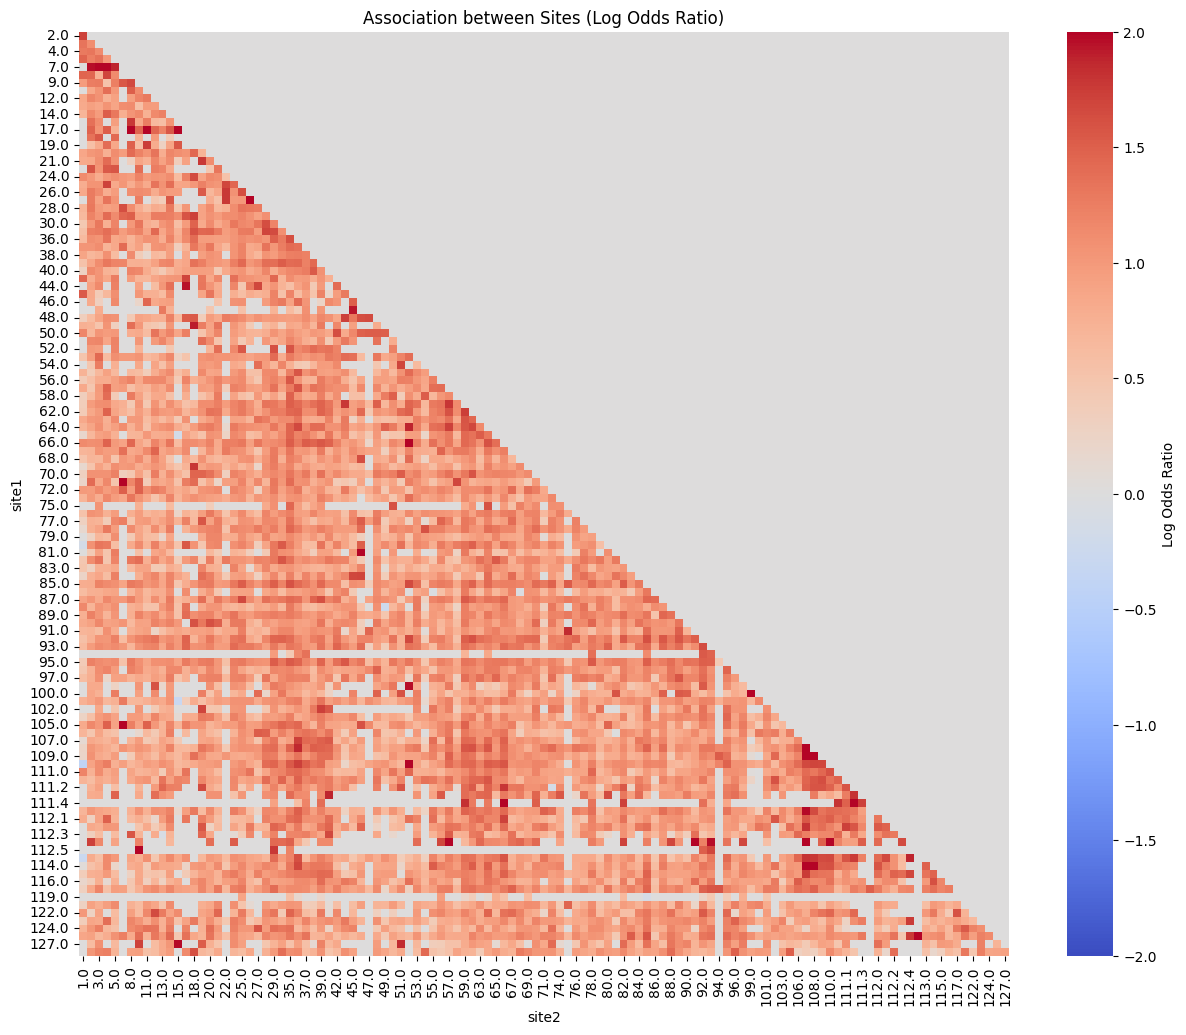

In [ ]:
# filter results df for rows where both mutations have been seen more then 10 times according to the contingency table
results_df_filtered = results_df[(results_df['contingency_table'].apply(lambda x: x[0, 0]) > 5) & (results_df['contingency_table'].apply(lambda x: x[1, 1]) > 5) & (results_df['contingency_table'].apply(lambda x: x[0, 1]) > 5) & (results_df['contingency_table'].apply(lambda x: x[1, 0]) > 5)]


# plot a heatmap for the association between sites using the log_odds_ratio
heatmap_data = results_df_filtered.pivot_table(index='site1', columns='site2', values='log_odds_ratio', fill_value=0)
heatmap_data = heatmap_data.reindex(sorted(heatmap_data.index))
heatmap_data = heatmap_data.astype(float)
fig, ax = plt.subplots(figsize=(15, 12))
sns.heatmap(heatmap_data, cmap='coolwarm',cbar_kws={'label': 'Log Odds Ratio'}, vmin=-2, vmax=2)
plt.title('Association between Sites (Log Odds Ratio)')
plt.show()

In [ ]:
site_sub_probs_df_germline_v1

,neutral_prob,selection_factor,prob,mutation,pcp_index,site,is_cdr,parent_codon,parent_aa,child_codon,...,v_family,j_family,sample_id,family,log_selection_factor,germline_codon,germline_amino_acid,is_germline_aa,is_germline_codon,is_one_mutation_away
52,0.017692,0.126629,0.002240,False,52,1.0,False,CAG,Q,CAG,...,IGHV1,IGHJ4,sample-igg-SC-24,995,-2.066490,CAG,Q,True,True,False
53,0.178223,0.129744,0.023123,False,53,1.0,False,CAG,Q,CAA,...,IGHV1,IGHJ4,sample-igg-SC-24,995,-2.042195,CAG,Q,True,True,True
54,0.204427,0.129744,0.026523,False,54,1.0,False,CAG,Q,CAG,...,IGHV1,IGHJ4,sample-igg-SC-24,995,-2.042195,CAG,Q,True,True,False
55,0.251854,0.126629,0.031892,False,55,1.0,False,CAG,Q,CAG,...,IGHV1,IGHJ4,sample-igg-SC-24,995,-2.066490,CAG,Q,True,True,False
64,0.082727,0.118290,0.009786,True,64,1.0,False,CAG,Q,CGG,...,IGHV1,IGHJ4,sample-igg-SC-24,141,-2.134616,CAG,Q,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2646349,0.002358,0.589386,0.001390,False,21730,128.0,False,TCA,S,TCA,...,IGHV1,IGHJ4,sample-igg-W-92,82,-0.528674,NaN,NaN,False,False,False
2646363,0.014877,1.087926,0.016185,False,21744,128.0,False,TCA,S,TCA,...,IGHV1,IGHJ6,sample-igg-W-1,186,0.084273,NaN,NaN,False,False,False
2646364,0.013142,1.087926,0.014297,False,21745,128.0,False,TCA,S,TCA,...,IGHV1,IGHJ6,sample-igg-W-1,186,0.084273,NaN,NaN,False,False,False
2646366,0.001440,1.122413,0.001617,False,21747,128.0,False,TCA,S,TCA,...,IGHV1,IGHJ1,sample-igg-W-109,62,0.115481,NaN,NaN,False,False,False


In [ ]:
site_sub_probs_df_germline

,neutral_prob,selection_factor,prob,mutation,pcp_index,site,is_cdr,parent_codon,parent_aa,child_codon,...,v_family,j_family,sample_id,family,log_selection_factor,germline_codon,germline_amino_acid,is_germline_aa,is_germline_codon,is_one_mutation_away
0,0.102066,0.132334,0.013507,False,0,1.0,False,CAG,Q,CAG,...,IGHV7,IGHJ4,sample-igg-SC-24,1401,-2.022430,CAG,Q,True,True,False
1,0.030019,0.132334,0.003972,False,1,1.0,False,CAG,Q,CAG,...,IGHV7,IGHJ4,sample-igg-SC-24,1401,-2.022430,CAG,Q,True,True,False
2,0.011072,0.229902,0.002546,False,2,1.0,False,CAG,Q,CAG,...,IGHV4,IGHJ4,sample-igg-SC-24,474,-1.470103,CAG,Q,True,True,False
3,0.054606,0.262477,0.014333,False,3,1.0,False,CAG,Q,CAG,...,IGHV4,IGHJ6,sample-igg-SC-24,238,-1.337593,CAG,Q,True,True,False
4,0.010781,0.262477,0.002830,False,4,1.0,False,CAG,Q,CAG,...,IGHV4,IGHJ6,sample-igg-SC-24,238,-1.337593,CAG,Q,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2646366,0.001440,1.122413,0.001617,False,21747,128.0,False,TCA,S,TCA,...,IGHV1,IGHJ1,sample-igg-W-109,62,0.115481,NaN,NaN,False,False,False
2646367,0.001785,1.077277,0.001923,False,21748,128.0,False,TCA,S,TCA,...,IGHV3,IGHJ5,sample-igg-W-109,10,0.074437,NaN,NaN,False,False,False
2646368,0.001744,1.077277,0.001879,False,21749,128.0,False,TCA,S,TCA,...,IGHV3,IGHJ5,sample-igg-W-109,10,0.074437,NaN,NaN,False,False,False
2646369,0.001797,1.249783,0.002246,False,21750,128.0,False,TCA,S,TCA,...,IGHV1,IGHJ4,sample-igg-W-117,10,0.222970,NaN,NaN,False,False,False


In [ ]:
site_sub_probs_df_germline_v1 = site_sub_probs_df_germline[site_sub_probs_df_germline['v_family'] == 'IGHV1']


In [ ]:
trees_df = pd.read_csv('/fh/fast/matsen_e/shared/bcr-mut-sel/pcps/v3/trees/rodriguez-airr-seq-race-prod-NoWinCheck_igh_trees_2024-11-12.csv.gz', compression='gzip')

In [ ]:
def calculate_mutation_directionality_newick(site_sub_probs_df_germline, trees_df, pcp_df, site1, site2):
    """
    Calculate mutation directionality using Newick trees for phylogeny
    
    Parameters:
    -----------
    site_sub_probs_df_germline : pandas.DataFrame
        DataFrame containing mutation data
    trees_df : pandas.DataFrame
        DataFrame containing Newick trees
    pcp_df : pandas.DataFrame
        DataFrame containing parent-child pairs
    site1 : int
        First site to analyze
    site2 : int
        Second site to analyze
    
    Returns:
    --------
    dict
        Dictionary containing directionality results
    """
    import pandas as pd
    import numpy as np
    
    def get_pcp_index_to_node_mapping(pcp_df, family, sample_id):
        """Map pcp_index to node names from pcp_df"""
        family_pcp = pcp_df[
            (pcp_df['family'] == family) & 
            (pcp_df['sample_id'] == sample_id)
        ]
        
        pcp_to_node = {}
        for idx, row in family_pcp.iterrows():
            if pd.notna(row['child_name']):
                pcp_to_node[idx] = row['child_name']
        
        return pcp_to_node
    
    def parse_newick_robust(newick_string):
        """Parse Newick tree to get parent-child relationships"""
        import re
        
        if not newick_string or pd.isna(newick_string):
            return {}
        
        newick_string = newick_string.strip()
        if newick_string.endswith(';'):
            newick_string = newick_string[:-1]
        
        child_to_parent = {}
        pattern = r'\(([^()]+)\)([^:(),]+)'
        
        def process_group(content, parent_name):
            children = [child.strip() for child in content.split(',')]
            for child in children:
                child_name = re.sub(r':[0-9.e-]+', '', child).strip()
                if child_name and parent_name:
                    child_to_parent[child_name] = parent_name
        
        current_newick = newick_string
        iteration = 0
        
        while '(' in current_newick and iteration < 100:
            matches = list(re.finditer(pattern, current_newick))
            if not matches:
                break
            
            for match in reversed(matches):
                content = match.group(1)
                parent_name = match.group(2)
                process_group(content, parent_name)
                current_newick = current_newick[:match.start()] + parent_name + current_newick[match.end():]
            
            iteration += 1
        
        return child_to_parent
    
    def find_ancestral_path(child_to_parent, target_node):
        """Find path from root to target node"""
        path = []
        current = target_node
        visited = set()
        
        while current is not None and current not in visited:
            path.append(current)
            visited.add(current)
            current = child_to_parent.get(current)
            
            if len(path) > 1000:
                break
        
        return list(reversed(path))
    
    def mcnemar_test(b, c, exact=True):
        """McNemar test for paired data"""
        try:
            from scipy.stats import binom, chi2
        except ImportError:
            if b + c == 0:
                return {'statistic': 0, 'pvalue': 1.0}
            n = b + c
            p_value = 2 * min(b, c) / n if n > 0 else 1.0
            return {'statistic': abs(b - c), 'pvalue': p_value}
        
        n = b + c
        if n == 0:
            return {'statistic': 0, 'pvalue': 1.0}
        
        if exact or n < 25:
            p_value = 2 * binom.cdf(min(b, c), n, 0.5)
            if p_value > 1:
                p_value = 2 * (1 - binom.cdf(max(b, c) - 1, n, 0.5))
            statistic = abs(b - c)
        else:
            statistic = (abs(b - c) - 1)**2 / n
            p_value = 1 - chi2.cdf(statistic, 1)
        
        return {'statistic': statistic, 'pvalue': p_value}
    
    # Get mutations
    site1_mutations = site_sub_probs_df_germline[
        (site_sub_probs_df_germline['site'] == site1) & 
        (site_sub_probs_df_germline['mutation'] == True)
    ][['family', 'sample_id', 'pcp_index']].copy()
    
    site2_mutations = site_sub_probs_df_germline[
        (site_sub_probs_df_germline['site'] == site2) & 
        (site_sub_probs_df_germline['mutation'] == True)
    ][['family', 'sample_id', 'pcp_index']].copy()
    
    families_with_both = set(zip(site1_mutations['family'], site1_mutations['sample_id'])).intersection(
                        set(zip(site2_mutations['family'], site2_mutations['sample_id'])))
    
    # Initialize counters
    site1_before_site2 = 0
    site2_before_site1 = 0
    simultaneous = 0
    parallel_branches = 0
    no_tree_structure = 0
    parsing_errors = 0
    mapping_errors = 0
    
    # Process each family
    for family, sample_id in families_with_both:
        # Get tree structure
        tree_row = trees_df[
            (trees_df['family'] == family) & 
            (trees_df['sample_id'] == sample_id)
        ]
        
        if len(tree_row) == 0:
            no_tree_structure += 1
            continue
        
        newick_string = tree_row['newick'].iloc[0]
        pcp_to_node = get_pcp_index_to_node_mapping(pcp_df, family, sample_id)
        
        try:
            child_to_parent = parse_newick_robust(newick_string)
        except Exception:
            parsing_errors += 1
            continue
        
        if not child_to_parent or not pcp_to_node:
            no_tree_structure += 1
            continue
        
        # Get mutations for this family
        family_site1 = site1_mutations[
            (site1_mutations['family'] == family) & 
            (site1_mutations['sample_id'] == sample_id)
        ]
        family_site2 = site2_mutations[
            (site2_mutations['family'] == family) & 
            (site2_mutations['sample_id'] == sample_id)
        ]
        
        # Compare all pairs of mutations
        for _, mut1 in family_site1.iterrows():
            for _, mut2 in family_site2.iterrows():
                node_name1 = pcp_to_node.get(mut1['pcp_index'])
                node_name2 = pcp_to_node.get(mut2['pcp_index'])
                
                if node_name1 is None or node_name2 is None:
                    mapping_errors += 1
                    continue
                
                if node_name1 == node_name2:
                    simultaneous += 1
                    continue
                
                # Find paths in the phylogenetic tree
                path1 = find_ancestral_path(child_to_parent, node_name1)
                path2 = find_ancestral_path(child_to_parent, node_name2)
                
                if len(path1) == 0 or len(path2) == 0:
                    no_tree_structure += 1
                    continue
                
                # Check ancestral relationships
                if node_name1 in path2:
                    site1_before_site2 += 1
                elif node_name2 in path1:
                    site2_before_site1 += 1
                else:
                    common_ancestors = set(path1).intersection(set(path2))
                    if common_ancestors:
                        parallel_branches += 1
                    else:
                        no_tree_structure += 1
    
    total_ordered = site1_before_site2 + site2_before_site1
    
    # Print results
    print(f"Mutation Directionality Analysis: Site {site1} vs Site {site2}")
    print("=" * 60)
    print(f"Site {site1} mutations: {len(site1_mutations):,}")
    print(f"Site {site2} mutations: {len(site2_mutations):,}")
    print(f"Families with both mutations: {len(families_with_both):,}")
    print()
    print("Temporal Relationships:")
    print(f"  Site {site1} before Site {site2}: {site1_before_site2:,}")
    print(f"  Site {site2} before Site {site1}: {site2_before_site1:,}")
    print(f"  Simultaneous mutations: {simultaneous:,}")
    print(f"  Parallel branches: {parallel_branches:,}")
    print(f"  Total ordered cases: {total_ordered:,}")
    print()
    print("Data Quality:")
    print(f"  No tree structure: {no_tree_structure:,}")
    print(f"  Mapping errors: {mapping_errors:,}")
    print(f"  Parsing errors: {parsing_errors:,}")
    
    if total_ordered < 5:
        print(f"\nInsufficient ordered cases ({total_ordered} < 5) for statistical analysis")
        return None
    
    # Statistical analysis
    result = mcnemar_test(site1_before_site2, site2_before_site1, exact=True)
    direction_ratio = site1_before_site2 / total_ordered if total_ordered > 0 else 0.5
    
    print()
    print("Statistical Analysis:")
    print(f"  McNemar statistic: {result['statistic']:.3f}")
    print(f"  P-value: {result['pvalue']:.3e}")
    print(f"  Direction ratio: {direction_ratio:.3f}")
    
    if result['pvalue'] < 0.05:
        preferred = 'Site ' + str(site1 if direction_ratio > 0.5 else site2) + ' first'
        print(f"  Preferred direction: {preferred} (p < 0.05)")
    else:
        print(f"  No significant directional bias (p ≥ 0.05)")
    
    return {
        'site1_before_site2': site1_before_site2,
        'site2_before_site1': site2_before_site1,
        'simultaneous': simultaneous,
        'parallel_branches': parallel_branches,
        'no_tree_structure': no_tree_structure,
        'mapping_errors': mapping_errors,
        'parsing_errors': parsing_errors,
        'total_ordered': total_ordered,
        'mcnemar_statistic': result['statistic'],
        'mcnemar_pvalue': result['pvalue'],
        'direction_ratio': direction_ratio,
        'preferred_direction': 'site1_first' if direction_ratio > 0.5 else 'site2_first'
    }


def calculate_mutation_association(site_sub_probs_df_germline, site1, site2):
    """
    Calculate association between mutations at two sites
    
    Parameters:
    -----------
    site_sub_probs_df_germline : pandas.DataFrame
        DataFrame containing mutation data
    site1 : int
        First site to analyze
    site2 : int
        Second site to analyze
    
    Returns:
    --------
    dict
        Dictionary containing association results
    """
    import pandas as pd
    import numpy as np
    
    try:
        from scipy.stats import chi2_contingency
        scipy_available = True
    except ImportError:
        scipy_available = False
    
    # Get mutations for each site
    site1_mutations = site_sub_probs_df_germline[
        (site_sub_probs_df_germline['site'] == site1) & 
        (site_sub_probs_df_germline['mutation'] == True)
    ][['family', 'sample_id']].drop_duplicates()
    
    site2_mutations = site_sub_probs_df_germline[
        (site_sub_probs_df_germline['site'] == site2) & 
        (site_sub_probs_df_germline['mutation'] == True)
    ][['family', 'sample_id']].drop_duplicates()
    
    # Get all unique families
    all_families = site_sub_probs_df_germline[['family', 'sample_id']].drop_duplicates()
    
    # Create sets for easier operations
    site1_families = set(zip(site1_mutations['family'], site1_mutations['sample_id']))
    site2_families = set(zip(site2_mutations['family'], site2_mutations['sample_id']))
    all_families_set = set(zip(all_families['family'], all_families['sample_id']))
    
    # Calculate contingency table
    families_both_same_lineage = len(site1_families.intersection(site2_families))
    families_site1_only = len(site1_families - site2_families)
    families_site2_only = len(site2_families - site1_families)
    families_neither = len(all_families_set - site1_families - site2_families)
    families_parallel_mutations = 0  # Basic version doesn't detect parallel mutations
    total_families = len(all_families_set)
    
    # Create contingency table
    contingency_table = np.array([
        [families_both_same_lineage, families_site1_only],
        [families_site2_only, families_neither]
    ])
    
    # Calculate chi-square test
    if scipy_available:
        chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    else:
        # Manual calculation
        observed = contingency_table
        row_totals = observed.sum(axis=1)
        col_totals = observed.sum(axis=0)
        total = observed.sum()
        
        expected = np.outer(row_totals, col_totals) / total
        chi2 = np.sum((observed - expected)**2 / expected)
        
        if chi2 > 10.83:
            p_value = 0.001
        elif chi2 > 6.63:
            p_value = 0.01
        elif chi2 > 3.84:
            p_value = 0.05
        else:
            p_value = 0.1
    
    # Calculate odds ratio
    a = families_both_same_lineage
    b = families_site1_only
    c = families_site2_only
    d = families_neither
    
    # Apply Haldane correction if any cell is 0
    if a == 0 or b == 0 or c == 0 or d == 0:
        odds_ratio = ((a + 0.5) * (d + 0.5)) / ((b + 0.5) * (c + 0.5))
    else:
        odds_ratio = (a * d) / (b * c)
    
    # Determine association type
    if odds_ratio > 1:
        association_type = 'positive'
    elif odds_ratio < 1:
        association_type = 'negative'
    else:
        association_type = 'none'
    
    # Print results
    print(f"Mutation Association Analysis: Site {site1} vs Site {site2}")
    print("=" * 60)
    print(f"Site {site1} mutations: {len(site1_mutations):,} families")
    print(f"Site {site2} mutations: {len(site2_mutations):,} families")
    print(f"Total families: {total_families:,}")
    print()
    print("Contingency Table:")
    print(f"  Both sites: {families_both_same_lineage:,}")
    print(f"  Site {site1} only: {families_site1_only:,}")
    print(f"  Site {site2} only: {families_site2_only:,}")
    print(f"  Neither site: {families_neither:,}")
    print()
    print("Statistical Results:")
    print(f"  Chi-square: {chi2:.3f}")
    print(f"  P-value: {p_value:.3e}")
    print(f"  Odds ratio: {odds_ratio:.3f}")
    print(f"  Association type: {association_type}")
    
    if p_value < 0.05:
        strength = "strong" if odds_ratio > 2 or odds_ratio < 0.5 else "moderate"
        print(f"  Significant {strength} {association_type} association (p < 0.05)")
    else:
        print(f"  No significant association (p ≥ 0.05)")
    
    return {
        'contingency_table': contingency_table,
        'chi2': chi2,
        'p_value': p_value,
        'odds_ratio': odds_ratio,
        'association_type': association_type,
        'families_both_same_lineage': families_both_same_lineage,
        'families_site1_only': families_site1_only,
        'families_site2_only': families_site2_only,
        'families_neither': families_neither,
        'families_parallel_mutations': families_parallel_mutations,
        'total_families': total_families
    }


def calculate_mutation_association_with_parallel_detection(site_sub_probs_df_germline, trees_df, pcp_df, site1, site2):
    """
    Calculate association between mutations with phylogenetic parallel mutation detection
    
    Parameters:
    -----------
    site_sub_probs_df_germline : pandas.DataFrame
        DataFrame containing mutation data
    trees_df : pandas.DataFrame
        DataFrame containing Newick trees
    pcp_df : pandas.DataFrame
        DataFrame containing parent-child pairs
    site1 : int
        First site to analyze
    site2 : int
        Second site to analyze
    
    Returns:
    --------
    dict
        Dictionary containing association results with parallel detection
    """
    import pandas as pd
    import numpy as np
    
    try:
        from scipy.stats import chi2_contingency
        scipy_available = True
    except ImportError:
        scipy_available = False
    
    # Get mutations for each site
    site1_mutations = site_sub_probs_df_germline[
        (site_sub_probs_df_germline['site'] == site1) & 
        (site_sub_probs_df_germline['mutation'] == True)
    ][['family', 'sample_id', 'pcp_index']].drop_duplicates()
    
    site2_mutations = site_sub_probs_df_germline[
        (site_sub_probs_df_germline['site'] == site2) & 
        (site_sub_probs_df_germline['mutation'] == True)
    ][['family', 'sample_id', 'pcp_index']].drop_duplicates()
    
    # Get all unique families
    all_families = site_sub_probs_df_germline[['family', 'sample_id']].drop_duplicates()
    
    # Create sets for easier operations
    site1_families = set(zip(site1_mutations['family'], site1_mutations['sample_id']))
    site2_families = set(zip(site2_mutations['family'], site2_mutations['sample_id']))
    all_families_set = set(zip(all_families['family'], all_families['sample_id']))
    
    # Find families with both mutations
    families_with_both = site1_families.intersection(site2_families)
    
    # Helper functions
    def get_pcp_index_to_node_mapping(pcp_df, family, sample_id):
        family_pcp = pcp_df[
            (pcp_df['family'] == family) & 
            (pcp_df['sample_id'] == sample_id)
        ]
        
        pcp_to_node = {}
        for idx, row in family_pcp.iterrows():
            if pd.notna(row['child_name']):
                pcp_to_node[idx] = row['child_name']
        
        return pcp_to_node
    
    def parse_newick_for_relationships(newick_string):
        import re
        
        if not newick_string or pd.isna(newick_string):
            return {}
        
        newick_string = newick_string.strip()
        if newick_string.endswith(';'):
            newick_string = newick_string[:-1]
        
        child_to_parent = {}
        pattern = r'\(([^()]+)\)([^:(),]+)'
        
        def process_group(content, parent_name):
            children = [child.strip() for child in content.split(',')]
            for child in children:
                child_name = re.sub(r':[0-9.e-]+', '', child).strip()
                if child_name and parent_name:
                    child_to_parent[child_name] = parent_name
        
        current_newick = newick_string
        iteration = 0
        
        while '(' in current_newick and iteration < 100:
            matches = list(re.finditer(pattern, current_newick))
            if not matches:
                break
            
            for match in reversed(matches):
                content = match.group(1)
                parent_name = match.group(2)
                process_group(content, parent_name)
                current_newick = current_newick[:match.start()] + parent_name + current_newick[match.end():]
            
            iteration += 1
        
        return child_to_parent
    
    def find_ancestral_path(child_to_parent, target_node):
        path = []
        current = target_node
        visited = set()
        
        while current is not None and current not in visited:
            path.append(current)
            visited.add(current)
            current = child_to_parent.get(current)
            
            if len(path) > 1000:
                break
        
        return list(reversed(path))
    
    # Classify mutations within families that have both
    families_both_same_lineage = 0
    families_parallel_mutations = 0
    
    # Analyze phylogenetic relationships
    for family, sample_id in families_with_both:
        # Get tree structure
        tree_row = trees_df[
            (trees_df['family'] == family) & 
            (trees_df['sample_id'] == sample_id)
        ]
        
        if len(tree_row) == 0:
            families_both_same_lineage += 1
            continue
        
        newick_string = tree_row['newick'].iloc[0]
        child_to_parent = parse_newick_for_relationships(newick_string)
        pcp_to_node = get_pcp_index_to_node_mapping(pcp_df, family, sample_id)
        
        if not child_to_parent or not pcp_to_node:
            families_both_same_lineage += 1
            continue
        
        # Get mutations for this family
        family_site1 = site1_mutations[
            (site1_mutations['family'] == family) & 
            (site1_mutations['sample_id'] == sample_id)
        ]
        family_site2 = site2_mutations[
            (site2_mutations['family'] == family) & 
            (site2_mutations['sample_id'] == sample_id)
        ]
        
        # Check if mutations are on the same lineage or parallel branches
        same_lineage = False
        parallel = False
        
        for _, mut1 in family_site1.iterrows():
            for _, mut2 in family_site2.iterrows():
                node_name1 = pcp_to_node.get(mut1['pcp_index'])
                node_name2 = pcp_to_node.get(mut2['pcp_index'])
                
                if node_name1 is None or node_name2 is None:
                    continue
                
                if node_name1 == node_name2:
                    same_lineage = True
                    break
                
                # Check if nodes are on the same lineage
                path1 = find_ancestral_path(child_to_parent, node_name1)
                path2 = find_ancestral_path(child_to_parent, node_name2)
                
                if node_name1 in path2 or node_name2 in path1:
                    same_lineage = True
                    break
                else:
                    # Check if they share a common ancestor (parallel)
                    common_ancestors = set(path1).intersection(set(path2))
                    if common_ancestors:
                        parallel = True
        
        if same_lineage:
            families_both_same_lineage += 1
        elif parallel:
            families_parallel_mutations += 1
        else:
            families_both_same_lineage += 1
    
    # Calculate remaining categories
    families_site1_only = len(site1_families - site2_families)
    families_site2_only = len(site2_families - site1_families)
    families_neither = len(all_families_set - site1_families - site2_families)
    total_families = len(all_families_set)
    
    # Create contingency table (excluding parallel mutations)
    contingency_table = np.array([
        [families_both_same_lineage, families_site1_only],
        [families_site2_only, families_neither]
    ])
    
    # Calculate chi-square test
    if scipy_available:
        chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    else:
        # Manual calculation
        observed = contingency_table
        row_totals = observed.sum(axis=1)
        col_totals = observed.sum(axis=0)
        total = observed.sum()
        
        expected = np.outer(row_totals, col_totals) / total
        chi2 = np.sum((observed - expected)**2 / expected)
        
        if chi2 > 10.83:
            p_value = 0.001
        elif chi2 > 6.63:
            p_value = 0.01
        elif chi2 > 3.84:
            p_value = 0.05
        else:
            p_value = 0.1
    
    # Calculate odds ratio
    a = families_both_same_lineage
    b = families_site1_only
    c = families_site2_only
    d = families_neither
    
    if a == 0 or b == 0 or c == 0 or d == 0:
        odds_ratio = ((a + 0.5) * (d + 0.5)) / ((b + 0.5) * (c + 0.5))
    else:
        odds_ratio = (a * d) / (b * c)
    
    # Determine association type
    if odds_ratio > 1:
        association_type = 'positive'
    elif odds_ratio < 1:
        association_type = 'negative'
    else:
        association_type = 'none'
    
    # Print results
    print(f"Enhanced Mutation Association Analysis: Site {site1} vs Site {site2}")
    print("=" * 70)
    print(f"Site {site1} mutations: {len(site1_mutations):,} families")
    print(f"Site {site2} mutations: {len(site2_mutations):,} families")
    print(f"Total families: {total_families:,}")
    print()
    print("Phylogenetic Classification:")
    print(f"  Both sites (same lineage): {families_both_same_lineage:,}")
    print(f"  Both sites (parallel branches): {families_parallel_mutations:,}")
    print(f"  Site {site1} only: {families_site1_only:,}")
    print(f"  Site {site2} only: {families_site2_only:,}")
    print(f"  Neither site: {families_neither:,}")
    print()
    print("Statistical Results (excluding parallel mutations):")
    print(f"  Chi-square: {chi2:.3f}")
    print(f"  P-value: {p_value:.3e}")
    print(f"  Odds ratio: {odds_ratio:.3f}")
    print(f"  Association type: {association_type}")
    
    if p_value < 0.05:
        strength = "strong" if odds_ratio > 2 or odds_ratio < 0.5 else "moderate"
        print(f"  Significant {strength} {association_type} association (p < 0.05)")
    else:
        print(f"  No significant association (p ≥ 0.05)")
    
    return {
        'contingency_table': contingency_table,
        'chi2': chi2,
        'p_value': p_value,
        'odds_ratio': odds_ratio,
        'association_type': association_type,
        'families_both_same_lineage': families_both_same_lineage,
        'families_site1_only': families_site1_only,
        'families_site2_only': families_site2_only,
        'families_neither': families_neither,
        'families_parallel_mutations': families_parallel_mutations,
        'total_families': total_families
    }

In [ ]:
# Directionality analysis
result1 = calculate_mutation_directionality_newick(
    site_sub_probs_df_germline, trees_df, pcp_df, 36, 108
)

# Basic association
result2 = calculate_mutation_association(
    site_sub_probs_df_germline, 36, 108
)

# Enhanced association with parallel detection
result3 = calculate_mutation_association_with_parallel_detection(
    site_sub_probs_df_germline, trees_df, pcp_df, 36, 108
)

Mutation Directionality Analysis: Site 36 vs Site 108
Site 36 mutations: 3,437
Site 108 mutations: 1,670
Families with both mutations: 849

Temporal Relationships:
  Site 36 before Site 108: 108
  Site 108 before Site 36: 114
  Simultaneous mutations: 591
  Parallel branches: 1,137
  Total ordered cases: 222

Data Quality:
  No tree structure: 11
  Mapping errors: 0
  Parsing errors: 0

Statistical Analysis:
  McNemar statistic: 6.000
  P-value: 7.373e-01
  Direction ratio: 0.486
  No significant directional bias (p ≥ 0.05)
Mutation Association Analysis: Site 36 vs Site 108
Site 36 mutations: 2,381 families
Site 108 mutations: 1,340 families
Total families: 7,761

Contingency Table:
  Both sites: 849
  Site 36 only: 1,532
  Site 108 only: 491
  Neither site: 4,889

Statistical Results:
  Chi-square: 811.453
  P-value: 1.746e-178
  Odds ratio: 5.518
  Association type: positive
  Significant strong positive association (p < 0.05)
Enhanced Mutation Association Analysis: Site 36 vs Site 1

Mutation Directionality Analysis: Site 36 vs Site 108 ============================================================ Site 36 mutations: 3,437 Site 108 mutations: 1,670 Families with both mutations: 849 Temporal Relationships: Site 36 before Site 108: 108 Site 108 before Site 36: 114 Simultaneous mutations: 591 Parallel branches: 1,137 Total ordered cases: 222 Data Quality: No tree structure: 11 Mapping errors: 0 Parsing errors: 0 Statistical Analysis: McNemar statistic: 6.000 P-value: 7.373e-01 Direction ratio: 0.486 No significant directional bias (p ≥ 0.05) Mutation Association Analysis: Site 36 vs Site 108 ============================================================ Site 36 mutations: 2,381 families Site 108 mutations: 1,340 families Total families: 7,761 Contingency Table: Both sites: 849 Site 36 only: 1,532 Site 108 only: 491 Neither site: 4,889 Statistical Results: Chi-square: 811.453 P-value: 1.746e-178 Odds ratio: 5.518 Association type: positive Significant strong positive association (p < 0.05) Enhanced Mutation Association Analysis: Site 36 vs Site 108 ====================================================================== Site 36 mutations: 3,437 families Site 108 mutations: 1,670 families Total families: 7,761 Phylogenetic Classification: Both sites (same lineage): 630 Both sites (parallel branches): 219 Site 36 only: 1,532 Site 108 only: 491 Neither site: 4,889 Statistical Results (excluding parallel mutations): Chi-square: 486.570 P-value: 7.947e-108 Odds ratio: 4.095 Association type: positive Significant strong positive association (p < 0.05)

why does function 2 give different count of mutations at site 36/108

Edit
The difference in mutation counts between the functions comes from how they handle duplicate entries:

Function 2 (Basic Association):
python
site1_mutations = site_sub_probs_df_germline[
    (site_sub_probs_df_germline['site'] == site1) & 
    (site_sub_probs_df_germline['mutation'] == True)
][['family', 'sample_id']].drop_duplicates()  # ← Only keeps family/sample_id
Site 36: 2,381 families (unique family-sample combinations)
Site 108: 1,340 families (unique family-sample combinations)
Function 1 & 3 (Directionality & Enhanced Association):
python
site1_mutations = site_sub_probs_df_germline[
    (site_sub_probs_df_germline['site'] == site1) & 
    (site_sub_probs_df_germline['mutation'] == True)
][['family', 'sample_id', 'pcp_index']].drop_duplicates()  # ← Keeps pcp_index too
Site 36: 3,437 families (unique family-sample-pcp_index combinations)
Site 108: 1,670 families (unique family-sample-pcp_index combinations)
Why the Difference:
The basic association function only cares about whether a family has a mutation at a site (family-level analysis), so it removes duplicates by ['family', 'sample_id'].

The directionality and enhanced association functions need to track specific mutation events on different nodes in the phylogenetic tree, so they keep pcp_index in the deduplication, meaning multiple mutations at the same site within the same family are counted separately.

Example:
A family might have:

Site 36 mutation on node A (pcp_index 1450)
Site 36 mutation on node B (pcp_index 1451)
Function 2 counts this as: 1 family with site 36 mutation Functions 1 & 3 count this as: 2 separate mutation events

The enhanced association function correctly shows:

630 families with both mutations on the same lineage
219 families with both mutations on parallel branches
This phylogenetic distinction is important for understanding the evolutionary relationships between mutations!




If there's a possibilty for 36 to happen twice in the same lineage, is it possible that once it will happen alone and one with 108? how is this treated?

Edit
Excellent question! This is a crucial point for the analysis. Yes, it's absolutely possible for site 36 to mutate multiple times in the same lineage, and you could have scenarios like:

Possible Scenarios:
Site 36 mutates alone on node A (pcp_index 1450)
Site 36 AND Site 108 both mutate on node B (pcp_index 1451) - same node, simultaneous
Site 36 mutates first, then Site 108 - on different nodes in the same lineage
How Each Function Currently Handles This:
Function 1 (Directionality):
Compares all pairs of mutations between sites
If family has 2 site-36 mutations and 1 site-108 mutation, it creates 2 comparisons
Problem: This can artificially inflate the counts and bias results
Function 2 (Basic Association):
Only asks: "Does this family have ANY mutation at site 36?" (Yes/No)
Better for association analysis - treats family as a unit
Function 3 (Enhanced Association):
Tries to classify relationships but has the same issue as Function 1
Problem: Multiple mutations per site aren't handled optimally
The Issue:
Your concern is valid! The current approach can lead to:

Overrepresentation of families with multiple mutations
Biased temporal relationships
Incorrect association strengths
Better Approach:
For a more accurate analysis, we should:

For Association Analysis: Use family-level (like Function 2) - "Does family have both mutations?"
For Directionality Analysis:
Option A: Take the first occurrence of each mutation type per family
Option B: Use majority rule - if most site-36 mutations precede site-108, count as "36 first"
Option C: Weight by family - each family contributes equally regardless of mutation count
Would you like me to create a corrected version that handles multiple mutations per site more appropriately? The key decision is how to treat families with multiple mutations at the same site.

## Parse trees for lineage relationships

In [ ]:
trees_df = pd.read_csv('/fh/fast/matsen_e/shared/bcr-mut-sel/pcps/v3/trees/rodriguez-airr-seq-race-prod-NoWinCheck_igh_trees_2024-11-12.csv.gz', compression='gzip')

In [ ]:
def create_ancestral_pairs(newick_string):
    """
    Adapted from pcp pipeline.
    Changes:
    - creates parent-child pairs for all ancestral relationships, not just the immediate parent-child relationships
    - handles naive sequence as special outgroup (like original code)
    
    Args:
        newick_string (str): Newick format tree string
        
    Returns:
        dict: Dictionary containing lists of data for each column
    """
    
    def node_name(node):
        """Helper function to get node name"""
        if node.taxon and node.taxon.label:
            return node.taxon.label
        elif hasattr(node, 'label') and node.label:
            return node.label
        else:
            return f"internal_{id(node)}"
    
    # Load the tree from string
    tree = dendropy.Tree.get(data=newick_string, schema="newick", preserve_underscores=True)
    
    # Initialize column data dictionary
    coldata = {
        'parent_name': [],
        'child_name': [],
        'branch_length': [],
        'depth': [],
        'distance': [],
        'parent_is_naive': [],
        'child_is_leaf': []
    }
    
    # Traverse through the tree and accumulate depth and distance info for each node
    node_data = {}
    for nd in tree.preorder_node_iter():
        if nd.parent_node is None:
            node_data[node_name(nd)] = [0, 0]
        else:
            par_name = node_name(nd.parent_node)
            depth = node_data[par_name][0] + 1
            distance = node_data[par_name][1] + nd.edge_length
            node_data[node_name(nd)] = [depth, distance]
    
    # Naive sequence is used as outgroup (a leaf node), need to adjust info
    # so it corresponds to naive sequence as being the root of the lineage
    if 'naive' in node_data:
        naive_dist_offset = node_data['naive'][1]
        node_data['naive'] = [0, 0]
        for nd_name in node_data.keys():
            if nd_name != 'naive':
                node_data[nd_name][0] += 1
                node_data[nd_name][1] += naive_dist_offset
    
    # Function to get all ancestors of a node
    def get_all_ancestors(node):
        """Get all ancestor nodes from a given node up to the root"""
        ancestors = []
        current = node.parent_node
        while current is not None:
            ancestors.append(current)
            current = current.parent_node
        return ancestors
    
    # Create entries for all ancestral relationships
    for nd in tree.preorder_node_iter():
        if nd.parent_node is not None:  # Skip root node
            
            # Skip naive node - we'll handle all naive relationships separately
            if node_name(nd) == 'naive':
                continue
                
            # Normal processing for non-naive nodes
            child_name = node_name(nd)
            child_is_leaf = nd.is_leaf()
            
            # Get all ancestors of this node
            ancestors = get_all_ancestors(nd)
            
            # Create a relationship entry for each ancestor
            for ancestor in ancestors:
                ancestor_name = node_name(ancestor)
                
                # Skip if ancestor is naive (we handle naive separately below)
                if ancestor_name == 'naive':
                    continue
                
                par_name = ancestor_name
                nd_name = child_name
                parent_is_naive = False
                actual_child_is_leaf = child_is_leaf
                
                # Branch length is the total distance from ancestor to child
                branch_length = node_data[child_name][1] - node_data[ancestor_name][1]
                
                # Add the relationship to coldata
                coldata['parent_name'].append(par_name)
                coldata['child_name'].append(nd_name)
                coldata['branch_length'].append(branch_length)
                coldata['depth'].append(node_data[nd_name][0])
                coldata['distance'].append(node_data[nd_name][1])
                coldata['parent_is_naive'].append(parent_is_naive)
                coldata['child_is_leaf'].append(actual_child_is_leaf)
    
    # Add naive as ancestor to ALL non-naive nodes (since naive is now the root)
    if 'naive' in node_data:
        for nd in tree.preorder_node_iter():
            child_name = node_name(nd)
            
            # Skip naive itself
            if child_name == 'naive':
                continue
            
            # Add naive -> child relationship
            par_name = 'naive'
            nd_name = child_name
            parent_is_naive = True
            child_is_leaf = nd.is_leaf()
            
            # Branch length is the total distance from naive (root) to child
            branch_length = node_data[child_name][1] - node_data['naive'][1]  # This will be node_data[child_name][1] since naive distance is 0
            
            # Add the relationship to coldata
            coldata['parent_name'].append(par_name)
            coldata['child_name'].append(nd_name)
            coldata['branch_length'].append(branch_length)
            coldata['depth'].append(node_data[nd_name][0])
            coldata['distance'].append(node_data[nd_name][1])
            coldata['parent_is_naive'].append(parent_is_naive)
            coldata['child_is_leaf'].append(child_is_leaf)
    
    return coldata


def process_trees_to_ancestral_pairs(trees_df):
    """
    Process a dataframe of trees to create all ancestral pairs.
    
    Args:
        trees_df (pd.DataFrame): DataFrame with columns 'sample_id', 'family', 'newick'
        
    Returns:
        pd.DataFrame: DataFrame with all ancestral pairs and sample_id/family info
    """
    
    # Initialize lists to collect all data
    all_data = {
        'sample_id': [],
        'family': [],
        'parent_name': [],
        'child_name': [],
        'branch_length': [],
        'depth': [],
        'distance': [],
        'parent_is_naive': [],
        'child_is_leaf': []
    }
    
    # Process each row in trees_df with progress bar
    for idx, row in tqdm.tqdm(trees_df.iterrows(), total=len(trees_df), desc="Processing trees"):
        sample_id = row['sample_id']
        family = row['family']
        newick_string = row['newick']
        
        try:
            # Get ancestral pairs for this tree
            tree_data = create_ancestral_pairs(newick_string)
            
            # Add sample_id and family to each pair
            num_pairs = len(tree_data['parent_name'])
            
            # Extend all_data with this tree's data
            all_data['sample_id'].extend([sample_id] * num_pairs)
            all_data['family'].extend([family] * num_pairs)
            all_data['parent_name'].extend(tree_data['parent_name'])
            all_data['child_name'].extend(tree_data['child_name'])
            all_data['branch_length'].extend(tree_data['branch_length'])
            all_data['depth'].extend(tree_data['depth'])
            all_data['distance'].extend(tree_data['distance'])
            all_data['parent_is_naive'].extend(tree_data['parent_is_naive'])
            all_data['child_is_leaf'].extend(tree_data['child_is_leaf'])
            
        except Exception as e:
            print(f"Error processing tree for sample_id={sample_id}, family={family}: {e}")
            continue
    
    # Create final dataframe
    result_df = pd.DataFrame(all_data)
    
    return result_df

# Usage:
ancestral_pairs_df = process_trees_to_ancestral_pairs(trees_df)
print(f"Created {len(ancestral_pairs_df)} ancestral pairs from {len(trees_df)} trees")
print(ancestral_pairs_df.head())


Processing trees: 100%|██████████| 31132/31132 [00:09<00:00, 3159.61it/s]


Created 2185462 ancestral pairs from 31132 trees
         sample_id  family parent_name     child_name  branch_length  depth  \
0  sample-igg-SC-1       5       Node1  2TCAAGGGTTCTA       0.050750      2   
1  sample-igg-SC-1       5       Node1          Node2       0.037790      2   
2  sample-igg-SC-1       5       Node2  2CTTCTAATGATC       0.013707      3   
3  sample-igg-SC-1       5       Node1  2CTTCTAATGATC       0.051497      3   
4  sample-igg-SC-1       5       Node2          Node3       0.048303      3   

   distance  parent_is_naive  child_is_leaf  
0  0.058116            False           True  
1  0.045156            False          False  
2  0.058863            False           True  
3  0.058863            False           True  
4  0.093459            False          False  


In [ ]:
ancestral_pairs_df[(ancestral_pairs_df.family == 5) & (ancestral_pairs_df.sample_id == 'sample-igg-SC-1')]

,sample_id,family,parent_name,child_name,branch_length,depth,distance,parent_is_naive,child_is_leaf
0,sample-igg-SC-1,5,Node1,2TCAAGGGTTCTA,0.050750,2,0.058116,False,True
1,sample-igg-SC-1,5,Node1,Node2,0.037790,2,0.045156,False,False
2,sample-igg-SC-1,5,Node2,2CTTCTAATGATC,0.013707,3,0.058863,False,True
3,sample-igg-SC-1,5,Node1,2CTTCTAATGATC,0.051497,3,0.058863,False,True
4,sample-igg-SC-1,5,Node2,Node3,0.048303,3,0.093459,False,False
5,sample-igg-SC-1,5,Node1,Node3,0.086093,3,0.093459,False,False
6,sample-igg-SC-1,5,Node3,1GCAGGCCTATGC,0.000001,4,0.093460,False,True
7,sample-igg-SC-1,5,Node2,1GCAGGCCTATGC,0.048305,4,0.093460,False,True
8,sample-igg-SC-1,5,Node1,1GCAGGCCTATGC,0.086095,4,0.093460,False,True
9,sample-igg-SC-1,5,Node3,1GTCACCAGTTTA,0.000001,4,0.093460,False,True


In [ ]:
# filter the middle 80% of families by size
family_sizes = ancestral_pairs_df.groupby(['sample_id', 'family']).size()
lower_bound = family_sizes.quantile(0.1)
upper_bound = family_sizes.quantile(0.9)

ancestral_pairs_df = ancestral_pairs_df[
   ancestral_pairs_df.groupby(['sample_id', 'family']).transform('size').between(lower_bound, upper_bound)
]

In [ ]:


def calculate_mutation_association_lineage(site_sub_probs_df_germline, ancestral_pairs_df, site1, site2):
    """
    Calculate mutation association based on lineage relationships.
    
    Args:
        site_sub_probs_df_germline (pd.DataFrame): DataFrame with mutations at each site
            Expected columns: sample_id, family, parent_name, child_name, site, mutation
        ancestral_pairs_df (pd.DataFrame): DataFrame with all ancestral relationships
            Expected columns: sample_id, family, parent_name, child_name, ...
        site1 (int): First site to analyze
        site2 (int): Second site to analyze
        
    Returns:
        dict: Dictionary with counts and analysis results
    """
    ancestral_pairs_df_concise = ancestral_pairs_df[['sample_id', 'family', 'parent_name', 'child_name']].copy()

    # Filter clonal families that have measurements for both sites
    site1_cfs = site_sub_probs_df_germline[site_sub_probs_df_germline['site'] == site1][['family', 'sample_id']].drop_duplicates().copy()
    site2_cfs = site_sub_probs_df_germline[site_sub_probs_df_germline['site'] == site2][['family', 'sample_id']].drop_duplicates().copy()
    
    # Get families that have measurements for both sites
    common_families = pd.merge(site1_cfs, site2_cfs, on=['sample_id', 'family'], how='inner')[['sample_id', 'family']].drop_duplicates()
    
    count_relevant_families = len(common_families)

    site_1_mutations = site_sub_probs_df_germline[(site_sub_probs_df_germline['site'] == site1) & (site_sub_probs_df_germline['mutation'] == True)]
    site_2_mutations = site_sub_probs_df_germline[(site_sub_probs_df_germline['site'] == site2) & (site_sub_probs_df_germline['mutation'] == True)]

    merge_sites = pd.merge(site_1_mutations, site_2_mutations, on=['sample_id', 'family'], how='outer', suffixes=('_site1', '_site2'))

    merge_sites_both_mutations = merge_sites[(merge_sites['mutation_site1'] == True) & (merge_sites['mutation_site2'] == True)]
    merge_sites_only_site1 = merge_sites[(merge_sites['mutation_site1'] == True) & (merge_sites['mutation_site2'].isna())]
    merge_sites_only_site2 = merge_sites[(merge_sites['mutation_site2'] == True) & (merge_sites['mutation_site1'].isna())]

    count_neither_mutation = len(common_families) - len(merge_sites[['family', 'sample_id']].drop_duplicates())
    count_site1_mut_only = len(merge_sites_only_site1[['family', 'sample_id']].drop_duplicates())
    count_site2_mut_only = len(merge_sites_only_site2[['family', 'sample_id']].drop_duplicates())

    # process clonal families with both mutations
    
    # count family and sample id that appear more than once in merge_sites_both_mutations
    family_counts = merge_sites_both_mutations.groupby(['family', 'sample_id']).size().reset_index(name='count')
    families_with_multiple_mutations = family_counts[family_counts['count'] > 1]
    count_families_with_multiple_mutations = len(families_with_multiple_mutations[['family', 'sample_id']].drop_duplicates())

    merge_sites_both_mutations_once = pd.merge(merge_sites_both_mutations, family_counts[family_counts['count'] == 1][['family', 'sample_id']], on=['family', 'sample_id'], how='inner')

    count_mutations_in_same_lineage = \
        len(pd.merge(merge_sites_both_mutations_once[['family', 'sample_id', 'child_name_site1', 'child_name_site2']], ancestral_pairs_df[['sample_id', 'family', 'parent_name', 'child_name']].rename(columns={'parent_name':'child_name_site1', 'child_name':'child_name_site2'}), on=['sample_id', 'family', 'child_name_site1', 'child_name_site2'], how='inner')) + \
        len(pd.merge(merge_sites_both_mutations_once[['family', 'sample_id', 'child_name_site1', 'child_name_site2']], ancestral_pairs_df[['sample_id', 'family', 'parent_name', 'child_name']].rename(columns={'parent_name':'child_name_site2', 'child_name':'child_name_site1'}), on=['sample_id', 'family', 'child_name_site1', 'child_name_site2'], how='inner'))

    count_mutations_different_lineages = len(merge_sites_both_mutations_once) - count_mutations_in_same_lineage

    assert count_mutations_in_same_lineage + count_mutations_different_lineages == len(merge_sites_both_mutations_once), \
        f"Mismatch in counts: {count_mutations_in_same_lineage} + {count_mutations_different_lineages} != {len(merge_sites_both_mutations_once)}"
    
    assert count_mutations_in_same_lineage + count_mutations_different_lineages + count_site1_mut_only + count_site2_mut_only + count_neither_mutation + count_families_with_multiple_mutations == count_relevant_families, \
        f"Mismatch in total counts: {count_mutations_in_same_lineage} + {count_mutations_different_lineages} + {count_site1_mut_only} + {count_site2_mut_only} + {count_neither_mutation} + {count_families_with_multiple_mutations} != {count_relevant_families}"
    
    # print all the counts to verify
    print(f"Count of relevant families: {count_relevant_families}")
    print(f"Count of neither mutation: {count_neither_mutation}")
    print(f"Count of families with both mutations once: {len(merge_sites_both_mutations_once[['family', 'sample_id']].drop_duplicates())}")
    print(f"Count of families with multiple mutations: {count_families_with_multiple_mutations}")
    print(f"Count of mutations in same lineage: {count_mutations_in_same_lineage}")
    print(f"Count of mutations in different lineages: {count_mutations_different_lineages}")
    print(f"Count of site 1 mutations only: {count_site1_mut_only}")
    print(f"Count of site 2 mutations only: {count_site2_mut_only}")




def check_mutations_in_same_lineage(site1_mut, site2_mut, family_lineages):
    """
    Check if two mutations are in the same lineage (one is an ancestor of the other).
    
    Args:
        site1_mut (pd.Series): Mutation info for site 1
        site2_mut (pd.Series): Mutation info for site 2  
        family_lineages (pd.DataFrame): All lineage relationships for this family
        
    Returns:
        bool: True if mutations are in the same lineage, False otherwise
    """
    
    # Get the sequences where mutations occurred
    site1_child = site1_mut['child_name']
    site1_parent = site1_mut['parent_name']
    site2_child = site2_mut['child_name']
    site2_parent = site2_mut['parent_name']
    
    # Check if site1 mutation is in the lineage of site2 mutation
    # (i.e., site1_child is an ancestor of site2_child or vice versa)
    
    # Case 1: site1_child is an ancestor of site2_child
    site1_is_ancestor = any(
        (family_lineages['parent_name'] == site1_child) & 
        (family_lineages['child_name'] == site2_child)
    )
    
    # Case 2: site2_child is an ancestor of site1_child  
    site2_is_ancestor = any(
        (family_lineages['parent_name'] == site2_child) & 
        (family_lineages['child_name'] == site1_child)
    )
    
    # Case 3: Check if they share a common lineage path
    # Get all ancestors of site1_child
    site1_ancestors = set(family_lineages[
        family_lineages['child_name'] == site1_child
    ]['parent_name'])
    
    # Get all ancestors of site2_child
    site2_ancestors = set(family_lineages[
        family_lineages['child_name'] == site2_child
    ]['parent_name'])
    
    # Check if site1_child or site2_child are in each other's ancestor sets
    site1_in_site2_lineage = site1_child in site2_ancestors
    site2_in_site1_lineage = site2_child in site1_ancestors
    
    return site1_is_ancestor or site2_is_ancestor or site1_in_site2_lineage or site2_in_site1_lineage


In [ ]:
# Example usage:
results = calculate_mutation_association_lineage(
    site_sub_probs_df_germline, 
    ancestral_pairs_df, 
    site1=36, 
    site2=108
)


Count of relevant families: 7670
Count of neither mutation: 4798
Count of families with both mutations once: 422
Count of families with multiple mutations: 427
Count of mutations in same lineage: 20
Count of mutations in different lineages: 402
Count of site 1 mutations only: 1532
Count of site 2 mutations only: 491


In [ ]:
#### latest with many stat tests

import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, fisher_exact
from statsmodels.stats.contingency_tables import Table2x2
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
import warnings

def calculate_mutation_association_lineage(site_sub_probs_df_germline, ancestral_pairs_df, site1, site2):
    """
    Calculate mutation association based on lineage relationships with comprehensive statistical testing.
    
    Args:
        site_sub_probs_df_germline (pd.DataFrame): DataFrame with mutations at each site
            Expected columns: sample_id, family, parent_name, child_name, site, mutation
        ancestral_pairs_df (pd.DataFrame): DataFrame with all ancestral relationships
            Expected columns: sample_id, family, parent_name, child_name, ...
        site1 (int): First site to analyze
        site2 (int): Second site to analyze
        
    Returns:
        dict: Dictionary with counts, statistics, and analysis results
    """
    ancestral_pairs_df_concise = ancestral_pairs_df[['sample_id', 'family', 'parent_name', 'child_name']].copy()

    # Filter clonal families that have measurements for both sites
    site1_cfs = site_sub_probs_df_germline[site_sub_probs_df_germline['site'] == site1][['family', 'sample_id']].drop_duplicates().copy()
    site2_cfs = site_sub_probs_df_germline[site_sub_probs_df_germline['site'] == site2][['family', 'sample_id']].drop_duplicates().copy()
    
    # Get families that have measurements for both sites
    common_families = pd.merge(site1_cfs, site2_cfs, on=['sample_id', 'family'], how='inner')[['sample_id', 'family']].drop_duplicates()
    
    count_relevant_families = len(common_families)

    site_sub_probs_df_germline_relevant_families = pd.merge(site_sub_probs_df_germline, common_families, on=['sample_id', 'family'], how='inner')

    site_1_mutations = site_sub_probs_df_germline_relevant_families[(site_sub_probs_df_germline_relevant_families['site'] == site1) & (site_sub_probs_df_germline_relevant_families['mutation'] == True)]
    site_2_mutations = site_sub_probs_df_germline_relevant_families[(site_sub_probs_df_germline_relevant_families['site'] == site2) & (site_sub_probs_df_germline_relevant_families['mutation'] == True)]

    merge_sites = pd.merge(site_1_mutations, site_2_mutations, on=['sample_id', 'family'], how='outer', suffixes=('_site1', '_site2'))

    merge_sites_both_mutations = merge_sites[(merge_sites['mutation_site1'] == True) & (merge_sites['mutation_site2'] == True)]
    merge_sites_only_site1 = merge_sites[(merge_sites['mutation_site1'] == True) & (merge_sites['mutation_site2'].isna())]
    merge_sites_only_site2 = merge_sites[(merge_sites['mutation_site2'] == True) & (merge_sites['mutation_site1'].isna())]

    count_neither_mutation = len(common_families) - len(merge_sites[['family', 'sample_id']].drop_duplicates())
    count_site1_mut_only = len(merge_sites_only_site1[['family', 'sample_id']].drop_duplicates())
    count_site2_mut_only = len(merge_sites_only_site2[['family', 'sample_id']].drop_duplicates())

    # Process clonal families with both mutations
    family_counts = merge_sites_both_mutations.groupby(['family', 'sample_id']).size().reset_index(name='count')
    families_with_multiple_mutations = family_counts[family_counts['count'] > 1]
    count_families_with_multiple_mutations = len(families_with_multiple_mutations[['family', 'sample_id']].drop_duplicates())

    merge_sites_both_mutations_once = pd.merge(merge_sites_both_mutations, family_counts[family_counts['count'] == 1][['family', 'sample_id']], on=['family', 'sample_id'], how='inner')

    # Optimized lineage calculation using vectorized operations
    count_mutations_in_same_lineage = \
        len(pd.merge(merge_sites_both_mutations_once[['family', 'sample_id', 'child_name_site1', 'child_name_site2']], 
                     ancestral_pairs_df[['sample_id', 'family', 'parent_name', 'child_name']].rename(columns={'parent_name':'child_name_site1', 'child_name':'child_name_site2'}), 
                     on=['sample_id', 'family', 'child_name_site1', 'child_name_site2'], how='inner')) + \
        len(pd.merge(merge_sites_both_mutations_once[['family', 'sample_id', 'child_name_site1', 'child_name_site2']], 
                     ancestral_pairs_df[['sample_id', 'family', 'parent_name', 'child_name']].rename(columns={'parent_name':'child_name_site2', 'child_name':'child_name_site1'}), 
                     on=['sample_id', 'family', 'child_name_site1', 'child_name_site2'], how='inner'))

    count_mutations_different_lineages = len(merge_sites_both_mutations_once) - count_mutations_in_same_lineage

    # Assertions to verify counts
    assert count_mutations_in_same_lineage + count_mutations_different_lineages == len(merge_sites_both_mutations_once), \
        f"Mismatch in counts: {count_mutations_in_same_lineage} + {count_mutations_different_lineages} != {len(merge_sites_both_mutations_once)}"
    
    assert count_mutations_in_same_lineage + count_mutations_different_lineages + count_site1_mut_only + count_site2_mut_only + count_neither_mutation + count_families_with_multiple_mutations == count_relevant_families, \
        f"Mismatch in total counts: {count_mutations_in_same_lineage} + {count_mutations_different_lineages} + {count_site1_mut_only} + {count_site2_mut_only} + {count_neither_mutation} + {count_families_with_multiple_mutations} != {count_relevant_families}"
    
    # Calculate statistical tests using professional packages
    both_mutations_total = count_mutations_in_same_lineage + count_mutations_different_lineages
    
    # 1. Create contingency table for overall association
    # [[both_mutations, only_site1], [only_site2, neither]]
    contingency_table1 = np.array([
        [both_mutations_total, count_site1_mut_only],
        [count_site2_mut_only, count_neither_mutation]
    ])

    contingency_table2 = np.array([
        [count_mutations_in_same_lineage, count_site1_mut_only],
        [count_site2_mut_only, count_neither_mutation]
    ])
    
    # 2. Statistical tests using scipy and statsmodels
    overall_stats1 = calculate_comprehensive_statistics(contingency_table1)
    overall_stats2 = calculate_comprehensive_statistics(contingency_table2)

    
    # Print comprehensive results
    print_comprehensive_results(
        site1, site2, count_relevant_families, count_neither_mutation, 
        count_site1_mut_only, count_site2_mut_only, count_families_with_multiple_mutations,
        count_mutations_in_same_lineage, count_mutations_different_lineages,
        overall_stats1, overall_stats2, contingency_table1, contingency_table2
    )
    
    # Return comprehensive results dictionary
    results = {
        'site1': site1,
        'site2': site2,
        'total_families': count_relevant_families,
        'neither_mutation': count_neither_mutation,
        'site1_only': count_site1_mut_only,
        'site2_only': count_site2_mut_only,
        'both_mutations_multiple': count_families_with_multiple_mutations,
        'both_mutations_same_lineage': count_mutations_in_same_lineage,
        'both_mutations_different_lineages': count_mutations_different_lineages,
        'both_mutations_total': both_mutations_total,
        
        # Percentages
        'neither_mutation_pct': (count_neither_mutation / count_relevant_families * 100) if count_relevant_families > 0 else 0,
        'site1_only_pct': (count_site1_mut_only / count_relevant_families * 100) if count_relevant_families > 0 else 0,
        'site2_only_pct': (count_site2_mut_only / count_relevant_families * 100) if count_relevant_families > 0 else 0,
        'both_mutations_pct': (both_mutations_total / count_relevant_families * 100) if count_relevant_families > 0 else 0,
        'same_lineage_pct': (count_mutations_in_same_lineage / both_mutations_total * 100) if both_mutations_total > 0 else 0,
        
        # Scipy statistics
        'scipy_fisher_pvalue_same_cf': overall_stats1['fisher_pvalue'],
        'scipy_fisher_odds_ratio_same_cf': overall_stats1['fisher_odds_ratio'],
        'scipy_fisher_pvalue_same_lineage': overall_stats2['fisher_pvalue'],
        'scipy_fisher_odds_ratio_same_lineage': overall_stats2['fisher_odds_ratio'],
        
        # Contingency table
        'contingency_table_same_cf': contingency_table1.tolist(),
        'contingency_table_same_same_lineage': contingency_table2.tolist(),
        
        # Quality metrics
        'families_excluded_multiple_mutations': count_families_with_multiple_mutations,
        'families_used_for_stats': count_relevant_families - count_families_with_multiple_mutations,
        'counts_verified': True  # Passed assertions
    }
    

    ##
    # # Calculate tree sizes
    # tree_sizes = ancestral_pairs_df.groupby(['sample_id', 'family']).size().reset_index(name='tree_size')

    # # Merge with your results
    # families_with_both_sizes = pd.merge(merge_sites_both_mutations_once, tree_sizes, on=['sample_id', 'family'])

    # # Compare tree sizes
    # import matplotlib.pyplot as plt
    # plt.figure(figsize=(10, 6))
    # plt.hist(tree_sizes['tree_size'], alpha=0.5, label='All families', bins=30)
    # plt.hist(families_with_both_sizes['tree_size'], alpha=0.5, label='Families with both mutations', bins=30)
    # plt.xlabel('Tree size (number of nodes)')
    # plt.ylabel('Frequency')
    # plt.legend()
    # plt.yscale('log')  # Log scale for better visibility
    # plt.title('Tree size distribution')
    # plt.show()

    return results


def calculate_comprehensive_statistics(contingency_table):
    """Calculate comprehensive statistics using scipy and statsmodels."""
    stats_results = {}
    
    # Scipy Fisher's exact test
    try:
        odds_ratio, fisher_pvalue = fisher_exact(contingency_table)
        stats_results['fisher_odds_ratio'] = odds_ratio
        stats_results['fisher_pvalue'] = fisher_pvalue
    except Exception as e:
        warnings.warn(f"Fisher's exact test failed: {e}")
        stats_results['fisher_odds_ratio'] = stats_results['fisher_pvalue'] = np.nan
    
    return stats_results


def print_comprehensive_results(site1, site2, total_families, neither, site1_only, site2_only, 
                               multiple_mutations, same_lineage, different_lineages,
                               overall_stats1, overall_stats2, contingency_table1, contingency_table2):
    """Print comprehensive results using all statistical approaches."""
    
    print("=" * 90)
    print(f"COMPREHENSIVE EPISTASIS ANALYSIS: Site {site1} vs Site {site2}")
    print("=" * 90)
    
    print(f"Total families analyzed: {total_families:,}")
    print()
    
    print("MUTATION PATTERNS:")
    print(f"  Neither mutation:                    {neither:,} ({neither/total_families*100:.1f}%)")
    print(f"  Only site {site1} mutation:              {site1_only:,} ({site1_only/total_families*100:.1f}%)")
    print(f"  Only site {site2} mutation:              {site2_only:,} ({site2_only/total_families*100:.1f}%)")
    print(f"  Both mutations (multiple events):    {multiple_mutations:,} ({multiple_mutations/total_families*100:.1f}%)")
    print(f"  Both mutations (same lineage):       {same_lineage:,} ({same_lineage/total_families*100:.1f}%)")
    print(f"  Both mutations (different lineages): {different_lineages:,} ({different_lineages/total_families*100:.1f}%)")
    print("-" * 90)
    
    both_total = same_lineage + different_lineages
    print(f"Total with both mutations (single): {both_total:,}")
    if both_total > 0:
        print(f"  Same lineage proportion: {same_lineage/both_total*100:.1f}%")
    
    print()
    print("STATISTICAL ANALYSES:")
    print()
    
    print("1. SCIPY TESTS:")
    print(f"   Fisher's exact test same clonal family: OR = {overall_stats1['fisher_odds_ratio']:.3f}, p = {overall_stats1['fisher_pvalue']:.6f}")
    print(f"   Fisher's exact test same lineage: OR = {overall_stats2['fisher_odds_ratio']:.3f}, p = {overall_stats2['fisher_pvalue']:.6f}")
    print()
    
    print("CONTINGENCY TABLE SAME CLONAL FAMILY:")
    print(f"                    Site {site2} mut   Site {site2} no mut")
    print(f"   Site {site1} mut     {contingency_table1[0,0]:,}          {contingency_table1[0,1]:,}")
    print(f"   Site {site1} no mut  {contingency_table1[1,0]:,}          {contingency_table1[1,1]:,}")
    print()

    print("CONTINGENCY TABLE SAME LINEAGE:")
    print(f"                    Site {site2} mut   Site {site2} no mut")
    print(f"   Site {site1} mut     {contingency_table2[0,0]:,}          {contingency_table2[0,1]:,}")
    print(f"   Site {site1} no mut  {contingency_table2[1,0]:,}          {contingency_table2[1,1]:,}")
    print()
    


def check_mutations_in_same_lineage(site1_mut, site2_mut, family_lineages):
    """
    Check if two mutations are in the same lineage (one is an ancestor of the other).
    
    Args:
        site1_mut (pd.Series): Mutation info for site 1
        site2_mut (pd.Series): Mutation info for site 2  
        family_lineages (pd.DataFrame): All lineage relationships for this family
        
    Returns:
        bool: True if mutations are in the same lineage, False otherwise
    """
    
    # Get the sequences where mutations occurred
    site1_child = site1_mut['child_name']
    site1_parent = site1_mut['parent_name']
    site2_child = site2_mut['child_name']
    site2_parent = site2_mut['parent_name']
    
    # Check if site1 mutation is in the lineage of site2 mutation
    # (i.e., site1_child is an ancestor of site2_child or vice versa)
    
    # Case 1: site1_child is an ancestor of site2_child
    site1_is_ancestor = any(
        (family_lineages['parent_name'] == site1_child) & 
        (family_lineages['child_name'] == site2_child)
    )
    
    # Case 2: site2_child is an ancestor of site1_child  
    site2_is_ancestor = any(
        (family_lineages['parent_name'] == site2_child) & 
        (family_lineages['child_name'] == site1_child)
    )
    
    # Case 3: Check if they share a common lineage path
    # Get all ancestors of site1_child
    site1_ancestors = set(family_lineages[
        family_lineages['child_name'] == site1_child
    ]['parent_name'])
    
    # Get all ancestors of site2_child
    site2_ancestors = set(family_lineages[
        family_lineages['child_name'] == site2_child
    ]['parent_name'])
    
    # Check if site1_child or site2_child are in each other's ancestor sets
    site1_in_site2_lineage = site1_child in site2_ancestors
    site2_in_site1_lineage = site2_child in site1_ancestors
    
    return site1_is_ancestor or site2_is_ancestor or site1_in_site2_lineage or site2_in_site1_lineage


 


In [ ]:
temp_results = calculate_mutation_association_lineage(site_sub_probs_df_germline, ancestral_pairs_df, 36, 108)

COMPREHENSIVE EPISTASIS ANALYSIS: Site 36 vs Site 108
Total families analyzed: 7,670

MUTATION PATTERNS:
  Neither mutation:                    4,840 (63.1%)
  Only site 36 mutation:              1,490 (19.4%)
  Only site 108 mutation:              491 (6.4%)
  Both mutations (multiple events):    427 (5.6%)
  Both mutations (same lineage):       20 (0.3%)
  Both mutations (different lineages): 402 (5.2%)
------------------------------------------------------------------------------------------
Total with both mutations (single): 422
  Same lineage proportion: 4.7%

STATISTICAL ANALYSES:

1. SCIPY TESTS:
   Fisher's exact test same clonal family: OR = 2.792, p = 0.000000
   Fisher's exact test same lineage: OR = 0.132, p = 0.000000

CONTINGENCY TABLE SAME CLONAL FAMILY:
                    Site 108 mut   Site 108 no mut
   Site 36 mut     422          1,490
   Site 36 no mut  491          4,840

CONTINGENCY TABLE SAME LINEAGE:
                    Site 108 mut   Site 108 no mut
   Site 

In [ ]:
temp_results = calculate_mutation_association_lineage(site_sub_probs_df_germline, ancestral_pairs_df, 40, 50)

COMPREHENSIVE EPISTASIS ANALYSIS: Site 40 vs Site 50
Total families analyzed: 7,761

MUTATION PATTERNS:
  Neither mutation:                    6,328 (81.5%)
  Only site 40 mutation:              1,104 (14.2%)
  Only site 50 mutation:              227 (2.9%)
  Both mutations (multiple events):    34 (0.4%)
  Both mutations (same lineage):       2 (0.0%)
  Both mutations (different lineages): 66 (0.9%)
------------------------------------------------------------------------------------------
Total with both mutations (single): 68
  Same lineage proportion: 2.9%

STATISTICAL ANALYSES:

1. SCIPY TESTS:
   Fisher's exact test same clonal family: OR = 1.717, p = 0.000253
   Fisher's exact test same lineage: OR = 0.051, p = 0.000000

CONTINGENCY TABLE SAME CLONAL FAMILY:
                    Site 50 mut   Site 50 no mut
   Site 40 mut     68          1,104
   Site 40 no mut  227          6,328

CONTINGENCY TABLE SAME LINEAGE:
                    Site 50 mut   Site 50 no mut
   Site 40 mut     

In [ ]:
# To create a large dataframe from multiple tests:
all_results = []
combinations = list(itertools.combinations(sorted([10,20,30,40,50,60,70,80,90, 35, 45, 55, 65, 75, 85, 95]), 2))
combinations
for site1, site2 in tqdm.tqdm(combinations):
        print(f"Processing sites {site1} and {site2}")
        try:
            result = calculate_mutation_association_lineage(
            site_sub_probs_df_germline, ancestral_pairs_df, site1, site2
        )
            all_results.append(result)
        except:
            print ('exception for sites', site1, site2)

results_df = pd.DataFrame(all_results)


  2%|▏         | 2/120 [00:00<00:07, 15.20it/s]

Processing sites 10 and 20
COMPREHENSIVE EPISTASIS ANALYSIS: Site 10 vs Site 20
Total families analyzed: 0

MUTATION PATTERNS:
exception for sites 10 20
Processing sites 10 and 30
COMPREHENSIVE EPISTASIS ANALYSIS: Site 10 vs Site 30
Total families analyzed: 0

MUTATION PATTERNS:
exception for sites 10 30
Processing sites 10 and 35
COMPREHENSIVE EPISTASIS ANALYSIS: Site 10 vs Site 35
Total families analyzed: 0

MUTATION PATTERNS:
exception for sites 10 35
Processing sites 10 and 40


  5%|▌         | 6/120 [00:00<00:07, 16.25it/s]

COMPREHENSIVE EPISTASIS ANALYSIS: Site 10 vs Site 40
Total families analyzed: 0

MUTATION PATTERNS:
exception for sites 10 40
Processing sites 10 and 45
COMPREHENSIVE EPISTASIS ANALYSIS: Site 10 vs Site 45
Total families analyzed: 0

MUTATION PATTERNS:
exception for sites 10 45
Processing sites 10 and 50
COMPREHENSIVE EPISTASIS ANALYSIS: Site 10 vs Site 50
Total families analyzed: 0

MUTATION PATTERNS:
exception for sites 10 50
Processing sites 10 and 55
COMPREHENSIVE EPISTASIS ANALYSIS: Site 10 vs Site 55
Total families analyzed: 0

MUTATION PATTERNS:
exception for sites 10 55
Processing sites 10 and 60


  8%|▊         | 10/120 [00:00<00:06, 16.61it/s]

...

COMPREHENSIVE EPISTASIS ANALYSIS: Site 85 vs Site 90
Total families analyzed: 7,761

MUTATION PATTERNS:
  Neither mutation:                    5,246 (67.6%)
  Only site 85 mutation:              1,068 (13.8%)
  Only site 90 mutation:              988 (12.7%)
  Both mutations (multiple events):    181 (2.3%)
  Both mutations (same lineage):       8 (0.1%)
  Both mutations (different lineages): 270 (3.5%)
------------------------------------------------------------------------------------------
Total with both mutations (single): 278
  Same lineage proportion: 2.9%

STATISTICAL ANALYSES:

1. SCIPY TESTS:
   Fisher's exact test same clonal family: OR = 1.382, p = 0.000027
   Fisher's exact test same lineage: OR = 0.040, p = 0.000000

CONTINGENCY TABLE SAME CLONAL FAMILY:
                    Site 90 mut   Site 90 no mut
   Site 85 mut     278          1,068
   Site 85 no mut  988          5,246

CONTINGENCY TABLE SAME LINEAGE:
                    Site 90 mut   Site 90 no mut
   Site 85 mut

 99%|█████████▉| 119/120 [01:41<00:01,  1.05s/it]

COMPREHENSIVE EPISTASIS ANALYSIS: Site 85 vs Site 95
Total families analyzed: 7,761

MUTATION PATTERNS:
  Neither mutation:                    5,548 (71.5%)
  Only site 85 mutation:              1,032 (13.3%)
  Only site 95 mutation:              686 (8.8%)
  Both mutations (multiple events):    185 (2.4%)
  Both mutations (same lineage):       10 (0.1%)
  Both mutations (different lineages): 300 (3.9%)
------------------------------------------------------------------------------------------
Total with both mutations (single): 310
  Same lineage proportion: 3.2%

STATISTICAL ANALYSES:

1. SCIPY TESTS:
   Fisher's exact test same clonal family: OR = 2.429, p = 0.000000
   Fisher's exact test same lineage: OR = 0.078, p = 0.000000

CONTINGENCY TABLE SAME CLONAL FAMILY:
                    Site 95 mut   Site 95 no mut
   Site 85 mut     310          1,032
   Site 85 no mut  686          5,548

CONTINGENCY TABLE SAME LINEAGE:
                    Site 95 mut   Site 95 no mut
   Site 85 mut

100%|██████████| 120/120 [01:42<00:00,  1.17it/s]

COMPREHENSIVE EPISTASIS ANALYSIS: Site 90 vs Site 95
Total families analyzed: 7,761

MUTATION PATTERNS:
  Neither mutation:                    5,485 (70.7%)
  Only site 90 mutation:              1,095 (14.1%)
  Only site 95 mutation:              829 (10.7%)
  Both mutations (multiple events):    117 (1.5%)
  Both mutations (same lineage):       4 (0.1%)
  Both mutations (different lineages): 231 (3.0%)
------------------------------------------------------------------------------------------
Total with both mutations (single): 235
  Same lineage proportion: 1.7%

STATISTICAL ANALYSES:

1. SCIPY TESTS:
   Fisher's exact test same clonal family: OR = 1.420, p = 0.000023
   Fisher's exact test same lineage: OR = 0.024, p = 0.000000

CONTINGENCY TABLE SAME CLONAL FAMILY:
                    Site 95 mut   Site 95 no mut
   Site 90 mut     235          1,095
   Site 90 no mut  829          5,485

CONTINGENCY TABLE SAME LINEAGE:
                    Site 95 mut   Site 95 no mut
   Site 90 mut

In [ ]:
results_df

,site1,site2,total_families,neither_mutation,site1_only,site2_only,both_mutations_multiple,both_mutations_same_lineage,both_mutations_different_lineages,both_mutations_total,...,same_lineage_pct,scipy_fisher_pvalue_same_cf,scipy_fisher_odds_ratio_same_cf,scipy_fisher_pvalue_same_lineage,scipy_fisher_odds_ratio_same_lineage,contingency_table_same_cf,contingency_table_same_same_lineage,families_excluded_multiple_mutations,families_used_for_stats,counts_verified
0,20,30,7761,6474,478,693,36,0,80,80,...,0.000000,7.225447e-04,1.563513,5.703328e-21,0.000000,"[[80, 478], [693, 6474]]","[[0, 478], [693, 6474]]",36,7725,True
1,20,35,7761,5288,273,1879,114,11,196,207,...,5.314010,1.284293e-14,2.133892,5.334084e-23,0.113395,"[[207, 273], [1879, 5288]]","[[11, 273], [1879, 5288]]",114,7647,True
2,20,40,7761,6117,438,1050,63,2,91,93,...,2.150538,7.656124e-02,1.236967,2.014138e-26,0.026601,"[[93, 438], [1050, 6117]]","[[2, 438], [1050, 6117]]",63,7698,True
3,20,45,7761,6221,465,946,47,4,78,82,...,4.878049,2.399671e-01,1.159658,1.991237e-22,0.056569,"[[82, 465], [946, 6221]]","[[4, 465], [946, 6221]]",47,7714,True
4,20,50,7761,6896,536,271,12,2,44,46,...,4.347826,1.581080e-05,2.183841,7.453794e-07,0.094950,"[[46, 536], [271, 6896]]","[[2, 536], [271, 6896]]",12,7749,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,80,90,7761,5854,460,1017,217,6,207,213,...,2.816901,2.662348e-25,2.665346,2.526865e-23,0.075080,"[[213, 460], [1017, 5854]]","[[6, 460], [1017, 5854]]",217,7544,True
101,80,95,7761,5921,659,950,98,6,127,133,...,4.511278,2.707034e-02,1.257876,2.184281e-32,0.056746,"[[133, 659], [950, 5921]]","[[6, 659], [950, 5921]]",98,7663,True
102,85,90,7761,5246,1068,988,181,8,270,278,...,2.877698,2.722538e-05,1.382117,3.030384e-61,0.039773,"[[278, 1068], [988, 5246]]","[[8, 1068], [988, 5246]]",181,7580,True
103,85,95,7761,5548,1032,686,185,10,300,310,...,3.225806,5.948440e-29,2.429374,3.192204e-35,0.078367,"[[310, 1032], [686, 5548]]","[[10, 1032], [686, 5548]]",185,7576,True


<Axes: xlabel='site2', ylabel='site1'>

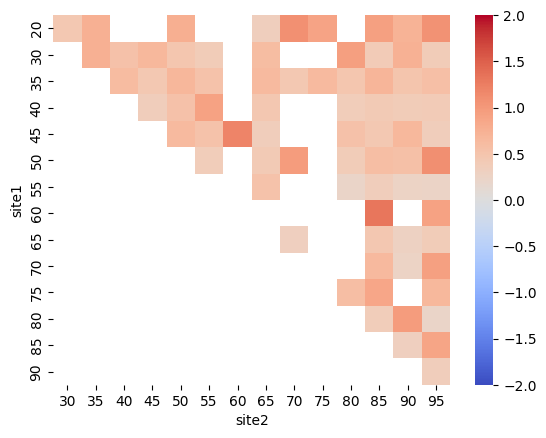

In [ ]:
results_df['scipy_fisher_odds_ratio_same_cf_log'] = np.log(results_df['scipy_fisher_odds_ratio_same_cf'])

sns.heatmap(
    results_df[(results_df.site1 != results_df.site2) & (results_df.scipy_fisher_pvalue_same_cf < 0.05)].pivot_table(index='site1', columns='site2', values='scipy_fisher_odds_ratio_same_cf_log'), vmin=-2, vmax=2, cmap="coolwarm",
)
#results_df[results_df.site1 != results_df.site2].sort_values(by='both_mutations_same_lineage', ascending=False).head(20)

/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


<Axes: xlabel='site2', ylabel='site1'>

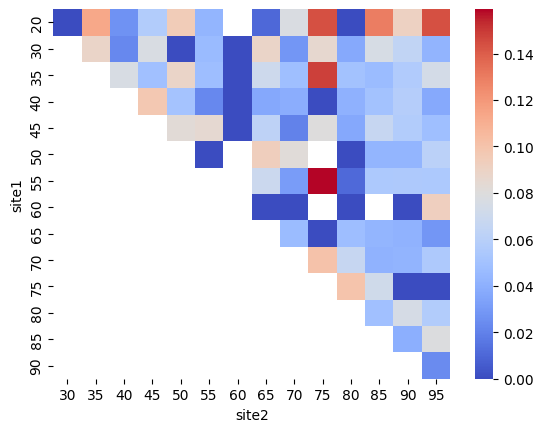

In [ ]:
results_df['scipy_fisher_odds_ratio_same_lineage_log'] = np.log(results_df['scipy_fisher_odds_ratio_same_lineage'])


sns.heatmap(
    results_df[(results_df.site1 != results_df.site2) & (results_df.scipy_fisher_pvalue_same_lineage < 0.05)].pivot_table(index='site1', columns='site2', values='scipy_fisher_odds_ratio_same_lineage'), cmap="coolwarm",
)
#results_df[results_df.site1 != results_df.site2].sort_values(by='both_mutations_same_lineage', ascending=False).head(20)

In [ ]:
result = calculate_mutation_association_lineage(
            site_sub_probs_df_germline, ancestral_pairs_df, 75, 55
        )

COMPREHENSIVE EPISTASIS ANALYSIS: Site 75 vs Site 55
Total families analyzed: 7,761

MUTATION PATTERNS:
  Neither mutation:                    6,579 (84.8%)
  Only site 75 mutation:              77 (1.0%)
  Only site 55 mutation:              1,074 (13.8%)
  Both mutations (multiple events):    11 (0.1%)
  Both mutations (same lineage):       2 (0.0%)
  Both mutations (different lineages): 18 (0.2%)
------------------------------------------------------------------------------------------
Total with both mutations (single): 20
  Same lineage proportion: 10.0%

STATISTICAL ANALYSES:

1. SCIPY TESTS:
   Fisher's exact test same clonal family: OR = 1.591, p = 0.076637
   Fisher's exact test same lineage: OR = 0.159, p = 0.001495

CONTINGENCY TABLE SAME CLONAL FAMILY:
                    Site 55 mut   Site 55 no mut
   Site 75 mut     20          77
   Site 75 no mut  1,074          6,579

CONTINGENCY TABLE SAME LINEAGE:
                    Site 55 mut   Site 55 no mut
   Site 75 mut     2

In [ ]:
result = calculate_mutation_association_lineage(
            site_sub_probs_df_germline, ancestral_pairs_df, 60, 20
        )

COMPREHENSIVE EPISTASIS ANALYSIS: Site 60 vs Site 20
Total families analyzed: 488

MUTATION PATTERNS:
  Neither mutation:                    347 (71.1%)
  Only site 60 mutation:              111 (22.7%)
  Only site 20 mutation:              12 (2.5%)
  Both mutations (multiple events):    10 (2.0%)
  Both mutations (same lineage):       1 (0.2%)
  Both mutations (different lineages): 7 (1.4%)
------------------------------------------------------------------------------------------
Total with both mutations (single): 8
  Same lineage proportion: 12.5%

STATISTICAL ANALYSES:

1. SCIPY TESTS:
   Fisher's exact test same clonal family: OR = 2.084, p = 0.117896
   Fisher's exact test same lineage: OR = 0.261, p = 0.317893

CONTINGENCY TABLE SAME CLONAL FAMILY:
                    Site 20 mut   Site 20 no mut
   Site 60 mut     8          111
   Site 60 no mut  12          347

CONTINGENCY TABLE SAME LINEAGE:
                    Site 20 mut   Site 20 no mut
   Site 60 mut     1          111

In [ ]:
np.log(2.692)

np.float64(0.9902844117824814)

COMPREHENSIVE EPISTASIS ANALYSIS: Site 20 vs Site 60
Total families analyzed: 488

MUTATION PATTERNS:
  Neither mutation:                    347 (71.1%)
  Only site 20 mutation:              12 (2.5%)
  Only site 60 mutation:              111 (22.7%)
  Both mutations (multiple events):    10 (2.0%)
  Both mutations (same lineage):       1 (0.2%)
  Both mutations (different lineages): 7 (1.4%)
------------------------------------------------------------------------------------------
Total with both mutations (single): 8
  Same lineage proportion: 12.5%

STATISTICAL ANALYSES:

1. SCIPY TESTS:
   Fisher's exact test same clonal family: OR = 2.084, p = 0.117896
   Fisher's exact test same lineage: OR = 0.261, p = 0.317893

CONTINGENCY TABLE SAME CLONAL FAMILY:
                    Site 60 mut   Site 60 no mut
   Site 20 mut     8          12
   Site 20 no mut  111          347

CONTINGENCY TABLE SAME LINEAGE:
                    Site 60 mut   Site 60 no mut
   Site 20 mut     1          12


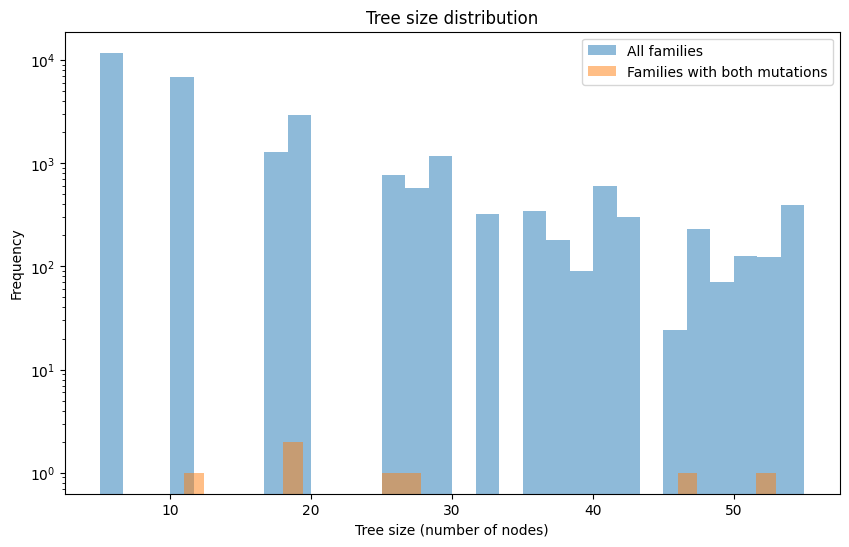

In [ ]:
#20 vs Site 60

result = calculate_mutation_association_lineage(
            site_sub_probs_df_germline, ancestral_pairs_df, 20, 60
        )



# Analysis by Branches


=== Site Coverage Analysis in Clonal Families ===
Total clonal families analyzed: 1000
Total sites analyzed: 140

Site-clonal_family combinations with partial coverage: 0/121814 (0.0%)

=== Per-Site Statistics ===
      total_clonal_families  clonal_families_with_partial_coverage  \
site                                                                 
1.0                    1000                                      0   
2.0                    1000                                      0   
3.0                    1000                                      0   
4.0                    1000                                      0   
5.0                    1000                                      0   
6.0                    1000                                      0   
7.0                    1000                                      0   
8.0                    1000                                      0   
9.0                    1000                                      0   
11.0            

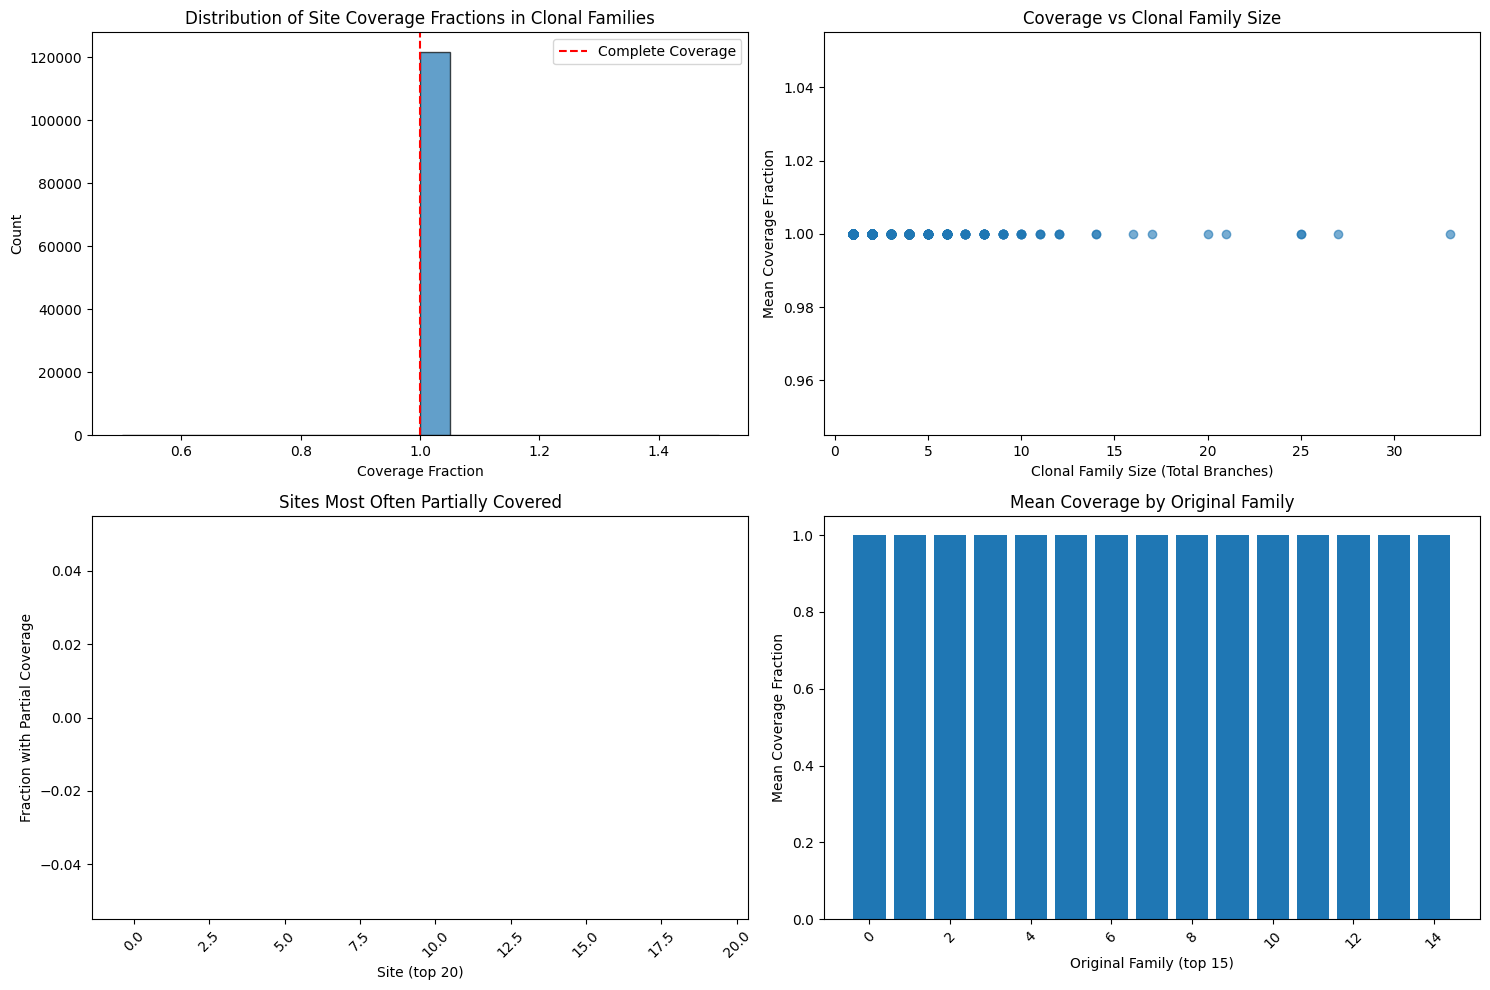

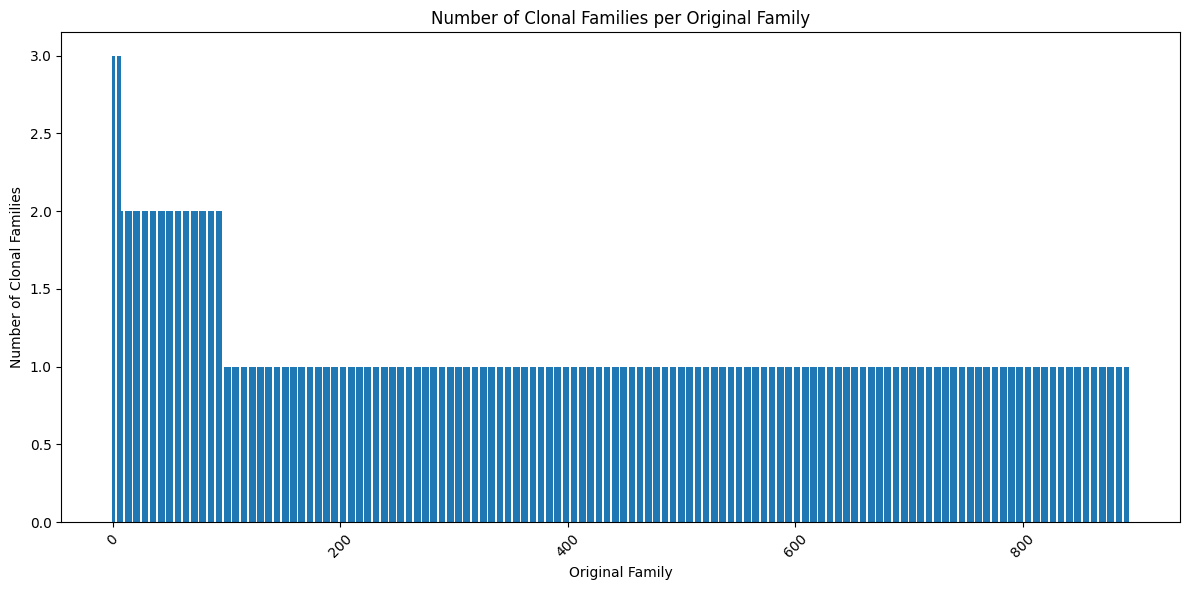

In [14]:
### can sites be present in only part of the clonal family tree? 
### From the results - no, coverage is the same across all branches of the clonal family tree.


def analyze_site_coverage_in_clonal_families(site_sub_probs_df_germline):
    """
    Analyze whether sites are present in only part of the clonal family tree.
    Clonal family is defined by combination of family and sample_id.
    Returns statistics about site coverage across clonal families and branches.
    """
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    # Get unique clonal families (family + sample_id combinations), sites, and branches
    clonal_families = site_sub_probs_df_germline[['family', 'sample_id']].drop_duplicates()
    sites = site_sub_probs_df_germline['site'].unique()
    
    results = []
    
    for _, clonal_family in clonal_families.iterrows():
        family = clonal_family['family']
        sample_id = clonal_family['sample_id']
        
        clonal_family_df = site_sub_probs_df_germline[
            (site_sub_probs_df_germline['family'] == family) & 
            (site_sub_probs_df_germline['sample_id'] == sample_id)
        ]
        
        total_branches = len(clonal_family_df['pcp_index'].unique())
        
        for site in sites:
            site_clonal_family_df = clonal_family_df[clonal_family_df['site'] == site]
            
            if len(site_clonal_family_df) > 0:
                site_branches = len(site_clonal_family_df['pcp_index'].unique())
                coverage_fraction = site_branches / total_branches
                
                results.append({
                    'family': family,
                    'sample_id': sample_id,
                    'clonal_family_id': f"{family}_{sample_id}",
                    'site': site,
                    'total_branches_in_clonal_family': total_branches,
                    'branches_with_site': site_branches,
                    'coverage_fraction': coverage_fraction,
                    'is_partial_coverage': coverage_fraction < 1.0
                })
    
    coverage_df = pd.DataFrame(results)
    
    # Overall statistics
    print("=== Site Coverage Analysis in Clonal Families ===")
    print(f"Total clonal families analyzed: {len(clonal_families)}")
    print(f"Total sites analyzed: {len(sites)}")
    print()
    
    # How many site-clonal_family combinations have partial coverage?
    partial_coverage = coverage_df[coverage_df['is_partial_coverage'] == True]
    total_combinations = len(coverage_df)
    partial_count = len(partial_coverage)
    
    print(f"Site-clonal_family combinations with partial coverage: {partial_count}/{total_combinations} ({partial_count/total_combinations*100:.1f}%)")
    print()
    
    # Site-level statistics
    site_stats = coverage_df.groupby('site').agg({
        'is_partial_coverage': ['count', 'sum', 'mean'],
        'coverage_fraction': ['mean', 'std', 'min', 'max']
    }).round(3)
    
    site_stats.columns = ['total_clonal_families', 'clonal_families_with_partial_coverage', 'fraction_clonal_families_partial', 
                         'mean_coverage', 'std_coverage', 'min_coverage', 'max_coverage']
    
    print("=== Per-Site Statistics ===")
    print(site_stats.head(10))
    print()
    
    # Clonal family-level statistics
    clonal_family_stats = coverage_df.groupby('clonal_family_id').agg({
        'is_partial_coverage': ['count', 'sum', 'mean'],
        'coverage_fraction': ['mean', 'std', 'min', 'max'],
        'total_branches_in_clonal_family': 'first',
        'family': 'first',
        'sample_id': 'first'
    }).round(3)
    
    clonal_family_stats.columns = ['total_sites', 'sites_with_partial_coverage', 'fraction_sites_partial',
                                  'mean_coverage', 'std_coverage', 'min_coverage', 'max_coverage', 
                                  'total_branches', 'family', 'sample_id']
    
    print("=== Per-Clonal-Family Statistics ===")
    print(clonal_family_stats.head(10))
    print()
    
    # Distribution of coverage fractions
    print("=== Coverage Fraction Distribution ===")
    coverage_bins = [0, 0.25, 0.5, 0.75, 1.0]
    coverage_labels = ['0-25%', '25-50%', '50-75%', '75-100%']
    coverage_df['coverage_bin'] = pd.cut(coverage_df['coverage_fraction'], 
                                        bins=coverage_bins, 
                                        labels=coverage_labels, 
                                        include_lowest=True)
    
    coverage_dist = coverage_df['coverage_bin'].value_counts().sort_index()
    print(coverage_dist)
    print()
    
    # Sites that are frequently missing from clonal families
    sites_often_partial = site_stats[site_stats['fraction_clonal_families_partial'] > 0.5].sort_values('fraction_clonal_families_partial', ascending=False)
    print("=== Sites with >50% partial coverage across clonal families ===")
    print(f"Number of such sites: {len(sites_often_partial)}")
    if len(sites_often_partial) > 0:
        print(sites_often_partial.head(10))
    print()
    
    # Clonal families with many partially covered sites
    clonal_families_many_partial = clonal_family_stats[clonal_family_stats['fraction_sites_partial'] > 0.5].sort_values('fraction_sites_partial', ascending=False)
    print("=== Clonal families with >50% sites having partial coverage ===")
    print(f"Number of such clonal families: {len(clonal_families_many_partial)}")
    if len(clonal_families_many_partial) > 0:
        print(clonal_families_many_partial.head(10))
    print()
    
    # Analysis by original family
    print("=== Analysis by Original Family ===")
    family_summary = coverage_df.groupby('family').agg({
        'clonal_family_id': 'nunique',
        'is_partial_coverage': 'mean',
        'coverage_fraction': 'mean',
        'total_branches_in_clonal_family': 'mean'
    }).round(3)
    family_summary.columns = ['num_clonal_families', 'fraction_partial_coverage', 'mean_coverage_fraction', 'mean_branches_per_clonal_family']
    print(family_summary.head(10))
    
    return coverage_df, site_stats, clonal_family_stats

def plot_clonal_family_coverage_analysis(coverage_df):
    """
    Create visualizations for clonal family site coverage analysis.
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Coverage fraction distribution
    axes[0,0].hist(coverage_df['coverage_fraction'], bins=20, alpha=0.7, edgecolor='black')
    axes[0,0].set_xlabel('Coverage Fraction')
    axes[0,0].set_ylabel('Count')
    axes[0,0].set_title('Distribution of Site Coverage Fractions in Clonal Families')
    axes[0,0].axvline(x=1.0, color='red', linestyle='--', label='Complete Coverage')
    axes[0,0].legend()
    
    # Coverage by clonal family size
    clonal_family_sizes = coverage_df.groupby('clonal_family_id')['total_branches_in_clonal_family'].first()
    coverage_by_size = coverage_df.groupby('clonal_family_id')['coverage_fraction'].mean()
    
    axes[0,1].scatter(clonal_family_sizes, coverage_by_size, alpha=0.6)
    axes[0,1].set_xlabel('Clonal Family Size (Total Branches)')
    axes[0,1].set_ylabel('Mean Coverage Fraction')
    axes[0,1].set_title('Coverage vs Clonal Family Size')
    
    # Sites with partial coverage
    site_partial_rates = coverage_df.groupby('site')['is_partial_coverage'].mean().sort_values(ascending=False)
    top_partial_sites = site_partial_rates.head(20)
    
    axes[1,0].bar(range(len(top_partial_sites)), top_partial_sites.values)
    axes[1,0].set_xlabel('Site (top 20)')
    axes[1,0].set_ylabel('Fraction with Partial Coverage')
    axes[1,0].set_title('Sites Most Often Partially Covered')
    axes[1,0].tick_params(axis='x', rotation=45)
    
    # Coverage fraction by original family
    family_coverage = coverage_df.groupby('family')['coverage_fraction'].mean().sort_values(ascending=False)
    top_families = family_coverage.head(15)
    
    axes[1,1].bar(range(len(top_families)), top_families.values)
    axes[1,1].set_xlabel('Original Family (top 15)')
    axes[1,1].set_ylabel('Mean Coverage Fraction')
    axes[1,1].set_title('Mean Coverage by Original Family')
    axes[1,1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Additional plot: Coverage patterns within original families
    fig, ax = plt.subplots(1, 1, figsize=(12, 6))
    
    # Show distribution of clonal families per original family
    clonal_families_per_family = coverage_df.groupby('family')['clonal_family_id'].nunique().sort_values(ascending=False)
    
    ax.bar(range(len(clonal_families_per_family)), clonal_families_per_family.values)
    ax.set_xlabel('Original Family')
    ax.set_ylabel('Number of Clonal Families')
    ax.set_title('Number of Clonal Families per Original Family')
    ax.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

# Run the analysis
coverage_df, site_stats, clonal_family_stats = analyze_site_coverage_in_clonal_families(pd.merge(site_sub_probs_df_germline, site_sub_probs_df_germline[['sample_id', 'family']].drop_duplicates().head(1000), on=['sample_id', 'family'], how='inner'))
plot_clonal_family_coverage_analysis(coverage_df)

In [54]:
def calculate_mutation_association_branches(site_sub_probs_df_germline, site1, site2):
    '''
    Mutations are considered any change in aa from the germline.
    '''
    # filter only rows with the two relevant sites
    cur_df = site_sub_probs_df_germline[(site_sub_probs_df_germline['site'].isin([site1, site2]))].copy()
    # filter only rows where germline identity is known
    cur_df = cur_df[(cur_df['germline_amino_acid'].notna())]
    # merge data for both sites per pcp
    merged_df = pd.merge(cur_df[cur_df.site == site1], cur_df[cur_df.site == site2], on=['sample_id', 'family', 'pcp_index'], how='inner', suffixes=('_1', '_2'))
    # only keep pcps that have measurements for both sites
    merged_df.dropna(subset=['site_1', 'site_2'], inplace=True)
    # remove pcps/branches that already have mutation at site2, and thus cannot acquire it
    merged_df = merged_df[merged_df.is_germline_aa_2 == True]


    total_counts = len(merged_df[['family', 'sample_id', 'pcp_index']].drop_duplicates())

    # create contingency table
    #                        Acquires B     Doesn't acquire B
    # Has A mutation         n11            n12
    # No A mutation          n21            n22

    # has A mutation
    has_site1_mutation = merged_df[(merged_df.is_germline_aa_1 == False)]
    n11_df = has_site1_mutation[(has_site1_mutation['mutation_2'] == True)]
    n11 = len(n11_df)
    n12_df = has_site1_mutation[(has_site1_mutation['mutation_2'] == False)]
    n12 = len(n12_df)

    assert n11 + n12 == len(has_site1_mutation), f"Mismatch in counts for site {site1} mutations: {n11} + {n12} != {len(has_site1_mutation)}"

    # no A mutation
    no_site1_mutation = merged_df[(merged_df.is_germline_aa_1 == True)]
    n21_df = no_site1_mutation[(no_site1_mutation['mutation_2'] == True)]
    n21 = len(n21_df)
    n22_df = no_site1_mutation[(no_site1_mutation['mutation_2'] == False)]
    n22 = len(n22_df)

    assert n21 + n22 == len(no_site1_mutation), f"Mismatch in counts for site {site1} no mutations: {n21} + {n22} != {len(no_site1_mutation)}"

    assert n11 + n12 + n21 + n22 == total_counts, f"Mismatch in total counts: {n11} + {n12} + {n21} + {n22} != {total_counts}"

    # Create contingency table
    contingency_table = np.array([[n11, n12], [n21, n22]])
    print(contingency_table)
    # Calculate Fisher's exact test
    odds_ratio, fisher_pvalue = fisher_exact(contingency_table)
    log_odds_ratio = np.log(odds_ratio + 1e-10)

    # Calculate Chi-squared test
    chi2, chi2_pvalue, _, _ = chi2_contingency(contingency_table)

    # create dictioncary with results
    results = {
        'site1': site1,
        'site2': site2,
        'total_counts': total_counts,
        'n11': n11,
        'n12': n12,
        'n21': n21,
        'n22': n22,
        'fisher_odds_ratio': odds_ratio,
        'fisher_pvalue': fisher_pvalue,
        'log_odds_ratio': log_odds_ratio,
        'chi2_statistic': chi2,
        'chi2_pvalue': chi2_pvalue
    }
    return results





def calculate_mutation_association_branch_length(site_sub_probs_df_germline, site1, site2):
    '''
    Mutations are considered any change in aa from the germline.
    '''
    # filter only rows with the two relevant sites
    cur_df = site_sub_probs_df_germline[(site_sub_probs_df_germline['site'].isin([site1, site2]))].copy()
    # filter only rows where germline identity is known
    cur_df = cur_df[(cur_df['germline_amino_acid'].notna())]
    # merge data for both sites per pcp
    merged_df = pd.merge(cur_df[cur_df.site == site1], cur_df[cur_df.site == site2], on=['sample_id', 'family', 'pcp_index'], how='inner', suffixes=('_1', '_2'))
    # only keep pcps that have measurements for both sites
    merged_df.dropna(subset=['site_1', 'site_2'], inplace=True)
    # remove pcps/branches that already have mutation at site2, and thus cannot acquire it
    merged_df = merged_df[merged_df.is_germline_aa_2 == True]

    total_counts = len(merged_df[['family', 'sample_id', 'pcp_index']].drop_duplicates())
    total_branch_length = merged_df['branch_length_1'].sum() if not merged_df.empty else 0
    total_mutations_acquired = len(merged_df[(merged_df['mutation_2'] == True)])

    # Calculations:
    #                        total branch length     number of B mutation acquired  |
    # Has A mutation                                                                |  mutations per total length
    # No A mutation                                                                 |  mutations per total length

    # has A mutation
    has_site1_mutation = merged_df[(merged_df.is_germline_aa_1 == False)]
    length_has_site1_mutation = has_site1_mutation['branch_length_1'].sum() if not has_site1_mutation.empty else 0
    has_site1_mutation_site2_acquired = len(has_site1_mutation[(has_site1_mutation['mutation_2'] == True)])

    # no A mutation
    no_site1_mutation = merged_df[(merged_df.is_germline_aa_1 == True)]
    length_no_site1_mutation = no_site1_mutation['branch_length_1'].sum() if not no_site1_mutation.empty else 0
    no_site1_mutation_site2_acquired = len(no_site1_mutation[(no_site1_mutation['mutation_2'] == True)])

    assert total_counts == len(has_site1_mutation) + len(no_site1_mutation), \
        f"Mismatch in counts: {len(has_site1_mutation)} + {len(no_site1_mutation)} != {total_counts}"
    # Replace your assertion with:
    assert np.isclose(length_has_site1_mutation + length_no_site1_mutation, total_branch_length, atol=1e-10), \
    f"Mismatch in branch lengths: {length_has_site1_mutation} + {length_no_site1_mutation} != {total_branch_length}"    
    assert has_site1_mutation_site2_acquired + no_site1_mutation_site2_acquired == total_mutations_acquired, f"Mismatch in mutations acquired: {has_site1_mutation_site2_acquired} + {no_site1_mutation_site2_acquired} != {total_mutations_acquired}"


    # Calculate mutation rates
    rate_has_site1 = has_site1_mutation_site2_acquired / length_has_site1_mutation if length_has_site1_mutation > 0 else 0
    rate_no_site1 = no_site1_mutation_site2_acquired / length_no_site1_mutation if length_no_site1_mutation > 0 else 0
    
    # Calculate rate ratio
    rate_ratio = rate_has_site1 / rate_no_site1 if rate_no_site1 > 0 else np.inf
    log_rate_ratio = np.log(rate_ratio) if rate_ratio > 0 and np.isfinite(rate_ratio) else np.nan

    # Statsmodels Poisson test for comparing two independent rates
    poisson_result = None
    poisson_pvalue = np.nan
    poisson_statistic = np.nan
    
    try:
        # Test is valid as long as we have some exposure in both groups
        if length_has_site1_mutation > 0 and length_no_site1_mutation > 0:
            poisson_result = test_poisson_2indep(
                count1=has_site1_mutation_site2_acquired,
                exposure1=length_has_site1_mutation,
                count2=no_site1_mutation_site2_acquired,
                exposure2=length_no_site1_mutation,)
            poisson_statistic = poisson_result.statistic
            poisson_pvalue = poisson_result.pvalue
    except Exception as e:
        print(f"Poisson test failed for sites {site1}-{site2}: {e}")
        poisson_pvalue = np.nan
        poisson_statistic = np.nan

    # Create results dictionary
    results = {
        'site1': site1,
        'site2': site2,
        'total_counts': total_counts,
        'total_branch_length': total_branch_length,
        'total_mutations_acquired': total_mutations_acquired,
        
        # Has site1 mutation group
        'has_site1_mutation_count': len(has_site1_mutation),
        'has_site1_mutation_branch_length': length_has_site1_mutation,
        'has_site1_mutation_site2_acquired': has_site1_mutation_site2_acquired,
        'has_site1_mutation_rate': rate_has_site1,
        
        # No site1 mutation group
        'no_site1_mutation_count': len(no_site1_mutation),
        'no_site1_mutation_branch_length': length_no_site1_mutation,
        'no_site1_mutation_site2_acquired': no_site1_mutation_site2_acquired,
        'no_site1_mutation_rate': rate_no_site1,
        
        # Rate comparison
        'rate_ratio': rate_ratio,
        'log_rate_ratio': log_rate_ratio,
        
        # Statistical test results
        'poisson_statistic': poisson_statistic,
        'poisson_pvalue': poisson_pvalue,
        
        # Quality metrics
        'valid_test': length_has_site1_mutation > 0 and length_no_site1_mutation > 0
    }
    
    return results


In [55]:
calculate_mutation_association_branch_length(
    site_sub_probs_df_germline, 20, 30)

{'site1': 20,
 'site2': 30,
 'total_counts': 19921,
 'total_branch_length': np.float64(661.9928036409),
 'total_mutations_acquired': 880,
 'has_site1_mutation_count': 831,
 'has_site1_mutation_branch_length': np.float64(18.0559481654),
 'has_site1_mutation_site2_acquired': 12,
 'has_site1_mutation_rate': np.float64(0.6646009331703329),
 'no_site1_mutation_count': 19090,
 'no_site1_mutation_branch_length': np.float64(643.9368554754999),
 'no_site1_mutation_site2_acquired': 868,
 'no_site1_mutation_rate': np.float64(1.347958254942631),
 'rate_ratio': np.float64(0.49304266711035366),
 'log_rate_ratio': np.float64(-0.7071595628215377),
 'poisson_statistic': np.float64(-2.4839240177361597),
 'poisson_pvalue': np.float64(0.01299435309520192),
 'valid_test': np.True_}

In [28]:
calculate_mutation_association_branches(site_sub_probs_df_germline, 50, 36)
calculate_mutation_association_branch_length(site_sub_probs_df_germline, 50, 36)


[[  25  252]
 [2492 8895]]


{'site1': 50,
 'site2': 36,
 'total_counts': 11664,
 'total_branch_length': np.float64(433.5312098761),
 'total_mutations_acquired': 2517,
 'has_site1_mutation_count': 277,
 'has_site1_mutation_branch_length': np.float64(7.271639317),
 'has_site1_mutation_site2_acquired': 25,
 'has_site1_mutation_rate': np.float64(3.4380143060112673),
 'no_site1_mutation_count': 11387,
 'no_site1_mutation_branch_length': np.float64(426.2595705591),
 'no_site1_mutation_site2_acquired': 2492,
 'no_site1_mutation_rate': np.float64(5.846203046494388),
 'rate_ratio': np.float64(0.5880764452874819),
 'log_rate_ratio': np.float64(-0.5308983305416306),
 'poisson_statistic': np.float64(-2.672404226026913),
 'poisson_pvalue': np.float64(0.007530986872352617),
 'valid_test': np.True_}

AssertionError: Mismatch in branch lengths: 18.0559481654 + 643.9368554754999 != 661.9928036409

In [63]:
# To create a large dataframe from multiple tests:
all_results = []
sites = sorted([10,20,30,40,50,60,70,80,90, 35, 45, 55, 65, 75, 85, 95])
combinations = list(itertools.permutations(sites, 2))
for site1, site2 in tqdm.tqdm(combinations):
    print(f"Processing sites {site1} and {site2}")
    result = calculate_mutation_association_branches(
    site_sub_probs_df_germline, site1, site2
)
    all_results.append(result)


results_df = pd.DataFrame(all_results)


  0%|          | 0/240 [00:00<?, ?it/s]/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/scipy/stats/contingency.py:135: RuntimeWarning: invalid value encountered in divide
  expected = reduce(np.multiply, margsums) / observed.sum() ** (d - 1)
  0%|          | 1/240 [00:00<00:42,  5.56it/s]/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/scipy/stats/contingency.py:135: RuntimeWarning: invalid value encountered in divide
  expected = reduce(np.multiply, margsums) / observed.sum() ** (d - 1)
  1%|          | 2/240 [00:00<00:40,  5.84it/s]

Processing sites 10 and 20
[[0 0]
 [0 0]]
Processing sites 10 and 30
[[0 0]
 [0 0]]
Processing sites 10 and 35


/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/scipy/stats/contingency.py:135: RuntimeWarning: invalid value encountered in divide
  expected = reduce(np.multiply, margsums) / observed.sum() ** (d - 1)
  1%|▏         | 3/240 [00:00<00:40,  5.85it/s]/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/scipy/stats/contingency.py:135: RuntimeWarning: invalid value encountered in divide
  expected = reduce(np.multiply, margsums) / observed.sum() ** (d - 1)
  2%|▏         | 4/240 [00:00<00:40,  5.85it/s]

[[0 0]
 [0 0]]
Processing sites 10 and 40
[[0 0]
 [0 0]]
Processing sites 10 and 45


/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/scipy/stats/contingency.py:135: RuntimeWarning: invalid value encountered in divide
  expected = reduce(np.multiply, margsums) / observed.sum() ** (d - 1)
  2%|▏         | 5/240 [00:00<00:40,  5.83it/s]/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/scipy/stats/contingency.py:135: RuntimeWarning: invalid value encountered in divide
  expected = reduce(np.multiply, margsums) / observed.sum() ** (d - 1)
  2%|▎         | 6/240 [00:01<00:40,  5.78it/s]

...

100%|█████████▉| 239/240 [00:46<00:00,  4.95it/s]

Processing sites 95 and 85
[[  170  1421]
 [ 1441 14995]]


100%|██████████| 240/240 [00:46<00:00,  4.98it/s]

Processing sites 95 and 90
[[  113  2070]
 [ 1480 14824]]


100%|██████████| 240/240 [00:46<00:00,  5.17it/s]


<Axes: xlabel='site2', ylabel='site1'>

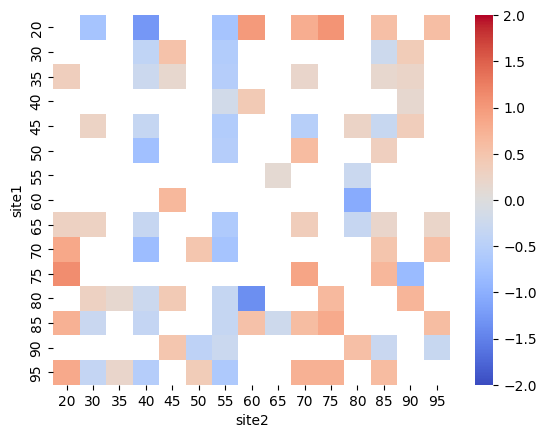

In [57]:
sns.heatmap(results_df[(results_df.poisson_pvalue < 0.05)].pivot_table(index='site1', columns='site2', values='log_rate_ratio'), vmin=-2, vmax=2, cmap="coolwarm",)



In [62]:
results_df[(results_df.site1 == 60) & (results_df.site2 == 75)]

,site1,site2,total_counts,total_branch_length,total_mutations_acquired,has_site1_mutation_count,has_site1_mutation_branch_length,has_site1_mutation_site2_acquired,has_site1_mutation_rate,no_site1_mutation_count,no_site1_mutation_branch_length,no_site1_mutation_site2_acquired,no_site1_mutation_rate,rate_ratio,log_rate_ratio,poisson_statistic,poisson_pvalue,valid_test
130,60,75,1388,39.431223,3,586,14.943723,2,0.133835,802,24.4875,1,0.040837,3.277296,1.187019,1.027108,0.30437,True


In [36]:
len(combinations)

240

<Axes: xlabel='site2', ylabel='site1'>

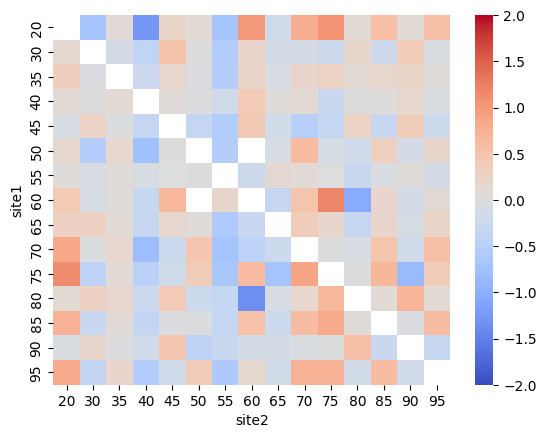

In [58]:
sns.heatmap(results_df.pivot_table(index='site1', columns='site2', values='log_rate_ratio'), vmin=-2, vmax=2, cmap="coolwarm",)


In [25]:
## I ran all of this with this script and here's the plot:
# /home/nharel/re/dasm-epistasis-experiments/immuno_dominant_shm.ipynb
results_df = pd.read_csv('/home/nharel/re/dnsm-experiments-1/dnsm-train/_ignore/test_output/dnsm_1m-v1jaffe+v1tang-joint-ON-v1rodriguez-mutation_association_by_branches.csv')

<Axes: xlabel='site2', ylabel='site1'>

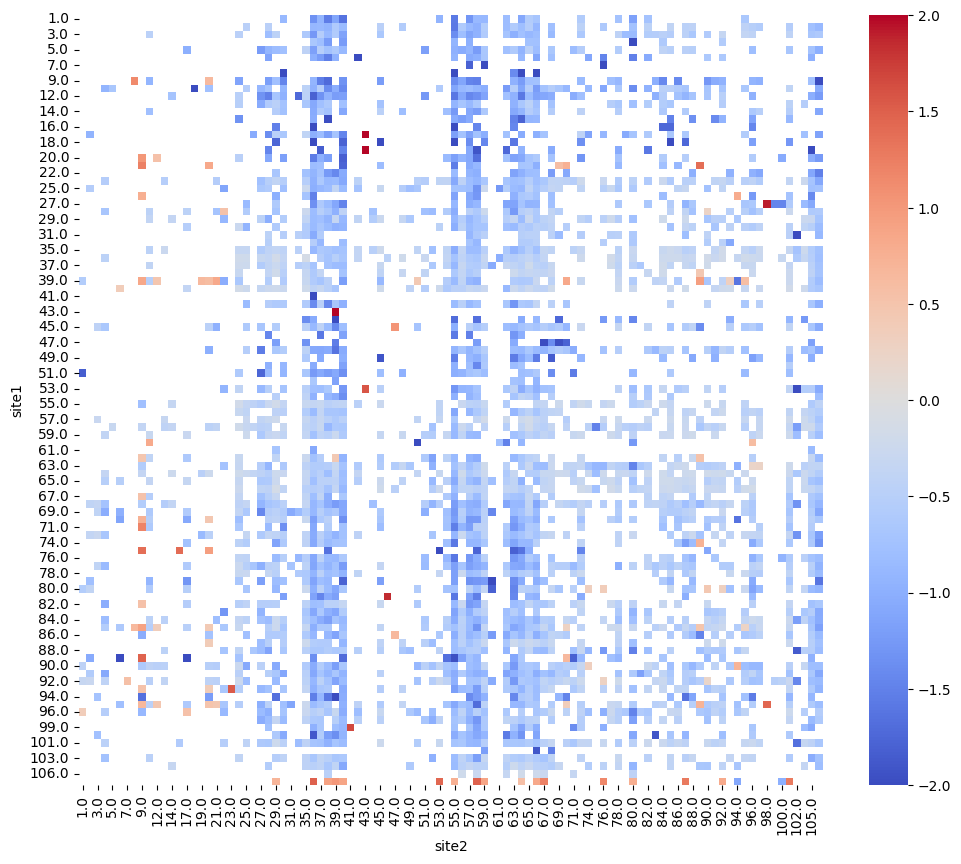

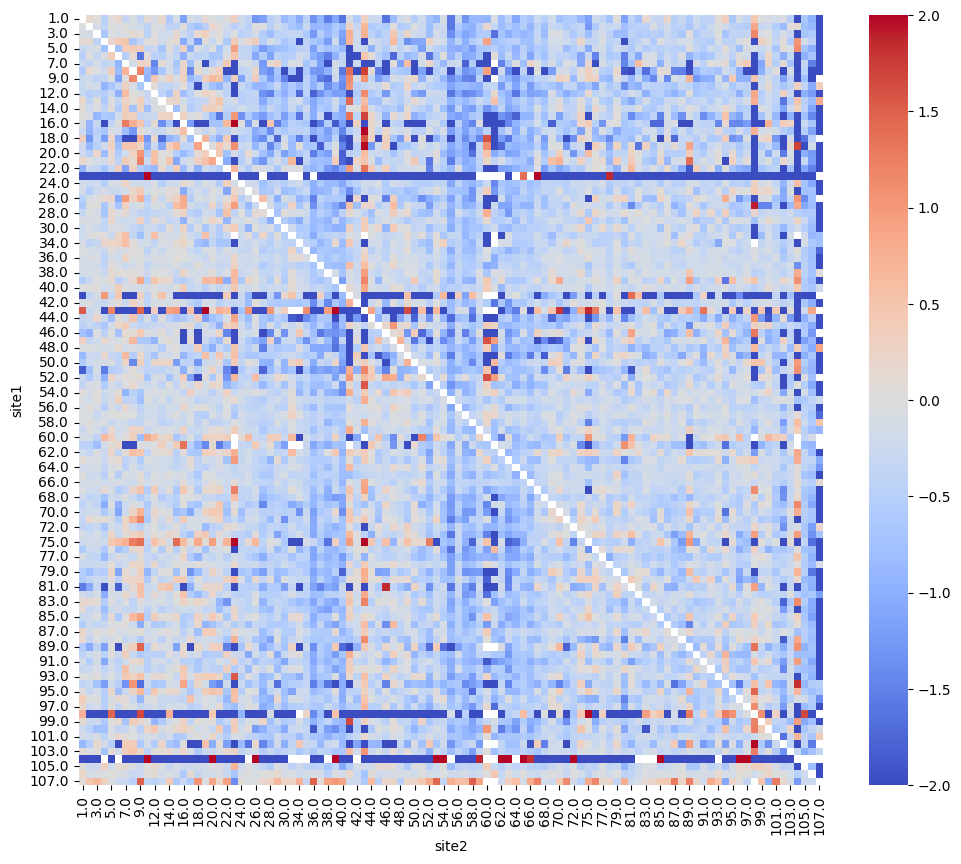

In [ ]:
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(results_df[(results_df.fisher_pvalue < 0.005)].pivot_table(index='site1', columns='site2', values='log_odds_ratio'), vmin=-2, vmax=2, cmap="coolwarm", ax=ax)
fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(results_df.pivot_table(index='site1', columns='site2', values='log_odds_ratio'), vmin=-2, vmax=2, cmap="coolwarm", ax=ax)


In [ ]:
calculate_mutation_association_branches(site_sub_probs_df_germline, 23, 75)




[[    0     3]
 [  106 21398]]


{'site1': 23,
 'site2': 75,
 'total_counts': 21507,
 'n11': 0,
 'n12': 3,
 'n21': 106,
 'n22': 21398,
 'fisher_odds_ratio': np.float64(0.0),
 'fisher_pvalue': 1.0,
 'log_odds_ratio': np.float64(-23.025850929940457),
 'chi2_statistic': np.float64(0.0),
 'chi2_pvalue': np.float64(1.0)}

In [ ]:
calculate_mutation_association_branches(site_sub_probs_df_germline, 75, 23)


[[    2   223]
 [   23 21481]]


{'site1': 75,
 'site2': 23,
 'total_counts': 21729,
 'n11': 2,
 'n12': 223,
 'n21': 23,
 'n22': 21481,
 'fisher_odds_ratio': np.float64(8.376291674790407),
 'fisher_pvalue': np.float64(0.02738685302146588),
 'log_odds_ratio': np.float64(2.125405295656592),
 'chi2_statistic': np.float64(6.019657250687312),
 'chi2_pvalue': np.float64(0.014147394017741387)}

In [ ]:
calculate_mutation_association_branches(site_sub_probs_df_germline, 60, 81)


[[  9 569]
 [  6 803]]


{'site1': 60,
 'site2': 81,
 'total_counts': 1387,
 'n11': 9,
 'n12': 569,
 'n21': 6,
 'n22': 803,
 'fisher_odds_ratio': np.float64(2.116871704745167),
 'fisher_pvalue': np.float64(0.18885302503228918),
 'log_odds_ratio': np.float64(0.7499393879758346),
 'chi2_statistic': np.float64(1.4025705333342944),
 'chi2_pvalue': np.float64(0.2362936533425989)}

In [ ]:
calculate_mutation_association_branches(site_sub_probs_df_germline, 55, 37)


[[  306  3681]
 [ 1295 11456]]


{'site1': 55,
 'site2': 37,
 'total_counts': 16738,
 'n11': 306,
 'n12': 3681,
 'n21': 1295,
 'n22': 11456,
 'fisher_odds_ratio': np.float64(0.7353919060520527),
 'fisher_pvalue': np.float64(2.2979862369979246e-06),
 'log_odds_ratio': np.float64(-0.3073517162238697),
 'chi2_statistic': np.float64(21.329326837660336),
 'chi2_pvalue': np.float64(3.867691136666047e-06)}

In [ ]:
pd.merge(results_df, results_df.rename(columns={'site1':'site2', 'site2':'site1'}), on=['site1', 'site2'],, suffixes=('', '_rev'))[['site1', 'site2', 'log_odds_ratio', 'fisher_pvalue']].drop_duplicates().sort_values(by='log_odds_ratio', ascending=False)

,site1,site2,total_counts,n11,n12,n21,n22,fisher_odds_ratio,fisher_pvalue,log_odds_ratio,chi2_statistic,chi2_pvalue
0,1.0,2.0,20357,22,474,762,19099,1.163322,0.477522,0.151280,0.320850,0.571097
1,1.0,3.0,19958,31,481,1112,18334,1.062598,0.700318,0.060717,0.051489,0.820493
2,1.0,4.0,21152,7,623,366,20156,0.618776,0.278993,-0.480012,1.230484,0.267313
3,1.0,5.0,20618,20,557,680,19361,1.022336,0.906946,0.022090,0.000000,1.000000
4,1.0,6.0,21205,11,591,310,20293,1.218400,0.495779,0.197538,0.220596,0.638586
...,...,...,...,...,...,...,...,...,...,...,...,...
16365,128.0,123.0,0,0,0,0,0,NaN,1.000000,NaN,NaN,NaN
16366,128.0,124.0,0,0,0,0,0,NaN,1.000000,NaN,NaN,NaN
16367,128.0,125.0,0,0,0,0,0,NaN,1.000000,NaN,NaN,NaN
16368,128.0,126.0,0,0,0,0,0,NaN,1.000000,NaN,NaN,NaN


In [2]:
results_df = pd.read_csv('/home/nharel/re/dnsm-experiments-1/dnsm-train/_ignore/test_output/dnsm_1m-v1jaffe+v1tang-joint-ON-v1rodriguez-mutation_association_by_branch_length.csv')
results_df

,site1,site2,total_counts,total_branch_length,total_mutations_acquired,has_site1_mutation_count,has_site1_mutation_branch_length,has_site1_mutation_site2_acquired,has_site1_mutation_rate,no_site1_mutation_count,no_site1_mutation_branch_length,no_site1_mutation_site2_acquired,no_site1_mutation_rate,rate_ratio,log_rate_ratio,poisson_statistic,poisson_pvalue,valid_test
0,1.0,2.0,20357,673.562061,784,496,10.924770,22,2.013772,19861,662.637292,762,1.149950,1.751182,0.560291,2.624885,0.008668,True
1,1.0,3.0,19958,666.305260,1143,512,10.687363,31,2.900622,19446,655.617897,1112,1.696110,1.710162,0.536588,2.982282,0.002861,True
2,1.0,4.0,21152,689.873428,373,630,13.732358,7,0.509745,20522,676.141070,366,0.541307,0.941693,-0.060076,-0.157472,0.874873,True
3,1.0,5.0,20618,680.817441,700,577,12.791484,20,1.563540,20041,668.025958,680,1.017925,1.536008,0.429187,1.906317,0.056609,True
4,1.0,6.0,21205,692.581460,321,602,12.976575,11,0.847681,20603,679.604885,310,0.456147,1.858350,0.619689,2.052226,0.040148,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20587,128.0,123.0,0,0.000000,0,0,0.000000,0,0.000000,0,0.000000,0,0.000000,inf,NaN,NaN,NaN,False
20588,128.0,124.0,0,0.000000,0,0,0.000000,0,0.000000,0,0.000000,0,0.000000,inf,NaN,NaN,NaN,False
20589,128.0,125.0,0,0.000000,0,0,0.000000,0,0.000000,0,0.000000,0,0.000000,inf,NaN,NaN,NaN,False
20590,128.0,126.0,0,0.000000,0,0,0.000000,0,0.000000,0,0.000000,0,0.000000,inf,NaN,NaN,NaN,False


<Axes: xlabel='site2', ylabel='site1'>

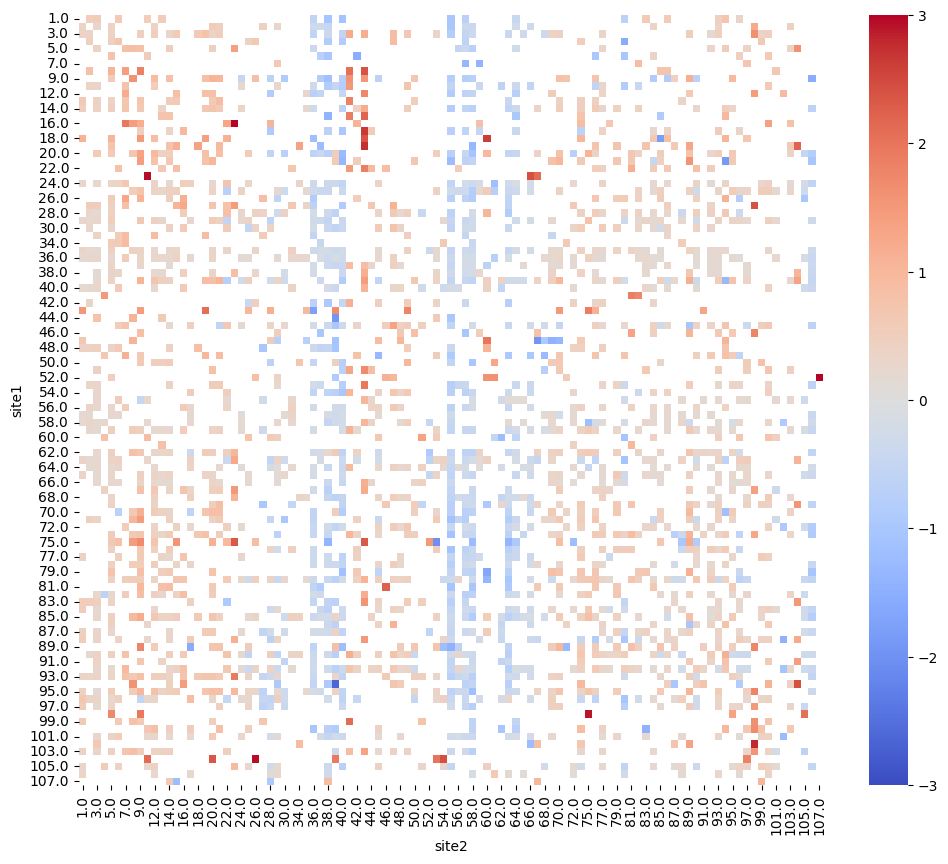

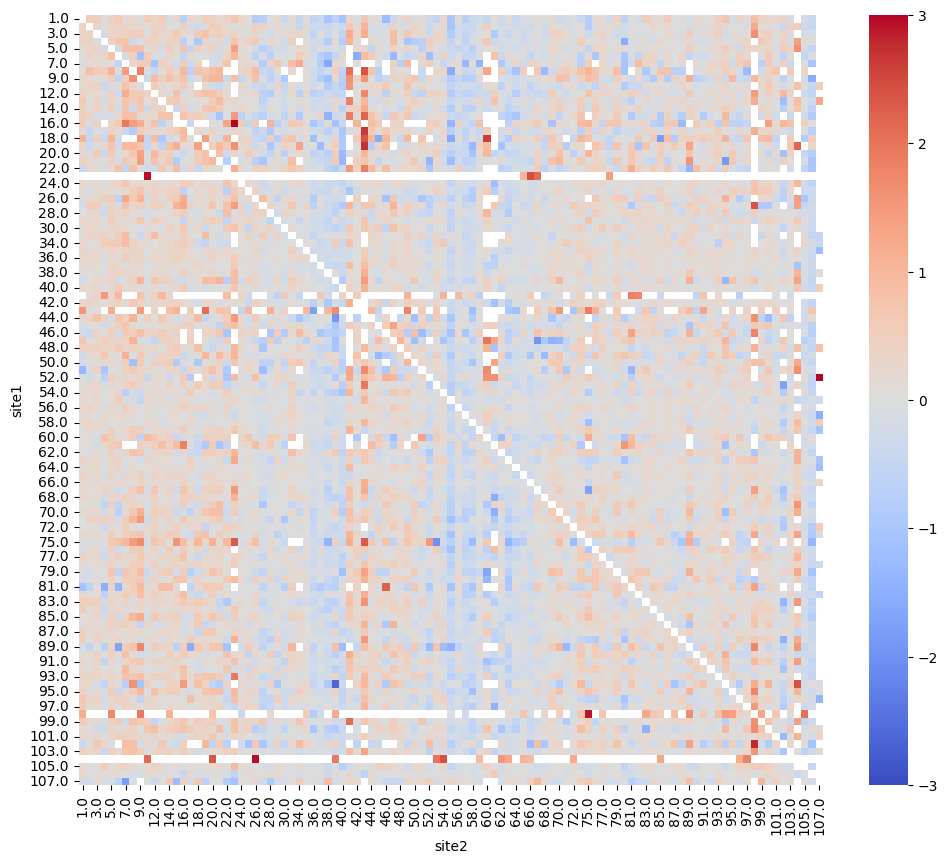

In [ ]:
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(results_df[(results_df.poisson_pvalue < 0.05)].pivot_table(index='site1', columns='site2', values='log_rate_ratio'), vmin=-3, vmax=3, cmap="coolwarm", ax=ax)
fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(results_df.pivot_table(index='site1', columns='site2', values='log_rate_ratio'), vmin=-3, vmax=3, cmap="coolwarm", ax=ax)




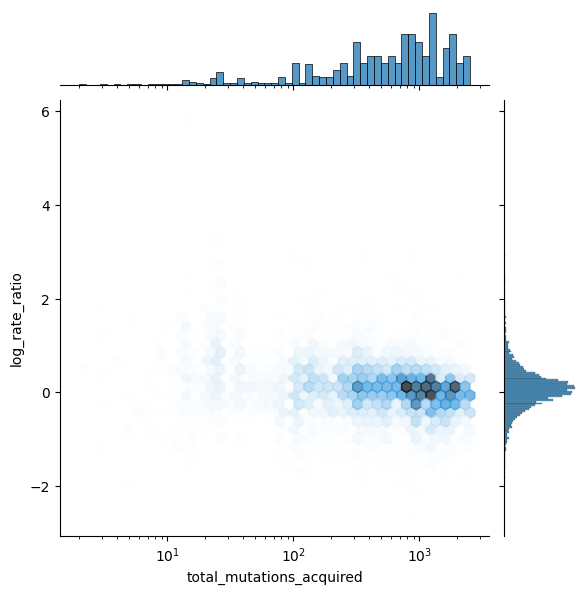

In [98]:
sns.jointplot(data=results_df, x='total_mutations_acquired', y='log_rate_ratio', alpha=0.7, kind='hex', xscale='log')


<Axes: xlabel='total_branch_length', ylabel='log_rate_ratio'>

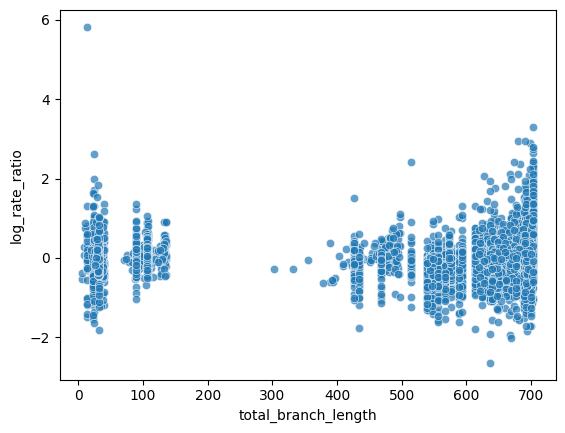

In [23]:
sns.scatterplot(data=results_df, x='total_branch_length', y='log_rate_ratio', alpha=0.7)

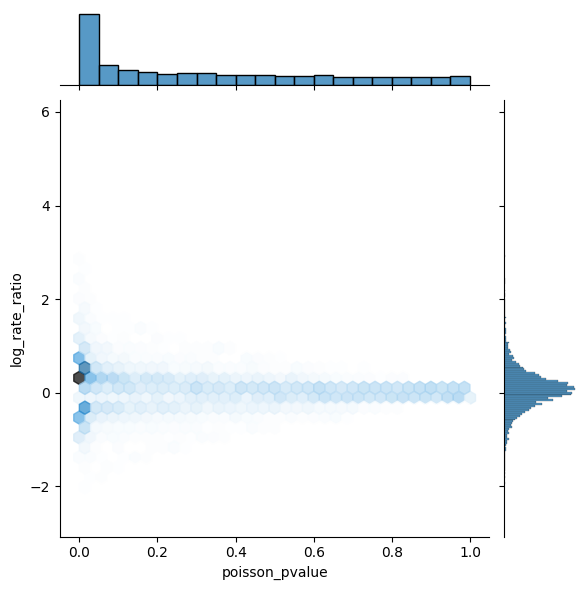

In [13]:
sns.jointplot(data=results_df, x='poisson_pvalue', y='log_rate_ratio', alpha=0.7, kind='hex')


<Axes: xlabel='site1', ylabel='log_rate_ratio'>

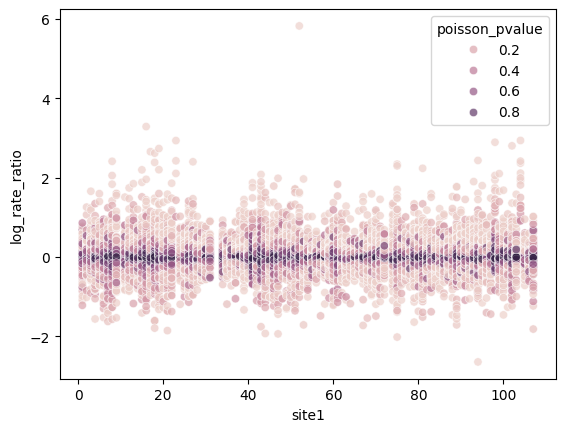

In [ ]:
sns.scatterplot(data=results_df, x='site1', y='log_rate_ratio', alpha=0.7, hue='poisson_pvalue')


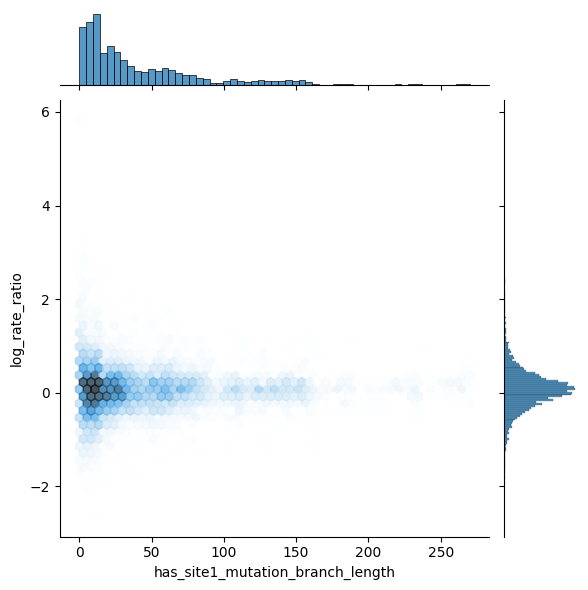

In [96]:
sns.jointplot(data=results_df, x='has_site1_mutation_branch_length', y='log_rate_ratio', alpha=0.7, kind='hex')


<Axes: xlabel='site1', ylabel='log_rate_ratio'>

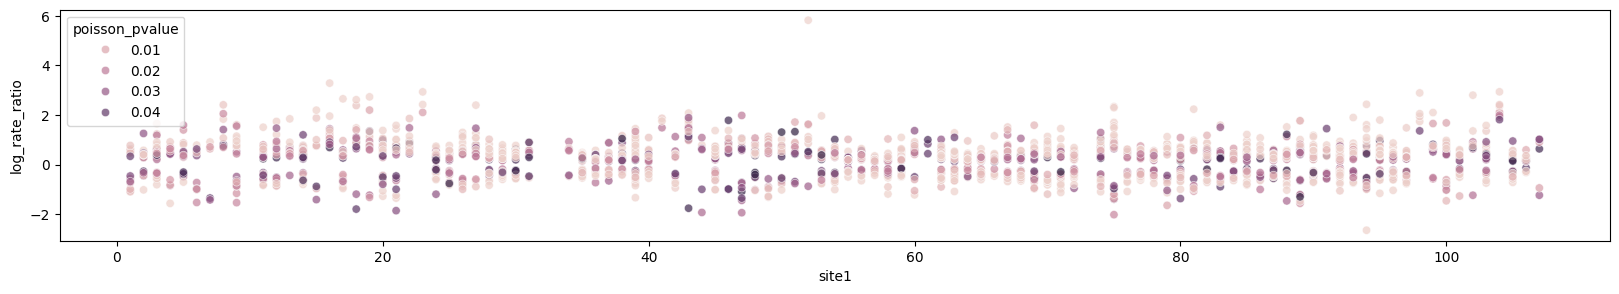

In [22]:
fig, ax = plt.subplots(figsize=(20, 3))
sns.scatterplot(data=results_df[results_df.poisson_pvalue < 0.05], x='site1', y='log_rate_ratio', alpha=0.7, hue='poisson_pvalue', ax=ax)


<Axes: >

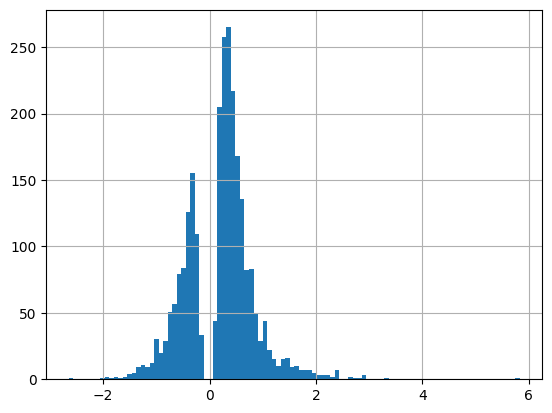

In [29]:
results_df[results_df.poisson_pvalue < 0.05].log_rate_ratio.hist(bins=100)

In [32]:
results_df[(results_df.poisson_pvalue < 0.05) & (results_df.has_site1_mutation_branch_length > 50)].sort_values(by='log_rate_ratio', ascending=False).head(20)

,site1,site2,total_counts,total_branch_length,total_mutations_acquired,has_site1_mutation_count,has_site1_mutation_branch_length,has_site1_mutation_site2_acquired,has_site1_mutation_rate,no_site1_mutation_count,no_site1_mutation_branch_length,no_site1_mutation_site2_acquired,no_site1_mutation_rate,rate_ratio,log_rate_ratio,poisson_statistic,poisson_pvalue,valid_test
12962,95.0,98.0,21709,703.295411,22,2594,60.776441,8,0.131630,19115,642.518970,14,0.021789,6.041053,1.798578,4.627672,3.697984e-06,True
14107,103.0,98.0,21709,703.295411,22,2107,50.411151,6,0.119021,19602,652.884260,16,0.024507,4.856695,1.580358,3.655688,2.564927e-04,True
11908,88.0,43.0,21698,702.806726,26,2305,52.338148,7,0.133746,19393,650.468578,19,0.029210,4.578808,1.521439,3.782695,1.551395e-04,True
5043,39.0,43.0,21698,702.806726,26,2581,66.364749,8,0.120546,19117,636.441977,18,0.028282,4.262249,1.449797,3.718710,2.002429e-04,True
5905,45.0,47.0,21427,697.073987,230,2142,50.298320,54,1.073595,19285,646.775667,176,0.272119,3.945311,1.372528,9.531909,1.544178e-21,True
14053,103.0,43.0,21698,702.806726,26,2108,50.413871,6,0.119015,19590,652.392855,20,0.030656,3.882222,1.356408,3.142615,1.674457e-03,True
5103,39.0,104.0,21730,703.704471,14,2602,66.832774,4,0.059851,19128,636.871697,10,0.015702,3.811733,1.338084,2.434326,1.491954e-02,True
8458,63.0,23.0,21729,703.696057,25,4357,109.836323,10,0.091045,17372,593.859734,15,0.025258,3.604513,1.282187,3.360306,7.785605e-04,True
11967,88.0,104.0,21730,703.704471,14,2307,52.440281,3,0.057208,19423,651.264189,11,0.016890,3.387043,1.219957,1.991328,4.644480e-02,True
11448,85.0,9.0,21115,691.482891,390,3400,83.935158,124,1.477331,17715,607.547733,266,0.437826,3.374244,1.216171,11.886569,1.390001e-32,True


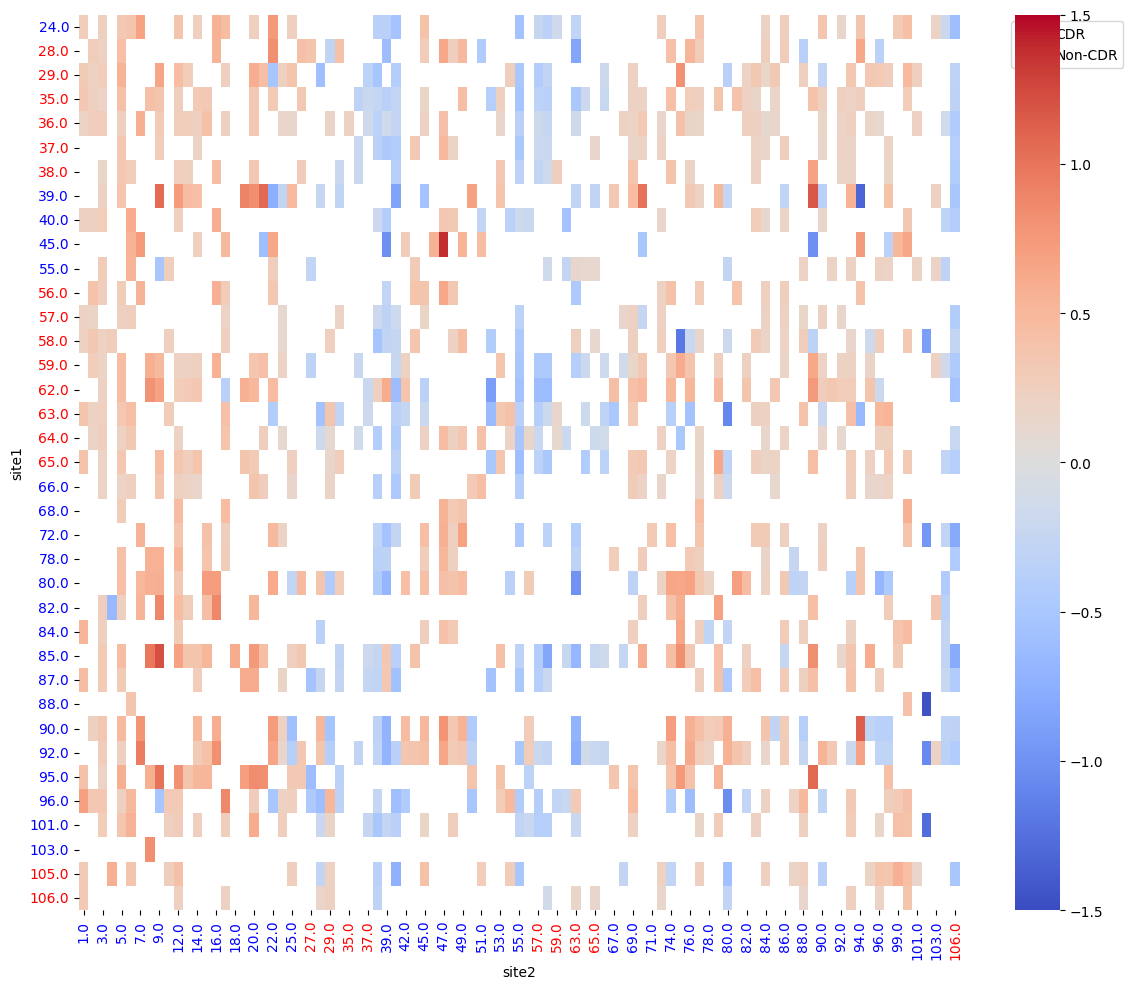

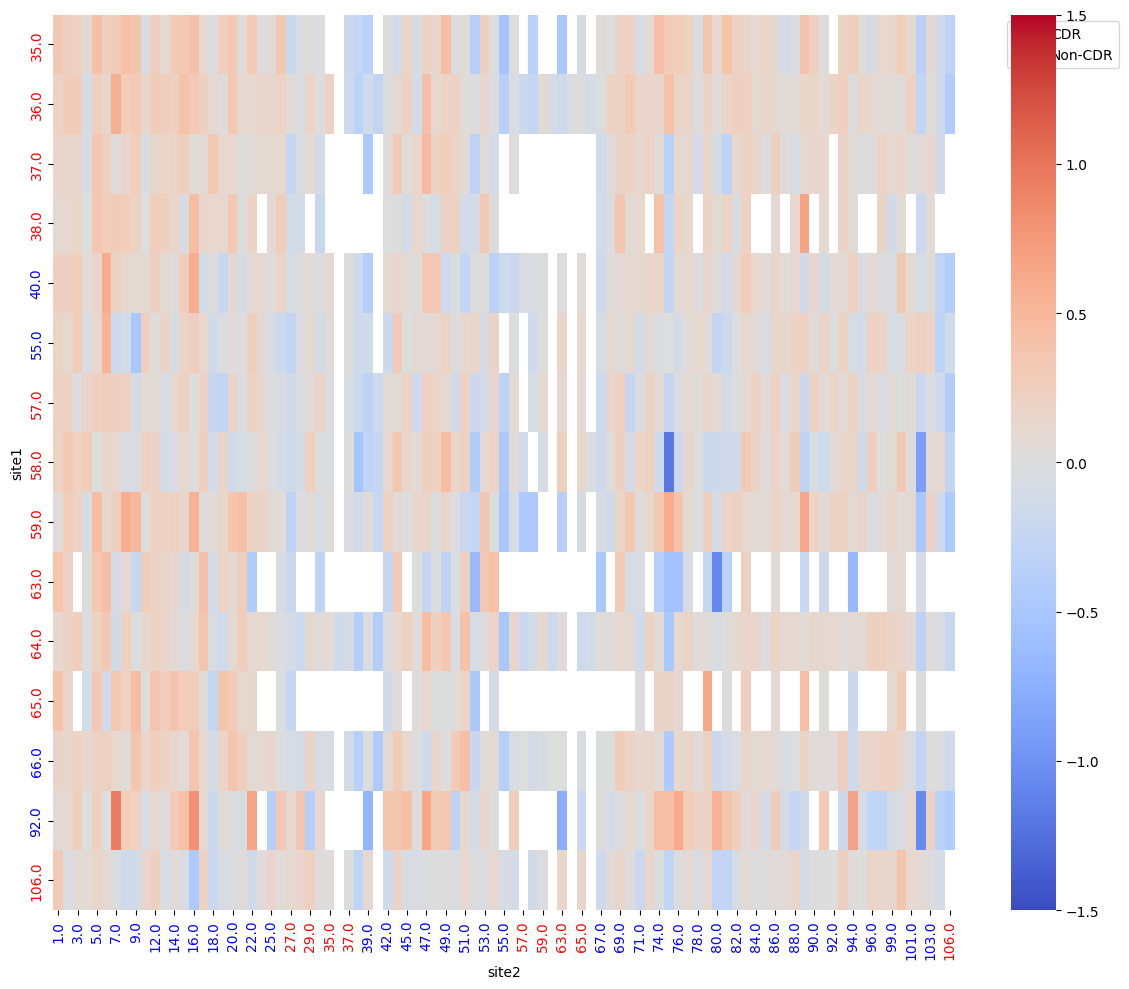

In [110]:
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(results_df[(results_df.poisson_pvalue < 0.05) & (results_df.has_site1_mutation_branch_length > 50)& (results_df['total_mutations_acquired'] > 100)].pivot_table(index='site1', columns='site2', values='log_rate_ratio'), vmin=-1.5, vmax=1.5, cmap="coolwarm", ax=ax)

# Get CDR information
cdr_info = site_sub_probs_df_germline[['site', 'is_cdr']].drop_duplicates().set_index('site')

# Color x-axis labels (site2)
for i, label in enumerate(ax.get_xticklabels()):
    site = float(label.get_text())
    if site in cdr_info.index:
        color = 'red' if cdr_info.loc[site, 'is_cdr'] else 'blue'
        label.set_color(color)

# Color y-axis labels (site1)
for i, label in enumerate(ax.get_yticklabels()):
    site = float(label.get_text())
    if site in cdr_info.index:
        color = 'red' if cdr_info.loc[site, 'is_cdr'] else 'blue'
        label.set_color(color)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='red', label='CDR'),
    Patch(facecolor='blue', label='Non-CDR')
]
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(results_df[(results_df.has_site1_mutation_branch_length > 100)& (results_df['total_mutations_acquired'] > 100)].pivot_table(index='site1', columns='site2', values='log_rate_ratio'), vmin=-1.5, vmax=1.5, cmap="coolwarm", ax=ax)


# Get CDR information
cdr_info = site_sub_probs_df_germline[['site', 'is_cdr']].drop_duplicates().set_index('site')

# Color x-axis labels (site2)
for i, label in enumerate(ax.get_xticklabels()):
    site = float(label.get_text())
    if site in cdr_info.index:
        color = 'red' if cdr_info.loc[site, 'is_cdr'] else 'blue'
        label.set_color(color)

# Color y-axis labels (site1)
for i, label in enumerate(ax.get_yticklabels()):
    site = float(label.get_text())
    if site in cdr_info.index:
        color = 'red' if cdr_info.loc[site, 'is_cdr'] else 'blue'
        label.set_color(color)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='red', label='CDR'),
    Patch(facecolor='blue', label='Non-CDR')
]
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()


In [ ]:
results_df[(results_df.site1 == 63) & (results_df.site2 == 23)].T


### are these effects not because of epistasis, bu tbecause of CDR FWR tendencies?
# For example, site 63 is in CDR3, and site 23 is in FWR3.
# This shows that a mutation at 23 is 3.6 times more likely to occur after a mutation at 63, how can i separate between epistasis and 
# the fact that CDR sites tend to mutate earlier in the lineage, and FWR later?



,8458
site1,63.0
site2,23.0
total_counts,21729
total_branch_length,703.696057
total_mutations_acquired,25
has_site1_mutation_count,4357
has_site1_mutation_branch_length,109.836323
has_site1_mutation_site2_acquired,10
has_site1_mutation_rate,0.091045
no_site1_mutation_count,17372


In [ ]:
results_df[(results_df.site1 == 39) & (results_df.site2 == 9)].T
# 9 is FR1, and 39 is the first site after CDR1.
# site 9 mutation is 2.9 times more likely to occur after a mutation at site 39 then when it's not mutated.
# this again could be because of CDR vs FWR tendencies, or because of epistasis.
# but it is interesting that other CDR sites don't have this effect on site 9.
# for example, mutations at sites 23, 41 and 43 occur more on the background of many other mutations in general, but for site 9 this is more specific.
# Let's try normalizing every column



,5013
site1,39.0
site2,9.0
total_counts,21115
total_branch_length,691.482891
total_mutations_acquired,390
has_site1_mutation_count,2356
has_site1_mutation_branch_length,62.564374
has_site1_mutation_site2_acquired,87
has_site1_mutation_rate,1.390568
no_site1_mutation_count,18759


In [113]:
results_df[(results_df.site1 == 58) & (results_df.site2 == 75)].T


### are these effects not because of epistasis, bu tbecause of CDR FWR tendencies?



,7791
site1,58.0
site2,75.0
total_counts,21507
total_branch_length,697.964814
total_mutations_acquired,106
has_site1_mutation_count,6273
has_site1_mutation_branch_length,162.649194
has_site1_mutation_site2_acquired,9
has_site1_mutation_rate,0.055334
no_site1_mutation_count,15234


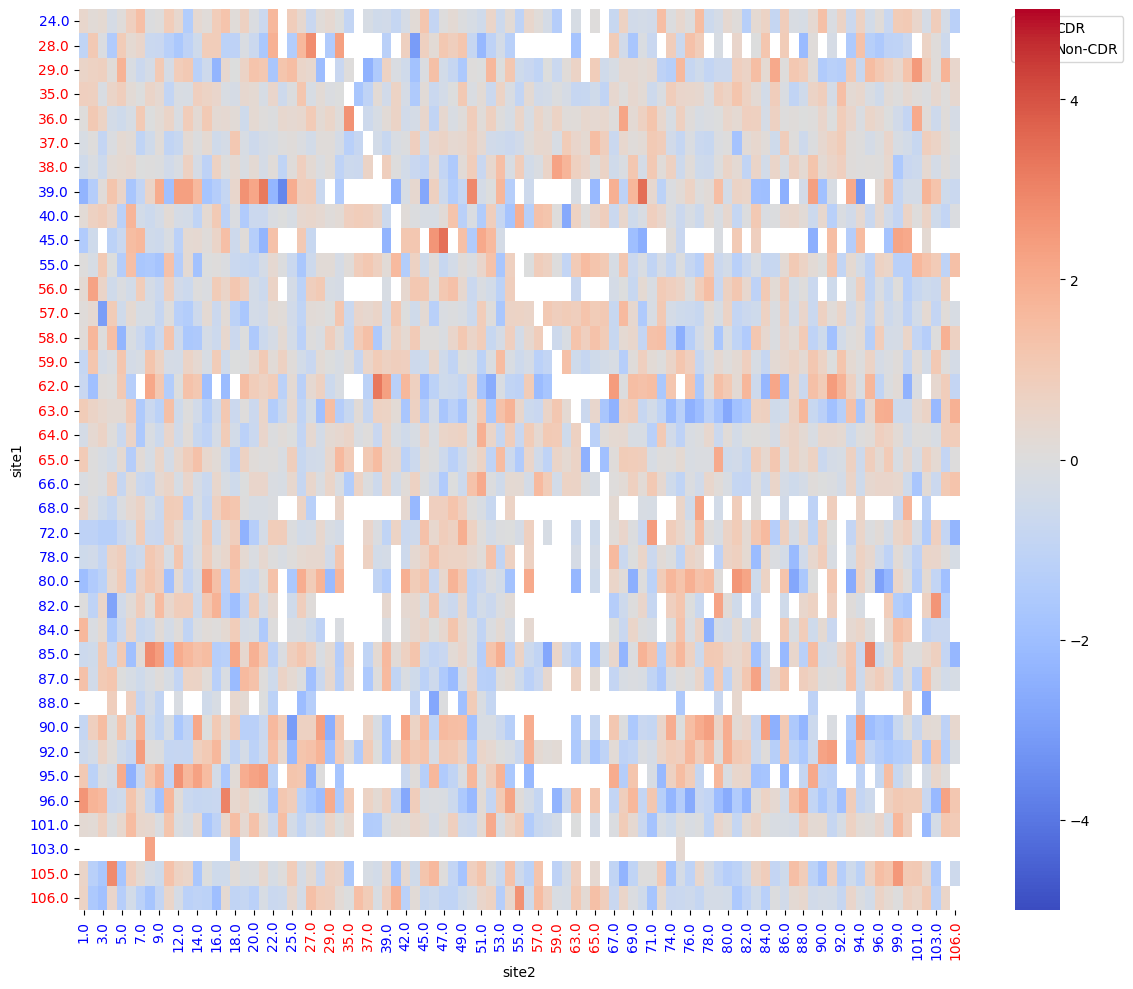

In [99]:
pythonfig, ax = plt.subplots(figsize=(12, 10))

# Create pivot table
pivot_data = results_df[(results_df.has_site1_mutation_branch_length > 50) & (results_df['total_mutations_acquired'] > 100)].pivot_table(
    index='site1', 
    columns='site2', 
    values='log_rate_ratio'
)

# Normalize columns
pivot_normalized = (pivot_data - pivot_data.mean(axis=0)) / pivot_data.std(axis=0)

# Create the heatmap
sns.heatmap(pivot_normalized, vmin=-5, vmax=5, cmap="coolwarm", ax=ax)

# Get CDR information
cdr_info = site_sub_probs_df_germline[['site', 'is_cdr']].drop_duplicates().set_index('site')

# Color x-axis labels (site2)
for i, label in enumerate(ax.get_xticklabels()):
    site = float(label.get_text())
    if site in cdr_info.index:
        color = 'red' if cdr_info.loc[site, 'is_cdr'] else 'blue'
        label.set_color(color)

# Color y-axis labels (site1)
for i, label in enumerate(ax.get_yticklabels()):
    site = float(label.get_text())
    if site in cdr_info.index:
        color = 'red' if cdr_info.loc[site, 'is_cdr'] else 'blue'
        label.set_color(color)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='red', label='CDR'),
    Patch(facecolor='blue', label='Non-CDR')
]
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

In [92]:
results_df[(results_df.site1 == 62) & (results_df.site2 == 38)].T
# 9 is FR1, and 39 is the first site after CDR1.
# site 9 mutation is 2.9 times more likely to occur after a mutation at site 39.
# this again could be because of CDR vs FWR tendencies, or because of epistasis.
# but it is interesting that other CDR sites don't have this effect on site 9.
# for example, mutations at sites 23, 41 and 43 occur more on the background of many other mutations in general, but for site 8 this is more specific.
# Let's try normalizing every column



,8328
site1,62.0
site2,38.0
total_counts,12006
total_branch_length,413.63319
total_mutations_acquired,653
has_site1_mutation_count,1767
has_site1_mutation_branch_length,50.097242
has_site1_mutation_site2_acquired,96
has_site1_mutation_rate,1.916273
no_site1_mutation_count,10239


In [71]:
def test_directionality(results_df, site_a, site_b):
    """
    Test if site_a → site_b is preferred over site_b → site_a
    """
    # Get results for both directions
    result_a_to_b = results_df[
        (results_df['site1'] == site_a) & (results_df['site2'] == site_b)
    ]
    result_b_to_a = results_df[
        (results_df['site1'] == site_b) & (results_df['site2'] == site_a)
    ]
    
    if len(result_a_to_b) == 0 or len(result_b_to_a) == 0:
        return None
    
    # Extract the key metrics
    rate_a_to_b = result_a_to_b['has_site1_mutation_rate'].iloc[0]
    rate_b_to_a = result_b_to_a['has_site1_mutation_rate'].iloc[0]
    
    # Compare the rates directly
    rate_ratio_directional = rate_a_to_b / rate_b_to_a if rate_b_to_a > 0 else np.inf
    
    # Statistical test comparing the two rates
    # Use the counts and exposures for both directions
    count_a_to_b = result_a_to_b['has_site1_mutation_site2_acquired'].iloc[0]
    exposure_a_to_b = result_a_to_b['has_site1_mutation_branch_length'].iloc[0]
    
    count_b_to_a = result_b_to_a['has_site1_mutation_site2_acquired'].iloc[0]
    exposure_b_to_a = result_b_to_a['has_site1_mutation_branch_length'].iloc[0]
    
    # Test if the two directional rates are significantly different
    try:
        if exposure_a_to_b > 0 and exposure_b_to_a > 0:
            directional_result = test_poisson_2indep(
                count1=count_a_to_b,
                exposure1=exposure_a_to_b,
                count2=count_b_to_a,
                exposure2=exposure_b_to_a
            )
            directional_pvalue = directional_result.pvalue
            directional_statistic = directional_result.statistic
        else:
            directional_pvalue = np.nan
            directional_statistic = np.nan
    except:
        directional_pvalue = np.nan
        directional_statistic = np.nan
    
    return {
        'site_a': site_a,
        'site_b': site_b,
        'rate_a_to_b': rate_a_to_b,
        'rate_b_to_a': rate_b_to_a,
        'rate_ratio_directional': rate_ratio_directional,
        'directional_statistic': directional_statistic,
        'directional_pvalue': directional_pvalue,
        'preferred_direction': 'A→B' if rate_a_to_b > rate_b_to_a else 'B→A',
        'is_directional': directional_pvalue < 0.05 if not np.isnan(directional_pvalue) else False
    }


# Test directionality for all unique pairs
import itertools

directional_results = []
unique_sites = sorted(results_df['site1'].unique())

for site_a, site_b in itertools.combinations(unique_sites, 2):
    result = test_directionality(results_df, site_a, site_b)
    if result:
        directional_results.append(result)

directional_df = pd.DataFrame(directional_results)

# Filter for significant directional preferences
significant_directional = directional_df[
    (directional_df['is_directional'] == True) & 
    (directional_df['rate_ratio_directional'] > 2)  # Strong preference
]

print(f"Found {len(significant_directional)} significant directional preferences")

/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/statsmodels/stats/rates.py:870: RuntimeWarning: divide by zero encountered in scalar divide
  ratio = rate1 / rate2
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/statsmodels/stats/rates.py:776: RuntimeWarning: invalid value encountered in scalar divide
  stat = (y1 - y2 * r_d) / np.sqrt((y1 + y2) * r_d)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/statsmodels/stats/rates.py:870: RuntimeWarning: invalid value encountered in scalar divide
  ratio = rate1 / rate2


Found 1467 significant directional preferences


<Axes: >

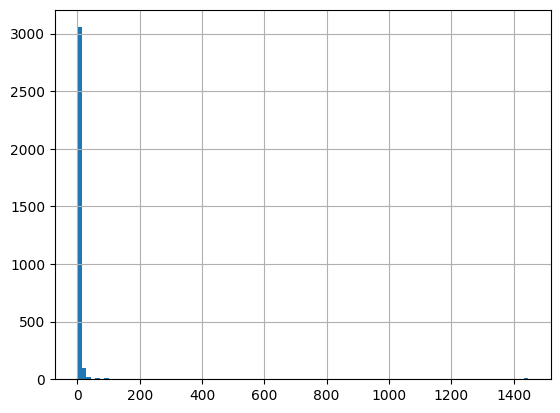

In [ ]:
directional_df_plot = directional_df[directional_df.directional_pvalue < 0.05].copy()
max_finite = directional_df_plot['rate_ratio_directional'].replace([np.inf, -np.inf], np.nan).max()
directional_df_plot['rate_ratio_directional'] = directional_df_plot['rate_ratio_directional'].replace([np.inf, -np.inf], max_finite)
directional_df_plot.sort_values(by='rate_ratio_directional', ascending=False)['rate_ratio_directional'].hist(bins=100)

<Axes: >

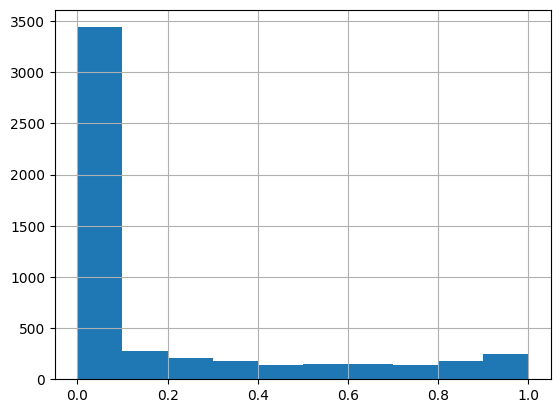

In [82]:
directional_df.directional_pvalue.hist()

/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


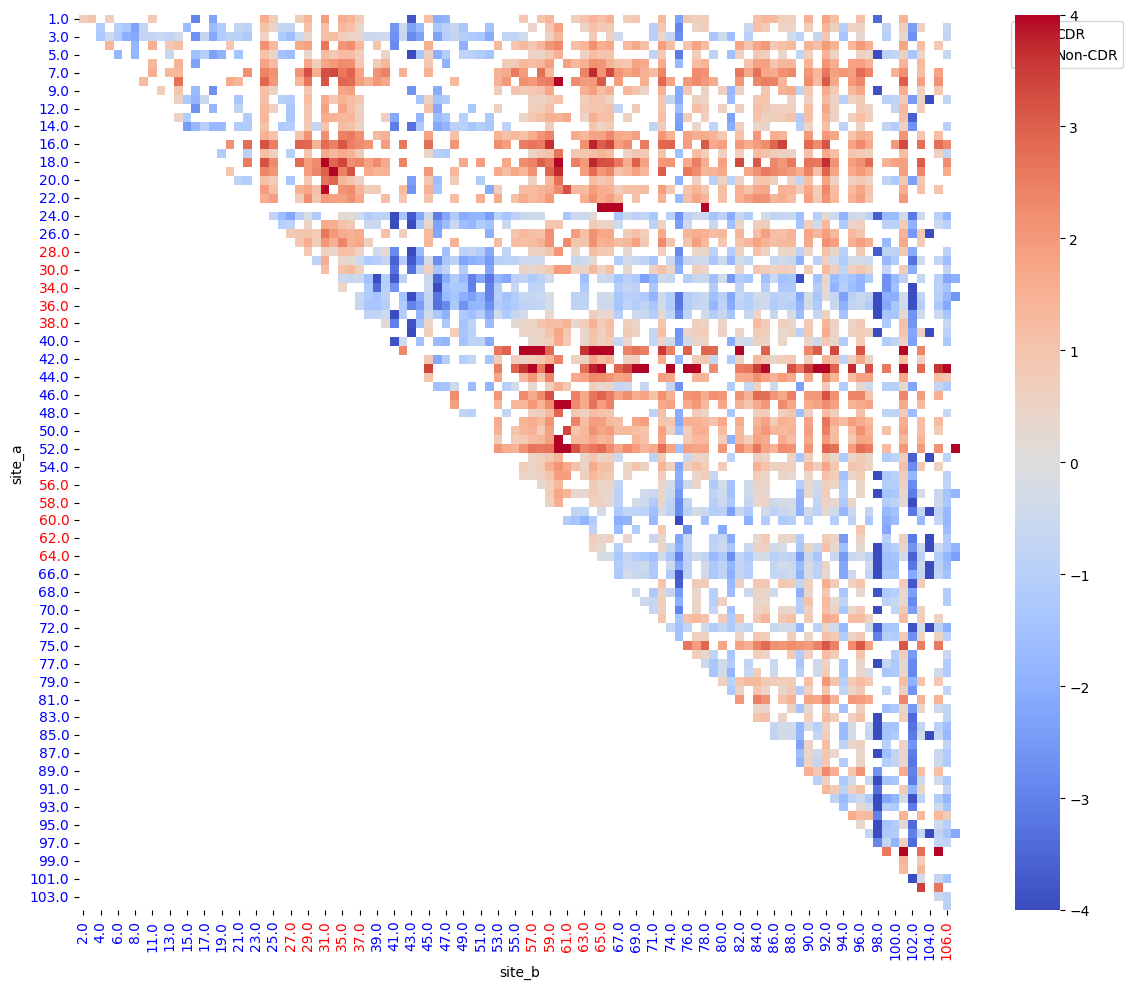

In [88]:

fig, ax = plt.subplots(figsize=(12, 10))
directional_df['log_rate_ratio_directional'] = np.log(directional_df['rate_ratio_directional'])
sns.heatmap(directional_df[directional_df.directional_pvalue < 0.05].pivot_table(index='site_a', columns='site_b', values='log_rate_ratio_directional'), vmin=-4, vmax=4, cmap="coolwarm", ax=ax)

# Get CDR information
cdr_info = site_sub_probs_df_germline[['site', 'is_cdr']].drop_duplicates().set_index('site')

# Color x-axis labels (site2)
for i, label in enumerate(ax.get_xticklabels()):
    site = float(label.get_text())
    if site in cdr_info.index:
        color = 'red' if cdr_info.loc[site, 'is_cdr'] else 'blue'
        label.set_color(color)

# Color y-axis labels (site1)
for i, label in enumerate(ax.get_yticklabels()):
    site = float(label.get_text())
    if site in cdr_info.index:
        color = 'red' if cdr_info.loc[site, 'is_cdr'] else 'blue'
        label.set_color(color)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='red', label='CDR'),
    Patch(facecolor='blue', label='Non-CDR')
]
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()
